# Measuring emission line fluxes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# read the data
import pandas as pd
galname = 'J1146'
j1146 = pd.read_csv(galname + '.csv')

wave = j1146['wave'].to_numpy()
flux = j1146['flux'].to_numpy() * 1e17
err = j1146['noise'].to_numpy() * 1e17
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# Main lines
        
# [NII]6548 + Ha + [NII]6584
select = (wave > 6910) * (wave < 6970)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5275) * (wave < 5310)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 7715) * (wave < 7770)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# HeI7065
select = (wave > 7430) * (wave < 7510)
hei_7065 = SpecPiece('hei7065', wave[select], flux[select], err[select])

# HeI6678
select = (wave > 7025) * (wave < 7090)
hei_6678 = SpecPiece('hei6678', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 7080) * (wave < 7130)
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# HeI5875
select = (wave > 6170) * (wave < 6250)
hei_5875 = SpecPiece('hei5875', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 6100) * (wave < 6150)
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5120) * (wave < 5155)
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# HeI4471
select = (wave > 4710) * (wave < 4740)
hei_4471 = SpecPiece('hei4471', wave[select], flux[select], err[select])

# Hg
select = (wave > 4570) * (wave < 4605)
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4320) * (wave < 4350)
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4275) * (wave < 4330)
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 3925) * (wave < 3955)
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])


# High ionization lines

# [SIII]9532
select = (wave > 10020) * (wave < 10130)
siii_9532 = SpecPiece('siiia', wave[select], flux[select], err[select])

# [SIII]9069
select = (wave > 9500) * (wave < 9670)
siii_9069 = SpecPiece('siiib', wave[select], flux[select], err[select])

# [Ar III]7135
select = (wave > 7500) * (wave < 7580)
ariii_7135 = SpecPiece('ariii_7135', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 6635) * (wave < 6700)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5220) * (wave < 5260)
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# [Ar IV]4740
select = (wave > 4990) * (wave < 5030)
ariv_4740 = SpecPiece('ariv_4740', wave[select], flux[select], err[select])

# HeII4686
select = (wave > 4930) * (wave < 4975)
heii_4686 = SpecPiece('heii4686', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 4600) * (wave < 4623)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 4070) * (wave < 4105)
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

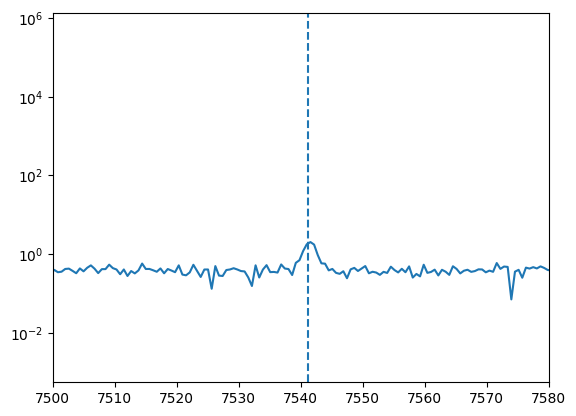

In [3]:
plt.plot(wave, flux)
plt.xlim(7500, 7580)
plt.axvline((1 + z_BN[igal])*wave_cat['[ArIII]7135'], ls='--')
plt.yscale('log')

---

# Two component model fit for [OIII] 4959

# [OIII]4959

In [4]:
m = arc_slope19a
n = arc_intercept19a

sigma_arc_4959 = (m * wave_cat['[OIII]4959']*(1 + z_BN[igal])) + n

In [5]:
m_wer = ufloat(9.1375e-05, 6.6525e-06)
n_wer = ufloat(0.04053405, 0.04407090)

sigma_arc_4959_wer = (m_wer * wave_cat['[OIII]4959']*(1 + z_BN[igal])) + n_wer

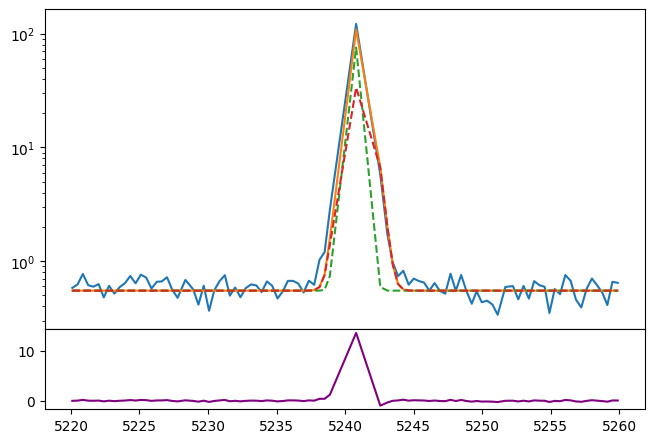

In [6]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 5.5e-1

oiiib_nar = gaussian(oiii_4959.wavelength, 100, wave_cat['[OIII]4959'], z=z_BN[igal]+0.00001, sigma=0.5)
oiiib_brd = gaussian(oiii_4959.wavelength, 70, wave_cat['[OIII]4959'], z=z_BN[igal]+0.0001, sigma=0.8)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [7]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=z_BN[igal]+0.00001)
params_oiii_4959.add('z_brd', value=z_BN[igal]+0.0001)
params_oiii_4959.add('sigma_nar', value=0.5, min=0.)
params_oiii_4959.add('sigma_brd', value=0.8, min=0.)
params_oiii_4959.add('Oiiib_nar', value=100, min=0.)
params_oiii_4959.add('Oiiib_brd', value=70, min=0.)
params_oiii_4959.add('bkg', value=5.5e-1, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [8]:
np.random.seed(1146)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:16<00:00, 148.97it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [216.10851759 156.55605495 256.88966032 263.1410719  268.48700847
 266.20960568 129.08191403]


In [9]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05685258,2.6536e-05,(0.05%),0.056810000000000006,-inf,inf,True
z_brd,0.05686323,1.2785e-05,(0.02%),0.056900000000000006,-inf,inf,True
sigma_nar,0.57749036,0.14202712,(24.59%),0.5,0.00000000,inf,True
sigma_brd,0.95836740,0.25959041,(27.09%),0.8,0.00000000,inf,True
Oiiib_nar,157.205755,52.4730939,(33.38%),100,0.00000000,inf,True
Oiiib_brd,36.6362156,32.1407320,(87.73%),70,0.00000000,inf,True
bkg,0.58513712,0.01062914,(1.82%),0.55,0.00000000,inf,True


In [10]:
np.random.seed(1146)
out2_oiii_4959 = minimize(residual_oiii_4959, out_oiii_4959.params, args=(1, 1, 1),
                      method='leastsq')

In [11]:
out2_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05685630,5.1773e-06,(0.01%),0.05685257676894179,-inf,inf,True
z_brd,0.05688099,2.8671e-05,(0.05%),0.05686322546520698,-inf,inf,True
sigma_nar,0.67171998,0.01456392,(2.17%),0.5774903611177682,0.00000000,inf,True
sigma_brd,1.50764122,0.27730495,(18.39%),0.9583674021041142,0.00000000,inf,True
Oiiib_nar,202.308077,6.23088776,(3.08%),157.20575539682267,0.00000000,inf,True
Oiiib_brd,5.79999567,2.80098941,(48.29%),36.63621561200772,0.00000000,inf,True
bkg,0.58014163,0.01149665,(1.98%),0.5851371239732825,0.00000000,inf,True


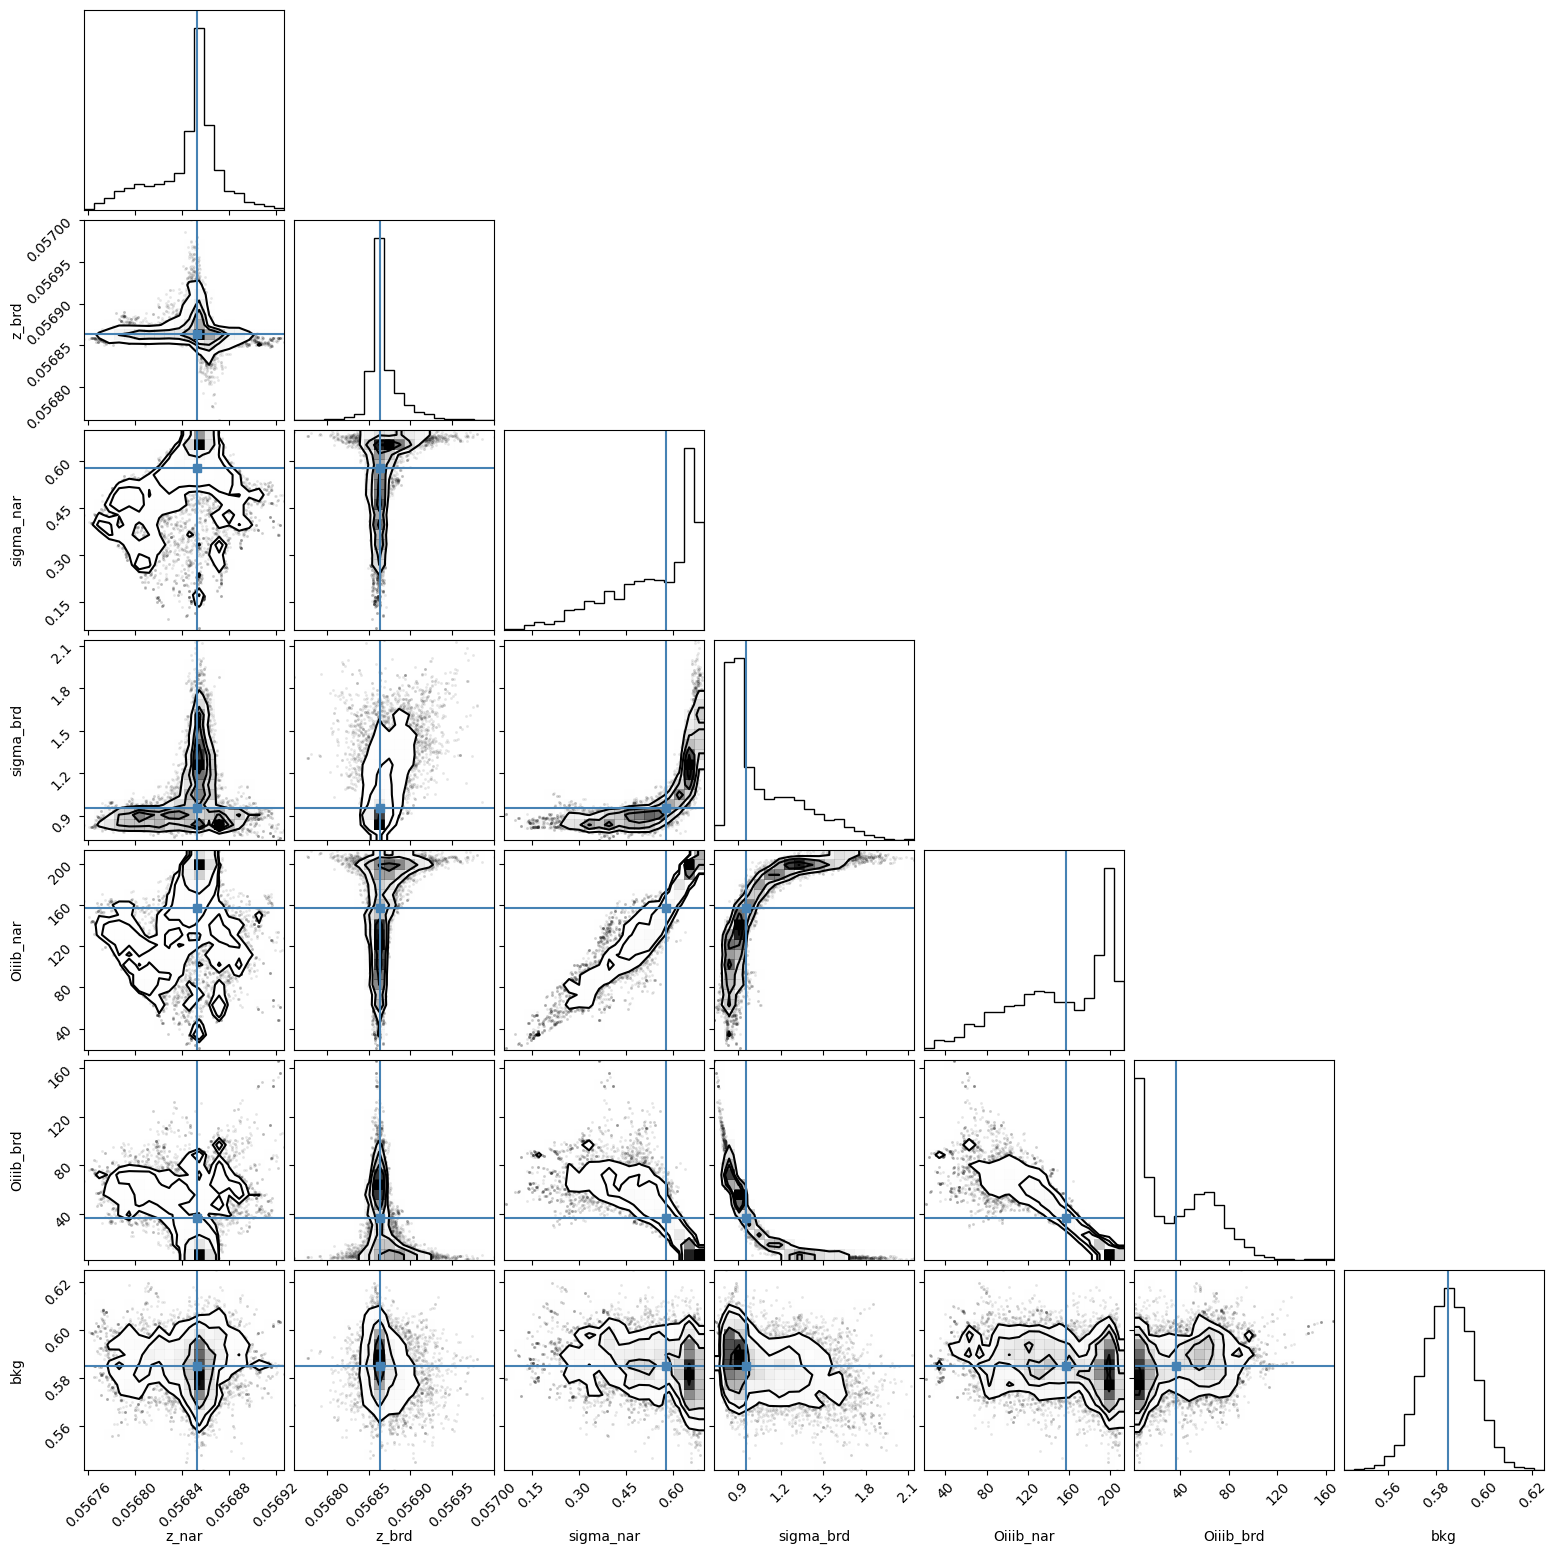

In [12]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

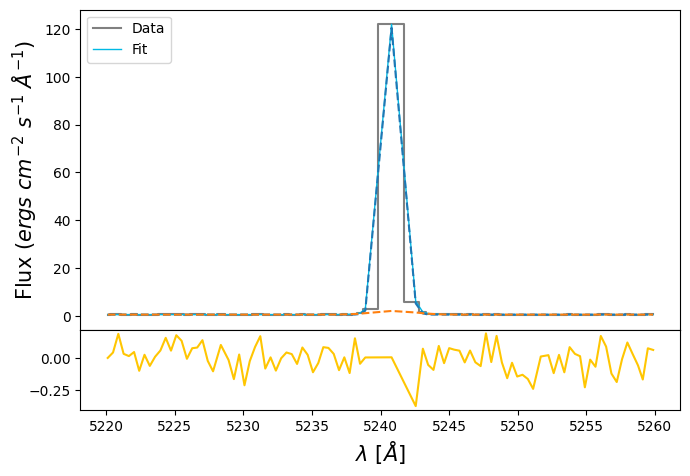

In [13]:
oiiib_nar_flux = out2_oiii_4959.params['Oiiib_nar'].value
oiiib_nar_std = out2_oiii_4959.params['Oiiib_nar'].stderr

oiiib_brd_flux = out2_oiii_4959.params['Oiiib_brd'].value
oiiib_brd_std = out2_oiii_4959.params['Oiiib_brd'].stderr

bkg_oiii_4959 = out2_oiii_4959.params['bkg'].value
bkg_oiii_4959_std = out2_oiii_4959.params['bkg'].stderr

z_nar_oiii_4959 = out2_oiii_4959.params['z_nar'].value
z_nar_oiii_4959_std = out2_oiii_4959.params['z_nar'].stderr

z_brd_oiii_4959 = out2_oiii_4959.params['z_brd'].value
z_brd_oiii_4959_std = out2_oiii_4959.params['z_brd'].stderr

sigma_nar_oiii_4959 = out2_oiii_4959.params['sigma_nar'].value
sigma_nar_oiii_4959_std = out2_oiii_4959.params['sigma_nar'].stderr

sigma_brd_oiii_4959 = out2_oiii_4959.params['sigma_brd'].value
sigma_brd_oiii_4959_std = out2_oiii_4959.params['sigma_brd'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.legend(loc='upper left')

In [14]:
# Correcting sigma by instrumental broadening

# Intrinsic from the galaxy
sigma_nar_intrinsic = ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std)
sigma_brd_intrinsic = upy.sqrt((ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std)**2) - (sigma_arc_4959**2)) 

In [15]:
# EW
EW_OIII_4959_nar = ufloat(oiiib_nar_flux, oiiib_nar_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959_brd = ufloat(oiiib_brd_flux, oiiib_brd_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959 = (ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)

# FWHM
FWHM_4959_nar = FWHM(sigma_nar_intrinsic, wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(sigma_brd_intrinsic, wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

In [16]:
print('Redshift of the narrow component: {:.4f}'.format(ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))

Redshift of the narrow component: 0.0569+/-0.0000


In [17]:
# Velocities
vel = {'galname': galname,
       'z_nar': z_nar_oiii_4959,
       'dV': dV_4959.nominal_value,
       'dV_err': dV_4959.std_dev,
       'FWHM_nar': FWHM_4959_nar.nominal_value,
       'FWHM_nar_err': FWHM_4959_nar.std_dev,
       'FWHM_brd': FWHM_4959_brd.nominal_value,
       'FWHM_brd_err': FWHM_4959_brd.std_dev
}
vel_catalog_pd = pd.DataFrame(data=vel, index=[0])
vel_catalog_pd

,galname,z_nar,dV,dV_err,FWHM_nar,FWHM_nar_err,FWHM_brd,FWHM_brd_err
0,J1146,0.056856,7.005506,8.264397,90.450959,1.961116,190.580498,39.774679


In [18]:
save_catalog(galname, vel_catalog_pd, magePath + '/results/vel_catalog_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1146, overwriting...
Done.


---

# [NII]6548 + H$\alpha$ + [NII]6584

In [19]:
sigma_arc_ha = (m * wave_cat['Ha']*(1 + z_BN[igal])) + n

sigma_nar_ha = sigma_arc_ha
sigma_brd_ha = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_ha**2))

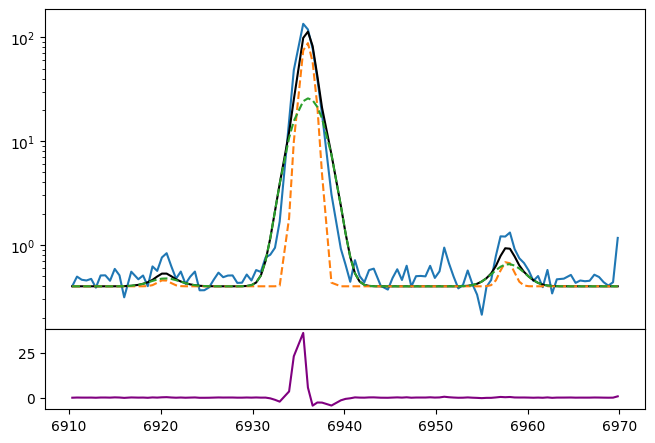

In [20]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 4e-1

ha_nar = gaussian(ha_nii.wavelength, 1.5e2, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, 1e2, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, 0.1, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, 0.3, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, 0.5, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, 1.0, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, bkg + niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, bkg + niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')
ax.set_yscale('log')

In [21]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ha_nii.add('z_ratio', value=z_ratio, vary=False)
params_ha_nii.add('sigma_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('Ha_nar', value=1.5e2, min=0.)
params_ha_nii.add('Ha_brd', value=1.0e2, min=0.)
params_ha_nii.add('Niia_nar', value=0., vary=False)
params_ha_nii.add('Niia_brd', value=1.0, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)
params_ha_nii.add('bkg', value=4.0e-1, vary=True)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_nar'] * params_ha_nii['z_ratio']
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_brd = params_ha_nii['sigma_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [22]:
np.random.seed(1146)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:32<00:00, 77.73it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 34.9492797  102.86721608 111.79863522 179.2134922  111.22044936
  41.01045246]


In [23]:
out_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05682476,4.5415e-07,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.67427052,,,0.674270522629,-inf,inf,False
sigma_brd,1.56775475,,,1.5677547510197214,-inf,inf,False
Ha_nar,209.919907,1.07354992,(0.51%),150.0,0.00000000,inf,True
Ha_brd,77.3747003,0.82210757,(1.06%),100.0,0.00000000,inf,True
Niia_nar,0.00000000,,,0.0,-inf,inf,False
Niia_brd,2.35368202,0.14115822,(6.00%),1.0,0.00000000,inf,True
Niib_to_niia,0.42948056,0.05560398,(12.95%),0.3333333333333333,0.00000000,1.00000000,True
bkg,0.41123132,0.00802958,(1.95%),0.4,-inf,inf,True


In [24]:
np.random.seed(1146)
out2_ha_nii = minimize(residual_ha_nii, out_ha_nii.params, args=(1, 1, 1),
                      method='leastsq')

In [25]:
out2_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05682482,2.4065e-06,(0.00%),0.05682476386110015,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.67427052,0.00000000,(0.00%),0.674270522629,-inf,inf,False
sigma_brd,1.56775475,0.00000000,(0.00%),1.5677547510197214,-inf,inf,False
Ha_nar,209.890023,5.99070657,(2.85%),209.91990664654935,0.00000000,inf,True
Ha_brd,77.3849332,4.70754617,(6.08%),77.37470025127578,0.00000000,inf,True
Niia_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Niia_brd,2.36511867,0.78579007,(33.22%),2.3536820172722814,0.00000000,inf,True
Niib_to_niia,0.42605302,0.31470898,(73.87%),0.42948056096009946,0.00000000,1.00000000,True
bkg,0.41087197,0.04635800,(11.28%),0.4112313230916699,-inf,inf,True


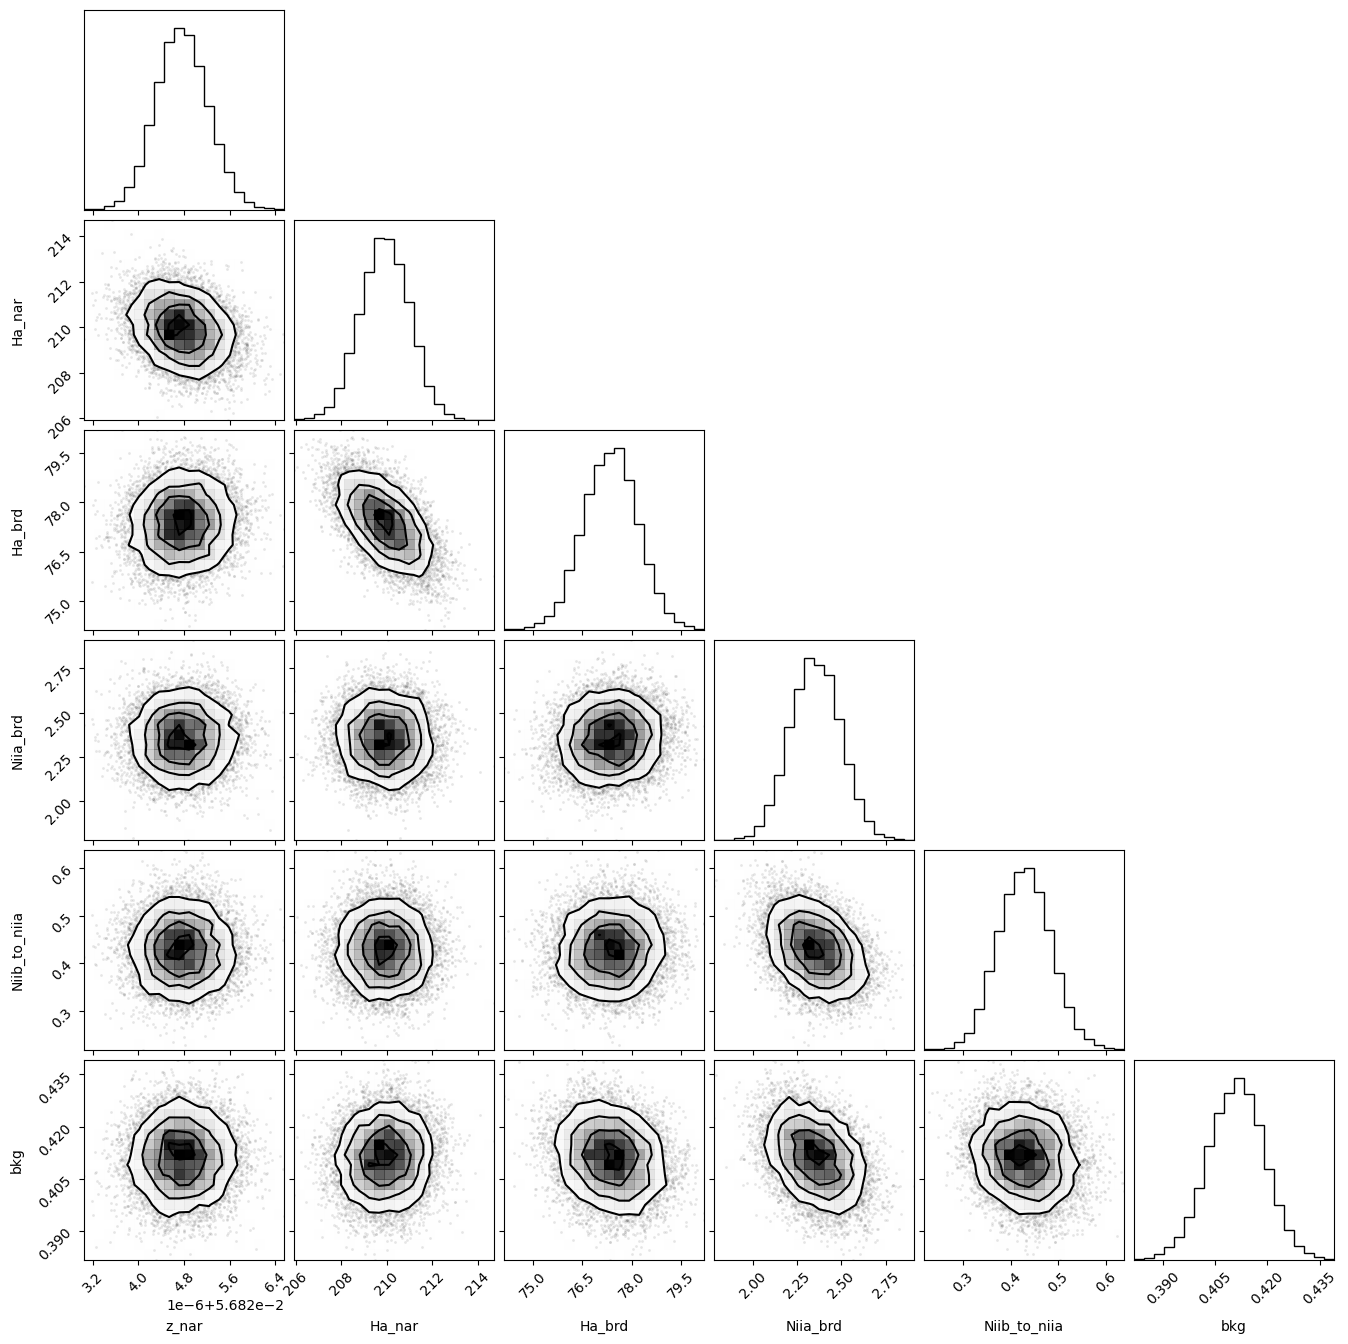

In [26]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

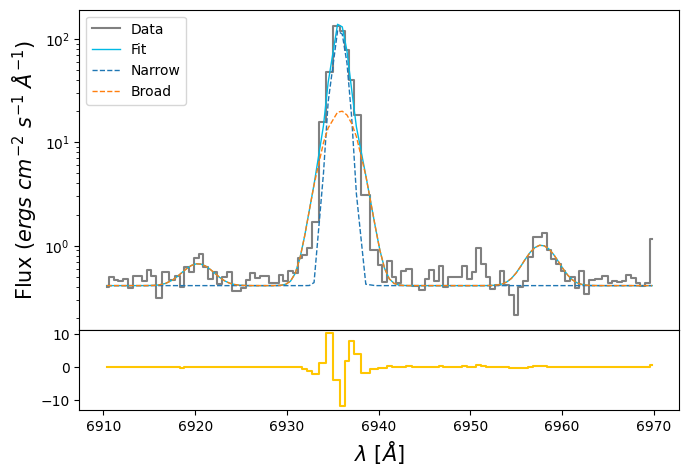

In [27]:
ha_nar_flux = out2_ha_nii.params['Ha_nar'].value
ha_nar_std = out2_ha_nii.params['Ha_nar'].stderr

ha_brd_flux = out2_ha_nii.params['Ha_brd'].value
ha_brd_std = out2_ha_nii.params['Ha_brd'].stderr

niia_nar_flux = out2_ha_nii.params['Niia_nar'].value
niia_nar_std = out2_ha_nii.params['Niia_nar'].stderr

niia_brd_flux = out2_ha_nii.params['Niia_brd'].value
niia_brd_std = out2_ha_nii.params['Niia_brd'].stderr

niib_nar_flux = niia_nar_flux * out_ha_nii.params['Niib_to_niia'].value
niib_nar_std = niia_nar_flux * out_ha_nii.params['Niib_to_niia'].stderr

niib_brd_flux = niia_brd_flux * out_ha_nii.params['Niib_to_niia'].value
niib_brd_std = niia_brd_flux * out_ha_nii.params['Niib_to_niia'].stderr

z_ha_nii = out_ha_nii.params['z_nar'].value
z_ha_nii_std = out_ha_nii.params['z_nar'].stderr

bkg_ha_nii = out_ha_nii.params['bkg'].value
bkg_ha_nii_std = out_ha_nii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [28]:
# EW
EW_Ha_nar = ufloat(ha_nar_flux, ha_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha_brd = ufloat(ha_brd_flux, ha_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha = (ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6584_nar = ufloat(niia_nar_flux, niia_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584_brd = ufloat(niia_brd_flux, niia_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584 = (ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6548_nar = ufloat(niib_nar_flux, niib_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548_brd = ufloat(niib_brd_flux, niib_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548 = (ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

# [OII]7319 + [OII]7330

In [29]:
sigma_arc_7330 = (m * wave_cat['[OII]7330']*(1 + z_BN[igal])) + n

sigma_nar_7330 = sigma_arc_7330
sigma_brd_7330 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7330**2))

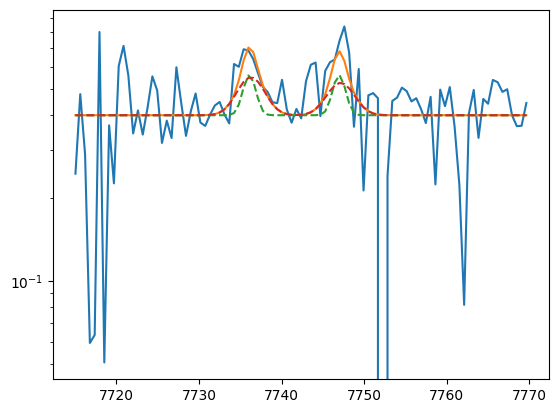

In [30]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 3e-1, wave_cat['[OII]7330'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiia_brd = gaussian(oii_7320.wavelength, 5e-1, wave_cat['[OII]7330'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiib_nar = gaussian(oii_7320.wavelength, 3e-1, wave_cat['[OII]7319'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiib_brd = gaussian(oii_7320.wavelength, 6e-1, wave_cat['[OII]7319'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd
bkg = 4e-1

plt.plot(oii_7320.wavelength, bkg + oiib + oiia)
plt.plot(oii_7320.wavelength, bkg + oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, bkg + oiib_brd + oiia_brd, ls='--')

plt.yscale('log')

In [31]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio, vary=False)
params_oii_7320.add('sigma_nar', value=upy.nominal_values(sigma_nar_7330), vary=False)
params_oii_7320.add('sigma_brd', value=upy.nominal_values(sigma_brd_7330), vary=False)
params_oii_7320.add('Oiia_nar', value=0., vary=False)
params_oii_7320.add('Oiia_brd', value=5.0e-1, min=0.)
params_oii_7320.add('Oiib_nar', value=0., vary=False)
params_oii_7320.add('Oiib_brd', value=6.0e-1, min=0.)
params_oii_7320.add('bkg', value=4e-1, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_nar = params_oii_7320['sigma_nar']
    sigma_brd = params_oii_7320['sigma_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    bkg = params_oii_7320['bkg']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_brd)
    model = model_oiia + model_oiib
    return (model + bkg - oii_7320.flux) / oii_7320.noise

In [32]:
np.random.seed(1146)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:24<00:00, 101.52it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [37.46942856 56.18165133 40.97818551 39.8175234 ]


In [33]:
out_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681218,2.7822e-05,(0.05%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.74837458,,,0.7483745803689998,-inf,inf,False
sigma_brd,1.60102428,,,1.601024276580777,-inf,inf,False
Oiia_nar,0.00000000,,,0.0,-inf,inf,False
Oiia_brd,1.10118955,0.15072158,(13.69%),0.5,0.00000000,inf,True
Oiib_nar,0.00000000,,,0.0,-inf,inf,False
Oiib_brd,0.90084750,0.16722157,(18.56%),0.6,0.00000000,inf,True
bkg,0.42390294,0.00997422,(2.35%),0.4,0.00000000,inf,True


In [34]:
np.random.seed(1146)
out2_oii_7320 = minimize(residual_oii_7320, out_oii_7320.params, args=(1, 1, 1),
                         method='leastsq')

In [35]:
out2_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681252,3.5095e-05,(0.06%),0.056812177370744225,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.74837458,0.00000000,(0.00%),0.7483745803689998,-inf,inf,False
sigma_brd,1.60102428,0.00000000,(0.00%),1.601024276580777,-inf,inf,False
Oiia_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Oiia_brd,1.10770649,0.17812066,(16.08%),1.1011895464281811,0.00000000,inf,True
Oiib_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Oiib_brd,0.91491718,0.19401842,(21.21%),0.9008475021195099,0.00000000,inf,True
bkg,0.42326561,0.01181645,(2.79%),0.423902941495224,0.00000000,inf,True


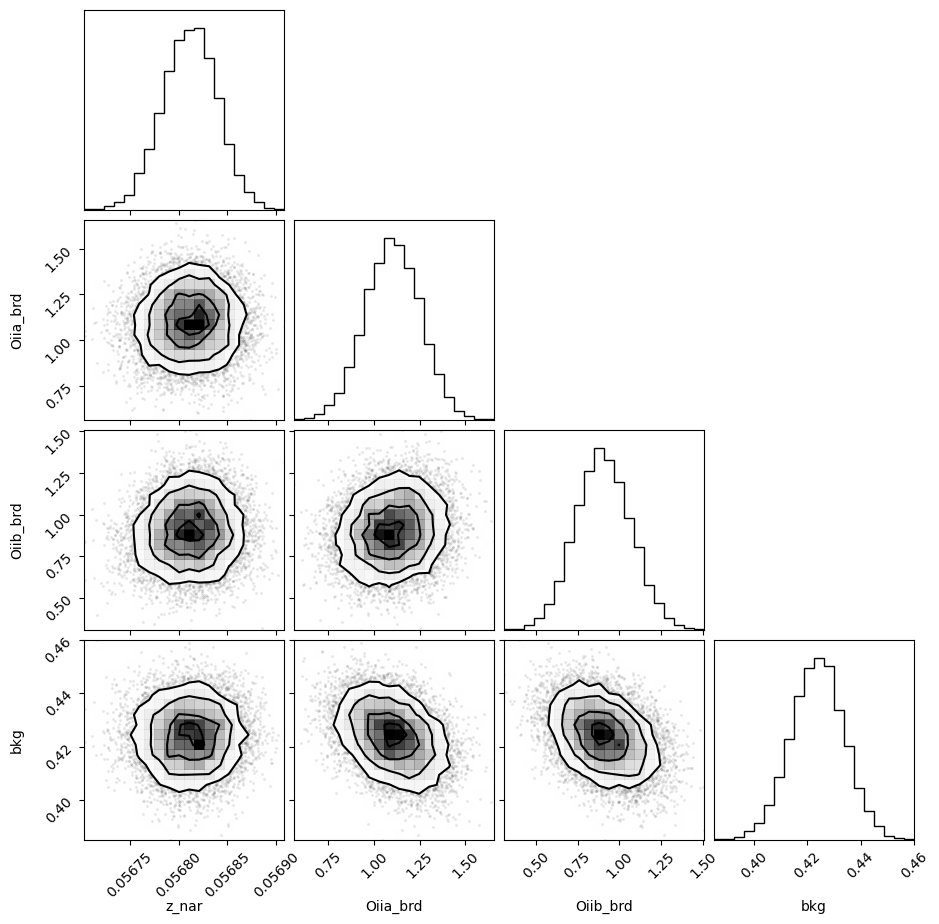

In [36]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);

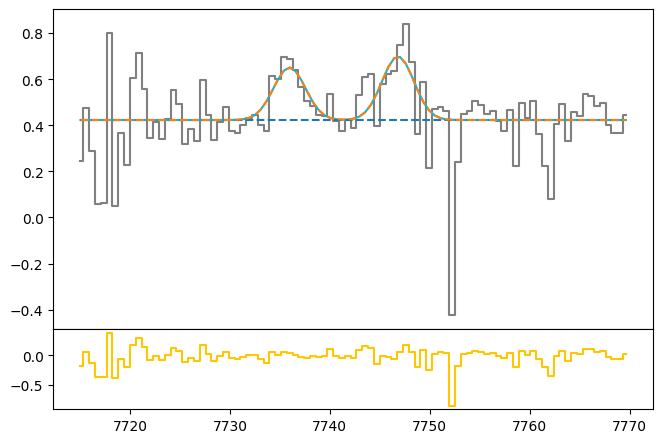

In [37]:
oiia_nar_flux = out2_oii_7320.params['Oiia_nar'].value
oiia_nar_std = out2_oii_7320.params['Oiia_nar'].stderr

oiia_brd_flux = out2_oii_7320.params['Oiia_brd'].value
oiia_brd_std = out2_oii_7320.params['Oiia_brd'].stderr

oiib_nar_flux = out2_oii_7320.params['Oiib_nar'].value
oiib_nar_std = out2_oii_7320.params['Oiib_nar'].stderr

oiib_brd_flux = out2_oii_7320.params['Oiib_brd'].value
oiib_brd_std = out2_oii_7320.params['Oiib_brd'].stderr

z_oii_7320 = out2_oii_7320.params['z_nar'].value
z_oii_7320_std = out2_oii_7320.params['z_nar'].stderr

bkg_oii_7320 = out2_oii_7320.params['bkg'].value
bkg_oii_7320_std = out2_oii_7320.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, upy.nominal_values(sigma_nar_7330))
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, upy.nominal_values(sigma_nar_7330))

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - bkg_oii_7320 - oiia - oiib, color=c[3], where='mid')

In [38]:
# EW
EW_OII_7330_nar = ufloat(oiia_nar_flux, oiia_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330_brd = ufloat(oiia_brd_flux, oiia_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330 = (ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

EW_OII_7319_nar = ufloat(oiib_nar_flux, oiib_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319_brd = ufloat(oiib_brd_flux, oiib_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319 = (ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

# HeI 7065

In [39]:
sigma_arc_7065 = (m * wave_cat['HeI7065']*(1 + z_BN[igal])) + n

sigma_nar_7065 = sigma_arc_7065
sigma_brd_7065 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7065**2))

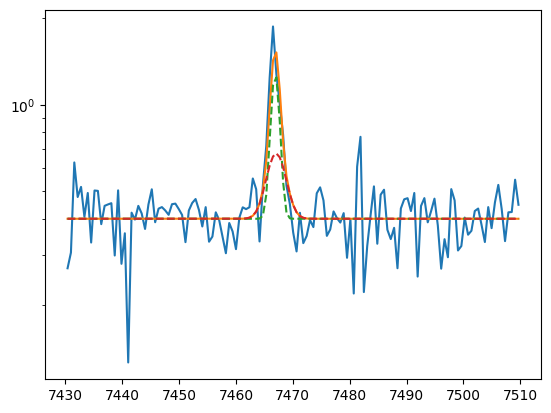

In [40]:
plt.plot(hei_7065.wavelength, hei_7065.flux)
bkg = 4e-1

hei7065_nar = gaussian(hei_7065.wavelength, 1.6, wave_cat['HeI7065'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7065))
hei7065_brd = gaussian(hei_7065.wavelength, 1.1, wave_cat['HeI7065'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7065))

hei7065 = hei7065_nar + hei7065_brd

plt.plot(hei_7065.wavelength, hei7065 + bkg)
plt.plot(hei_7065.wavelength, hei7065_nar + bkg, ls='--')
plt.plot(hei_7065.wavelength, hei7065_brd + bkg, ls='--')
plt.yscale('log')

In [41]:
params_7065 = Parameters()
params_7065.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_7065.add('z_ratio', value=z_ratio, vary=False)
params_7065.add('sigma_hei7065_nar', value=upy.nominal_values(sigma_nar_7065), vary=False)
params_7065.add('sigma_hei7065_brd', value=upy.nominal_values(sigma_brd_7065), vary=False)
params_7065.add('Hei7065_nar', value=1.6, min=0.)
params_7065.add('Hei7065_brd', value=1.1, min=0.)
params_7065.add('bkg', value=4e-1, min=0.)

def residual_hei7065(params_7065, x, data, uncertainty):
    
    z_nar = params_7065['z_nar']
    z_brd = params_7065['z_nar'] * params_7065['z_ratio']
    sigma_hei7065_nar = params_7065['sigma_hei7065_nar']
    sigma_hei7065_brd = params_7065['sigma_hei7065_brd']
    hei7065_nar_flux = params_7065['Hei7065_nar']
    hei7065_brd_flux = params_7065['Hei7065_brd']
    bkg = params_7065['bkg']
    
    x = hei_7065.wavelength
    model = gaussian(x, hei7065_nar_flux, wave_cat['HeI7065'], z_nar, sigma_hei7065_nar) + \
            gaussian(x, hei7065_brd_flux, wave_cat['HeI7065'], z_brd, sigma_hei7065_brd)
    return (model + bkg - hei_7065.flux) / hei_7065.noise

In [42]:
np.random.seed(1146)
out_hei7065 = minimize(residual_hei7065, params_7065, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 128.16it/s]


In [43]:
out_hei7065.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681543,7.2276e-06,(0.01%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_hei7065_nar,0.72278483,,,0.7227848288689999,-inf,inf,False
sigma_hei7065_brd,1.58922375,,,1.5892237509242408,-inf,inf,False
Hei7065_nar,1.97349559,0.21472313,(10.88%),1.6,0.00000000,inf,True
Hei7065_brd,0.83299528,0.31663077,(38.01%),1.1,0.00000000,inf,True
bkg,0.40419454,0.00605483,(1.50%),0.4,0.00000000,inf,True


In [44]:
np.random.seed(1146)
out2_hei7065 = minimize(residual_hei7065, out_hei7065.params, args=(1, 1, 1),
                   method='leastsq')

In [45]:
out2_hei7065.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681564,8.0616e-06,(0.01%),0.056815427574935184,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_hei7065_nar,0.72278483,0.00000000,(0.00%),0.7227848288689999,-inf,inf,False
sigma_hei7065_brd,1.58922375,0.00000000,(0.00%),1.5892237509242408,-inf,inf,False
Hei7065_nar,1.98574722,0.24223478,(12.20%),1.9734955875005022,0.00000000,inf,True
Hei7065_brd,0.82298561,0.35463458,(43.09%),0.8329952788829345,0.00000000,inf,True
bkg,0.40379724,0.00680959,(1.69%),0.4041945363130224,0.00000000,inf,True


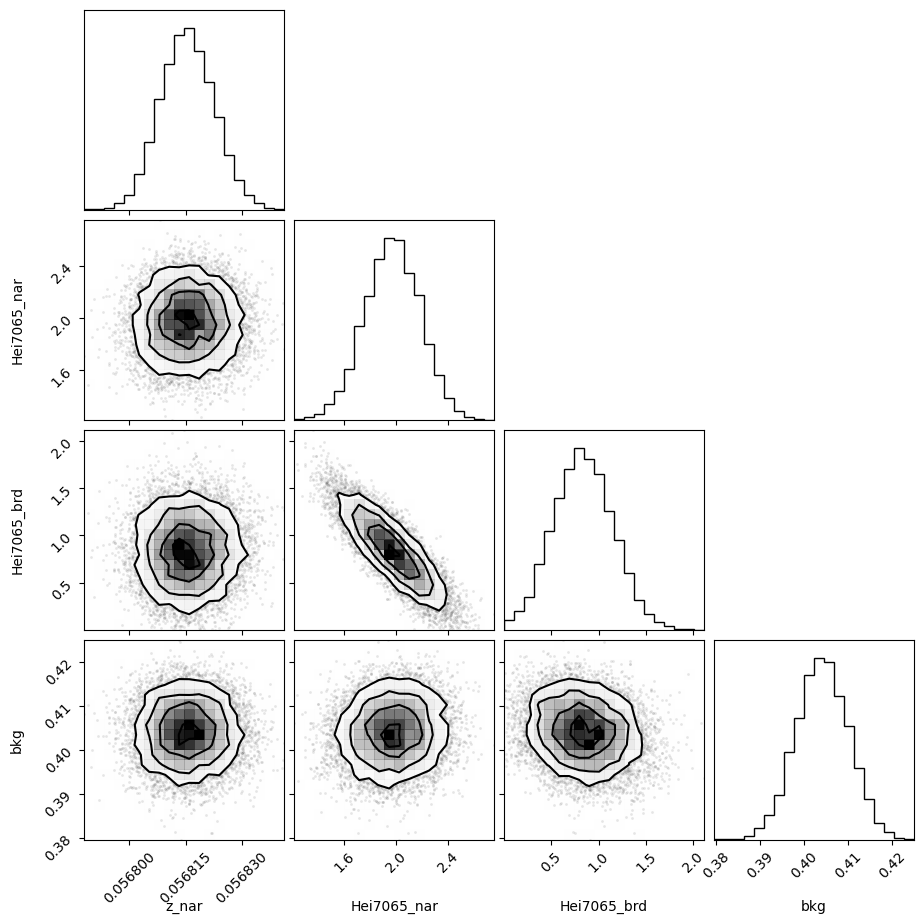

In [46]:
corner.corner(out_hei7065.flatchain, labels=out_hei7065.var_names);

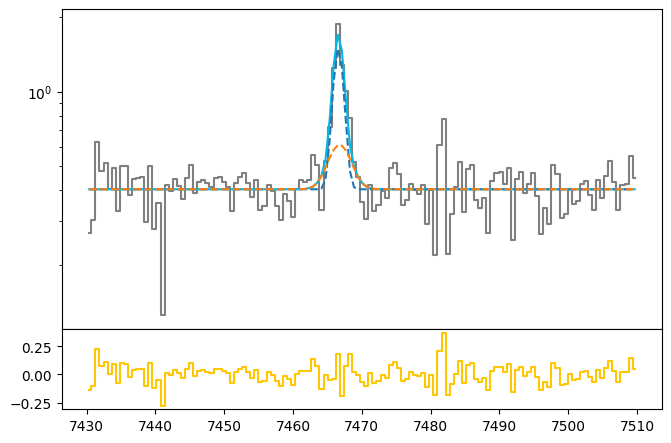

In [47]:
heia_nar_flux = out2_hei7065.params['Hei7065_nar'].value
heia_nar_std = out2_hei7065.params['Hei7065_nar'].stderr

heia_brd_flux = out2_hei7065.params['Hei7065_brd'].value
heia_brd_std = out2_hei7065.params['Hei7065_brd'].stderr

z_heia = out2_hei7065.params['z_nar'].value
z_heia_std = out2_hei7065.params['z_nar'].stderr

bkg_heia = out2_hei7065.params['bkg'].value
bkg_heia_std = out2_hei7065.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_7065.wavelength, hei_7065.flux, color='gray', label='Data', where='mid')

heia_nar = gaussian(hei_7065.wavelength, heia_nar_flux, wave_cat['HeI7065'], z_heia, upy.nominal_values(sigma_nar_7065))
heia_brd = gaussian(hei_7065.wavelength, heia_brd_flux, wave_cat['HeI7065'], z_heia * z_ratio, upy.nominal_values(sigma_brd_7065))

heia = heia_nar + heia_brd

ax.plot(hei_7065.wavelength, bkg_heia + heia, color=c[0])
ax.plot(hei_7065.wavelength, bkg_heia + heia_nar, ls='--')
ax.plot(hei_7065.wavelength, bkg_heia + heia_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_7065.wavelength, hei_7065.flux - bkg_heia - heia, color=c[3], where='mid')

In [48]:
# EW
EW_HeI_7065_nar = ufloat(heia_nar_flux, heia_nar_std) / ufloat(bkg_heia, bkg_heia_std)
EW_HeI_7065_brd = ufloat(heia_brd_flux, heia_brd_std) / ufloat(bkg_heia, bkg_heia_std)
EW_HeI_7065 = (ufloat(heia_nar_flux, heia_nar_std) + ufloat(heia_brd_flux, heia_brd_std)) / ufloat(bkg_heia, bkg_heia_std)

# HeI 6678

In [49]:
sigma_arc_6678 = (m * wave_cat['HeI6678']*(1 + z_BN[igal])) + n

sigma_nar_6678 = sigma_arc_6678
sigma_brd_6678 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6678**2))

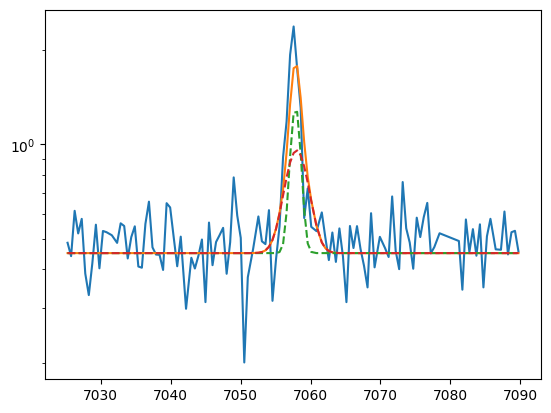

In [50]:
plt.plot(hei_6678.wavelength, hei_6678.flux)
bkg = 4.5e-1

hei6678_nar = gaussian(hei_6678.wavelength, 1.5, wave_cat['HeI6678'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6678))
hei6678_brd = gaussian(hei_6678.wavelength, 2, wave_cat['HeI6678'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6678))

hei6678 = hei6678_nar + hei6678_brd

plt.plot(hei_6678.wavelength, hei6678 + bkg)
plt.plot(hei_6678.wavelength, hei6678_nar + bkg, ls='--')
plt.plot(hei_6678.wavelength, hei6678_brd + bkg, ls='--')
plt.yscale('log')

In [51]:
params_6678 = Parameters()
params_6678.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_6678.add('z_ratio', value=z_ratio, vary=False)
params_6678.add('sigma_hei6678_nar', value=upy.nominal_values(sigma_nar_6678), vary=False)
params_6678.add('sigma_hei6678_brd', value=upy.nominal_values(sigma_brd_6678), vary=False)
params_6678.add('Hei6678_nar', value=1.5, min=0.)
params_6678.add('Hei6678_brd', value=2.0, min=0.)
params_6678.add('bkg', value=4.5e-1, min=0.)

def residual_hei6678(params_6678, x, data, uncertainty):
    
    z_nar = params_6678['z_nar']
    z_brd = params_6678['z_nar'] * params_6678['z_ratio']
    sigma_hei6678_nar = params_6678['sigma_hei6678_nar']
    sigma_hei6678_brd = params_6678['sigma_hei6678_brd']
    hei6678_nar_flux = params_6678['Hei6678_nar']
    hei6678_brd_flux = params_6678['Hei6678_brd']
    bkg = params_6678['bkg']
    
    x = hei_6678.wavelength
    model = gaussian(x, hei6678_nar_flux, wave_cat['HeI6678'], z_nar, sigma_hei6678_nar) + \
            gaussian(x, hei6678_brd_flux, wave_cat['HeI6678'], z_brd, sigma_hei6678_brd)
    return (model + bkg - hei_6678.flux) / hei_6678.noise

In [52]:
np.random.seed(1146)
out_hei6678 = minimize(residual_hei6678, params_6678, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 130.50it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [32.50128926 75.51953878 73.70977723 51.71976655]


In [53]:
out_hei6678.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681070,5.1112e-06,(0.01%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_hei6678_nar,0.68541037,,,0.6854103691300999,-inf,inf,False
sigma_hei6678_brd,1.57257801,,,1.5725780094385091,-inf,inf,False
Hei6678_nar,2.78037279,0.19777019,(7.11%),1.5,0.00000000,inf,True
Hei6678_brd,0.78375159,0.27535193,(35.13%),2.0,0.00000000,inf,True
bkg,0.48393444,0.00743989,(1.54%),0.45,0.00000000,inf,True


In [54]:
np.random.seed(1146)
out2_hei6678 = minimize(residual_hei6678, out_hei6678.params, args=(1, 1, 1),
                   method='leastsq')

In [55]:
out2_hei6678.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681066,6.4371e-06,(0.01%),0.056810698947695894,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_hei6678_nar,0.68541037,0.00000000,(0.00%),0.6854103691300999,-inf,inf,False
sigma_hei6678_brd,1.57257801,0.00000000,(0.00%),1.5725780094385091,-inf,inf,False
Hei6678_nar,2.79114738,0.24317701,(8.71%),2.7803727890250425,0.00000000,inf,True
Hei6678_brd,0.76493945,0.34118297,(44.60%),0.7837515874662013,0.00000000,inf,True
bkg,0.48375282,0.00906397,(1.87%),0.48393443667418157,0.00000000,inf,True


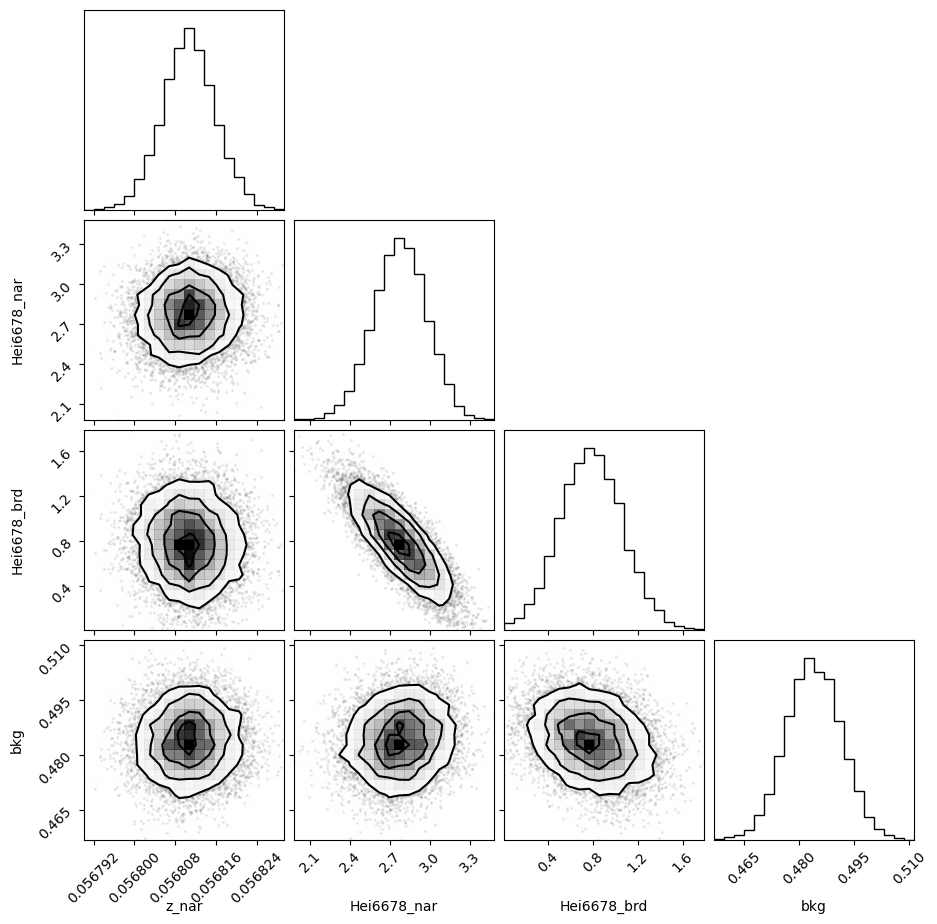

In [56]:
corner.corner(out_hei6678.flatchain, labels=out_hei6678.var_names);

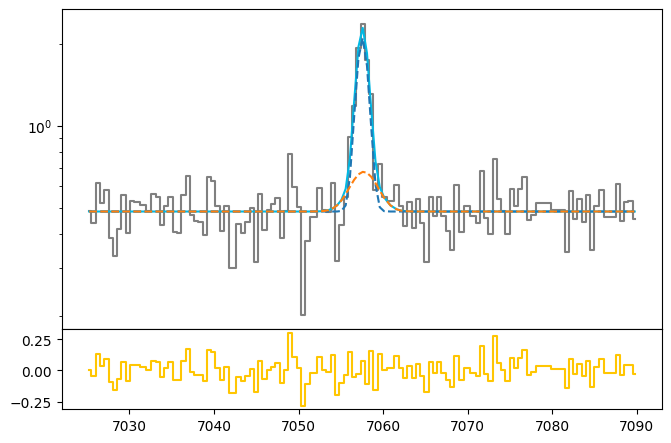

In [57]:
heib_nar_flux = out2_hei6678.params['Hei6678_nar'].value
heib_nar_std = out2_hei6678.params['Hei6678_nar'].stderr

heib_brd_flux = out2_hei6678.params['Hei6678_brd'].value
heib_brd_std = out2_hei6678.params['Hei6678_brd'].stderr

z_heib = out2_hei6678.params['z_nar'].value
z_heib_std = out2_hei6678.params['z_nar'].stderr

bkg_heib = out2_hei6678.params['bkg'].value
bkg_heib_std = out2_hei6678.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_6678.wavelength, hei_6678.flux, color='gray', label='Data', where='mid')

heib_nar = gaussian(hei_6678.wavelength, heib_nar_flux, wave_cat['HeI6678'], z_heib, upy.nominal_values(sigma_nar_6678))
heib_brd = gaussian(hei_6678.wavelength, heib_brd_flux, wave_cat['HeI6678'], z_heib * z_ratio, upy.nominal_values(sigma_brd_6678))

heib = heib_nar + heib_brd

ax.plot(hei_6678.wavelength, bkg_heib + heib, color=c[0])
ax.plot(hei_6678.wavelength, bkg_heib + heib_nar, ls='--')
ax.plot(hei_6678.wavelength, bkg_heib + heib_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_6678.wavelength, hei_6678.flux - bkg_heib - heib, color=c[3], where='mid')

In [58]:
# EW
EW_HeI_6678_nar = ufloat(heib_nar_flux, heib_nar_std) / ufloat(bkg_heib, bkg_heib_std)
EW_HeI_6678_brd = ufloat(heib_brd_flux, heib_brd_std) / ufloat(bkg_heib, bkg_heib_std)
EW_HeI_6678 = (ufloat(heib_nar_flux, heib_nar_std) + ufloat(heib_brd_flux, heib_brd_std)) / ufloat(bkg_heib, bkg_heib_std)

# HeI 5875

In [59]:
sigma_arc_5875 = (m * wave_cat['HeI5875']*(1 + z_BN[igal])) + n

sigma_nar_5875 = sigma_arc_5875
sigma_brd_5875 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5875**2))

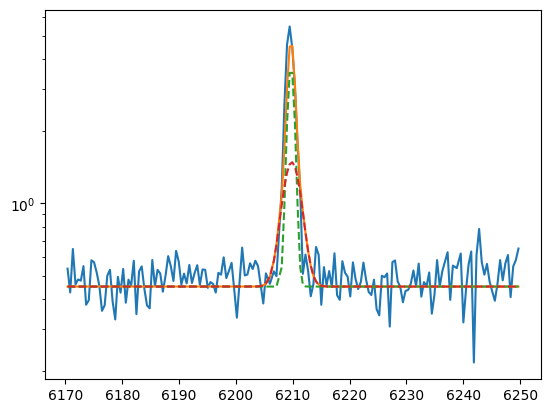

In [60]:
plt.plot(hei_5875.wavelength, hei_5875.flux)
bkg = 4.5e-1

hei5875_nar = gaussian(hei_5875.wavelength, 5, wave_cat['HeI5875'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5875))
hei5875_brd = gaussian(hei_5875.wavelength, 4, wave_cat['HeI5875'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5875))

hei5875 = hei5875_nar + hei5875_brd

plt.plot(hei_5875.wavelength, hei5875 + bkg)
plt.plot(hei_5875.wavelength, hei5875_nar + bkg, ls='--')
plt.plot(hei_5875.wavelength, hei5875_brd + bkg, ls='--')
plt.yscale('log')

In [61]:
params_5875 = Parameters()
params_5875.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_5875.add('z_ratio', value=z_ratio, vary=False)
params_5875.add('sigma_hei5875_nar', value=upy.nominal_values(sigma_nar_5875), vary=False)
params_5875.add('sigma_hei5875_brd', value=upy.nominal_values(sigma_brd_5875), vary=False)
params_5875.add('Hei5875_nar', value=5, min=0.)
params_5875.add('Hei5875_brd', value=4, min=0.)
params_5875.add('bkg', value=4.5e-1, min=0.)

def residual_hei5875(params_5875, x, data, uncertainty):
    
    z_nar = params_5875['z_nar']
    z_brd = params_5875['z_nar'] * params_5875['z_ratio']
    sigma_hei5875_nar = params_5875['sigma_hei5875_nar']
    sigma_hei5875_brd = params_5875['sigma_hei5875_brd']
    hei5875_nar_flux = params_5875['Hei5875_nar']
    hei5875_brd_flux = params_5875['Hei5875_brd']
    bkg = params_5875['bkg']
    
    x = hei_5875.wavelength
    model = gaussian(x, hei5875_nar_flux, wave_cat['HeI5875'], z_nar, sigma_hei5875_nar) + \
            gaussian(x, hei5875_brd_flux, wave_cat['HeI5875'], z_brd, sigma_hei5875_brd)
    return (model + bkg - hei_5875.flux) / hei_5875.noise

In [62]:
np.random.seed(1146)
out_hei5875 = minimize(residual_hei5875, params_5875, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 121.68it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [28.16543443 76.72509207 56.21680703 46.46216853]


In [63]:
out_hei5875.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05682301,2.4203e-06,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_hei5875_nar,0.60791398,,,0.6079139794270999,-inf,inf,False
sigma_hei5875_brd,1.54038100,,,1.5403810009349688,-inf,inf,False
Hei5875_nar,6.62636147,0.18408661,(2.78%),5,0.00000000,inf,True
Hei5875_brd,3.33654863,0.24883938,(7.46%),4,0.00000000,inf,True
bkg,0.48160825,0.00549772,(1.14%),0.45,0.00000000,inf,True


In [64]:
np.random.seed(1146)
out2_hei5875 = minimize(residual_hei5875, out_hei5875.params, args=(1, 1, 1),
                   method='leastsq')

In [65]:
out2_hei5875.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05682293,2.9745e-06,(0.01%),0.05682300810992266,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_hei5875_nar,0.60791398,0.00000000,(0.00%),0.6079139794270999,-inf,inf,False
sigma_hei5875_brd,1.54038100,0.00000000,(0.00%),1.5403810009349688,-inf,inf,False
Hei5875_nar,6.62292420,0.24651467,(3.72%),6.626361468932727,0.00000000,inf,True
Hei5875_brd,3.34734205,0.33377986,(9.97%),3.3365486310392765,0.00000000,inf,True
bkg,0.48158343,0.00745986,(1.55%),0.4816082452355771,0.00000000,inf,True


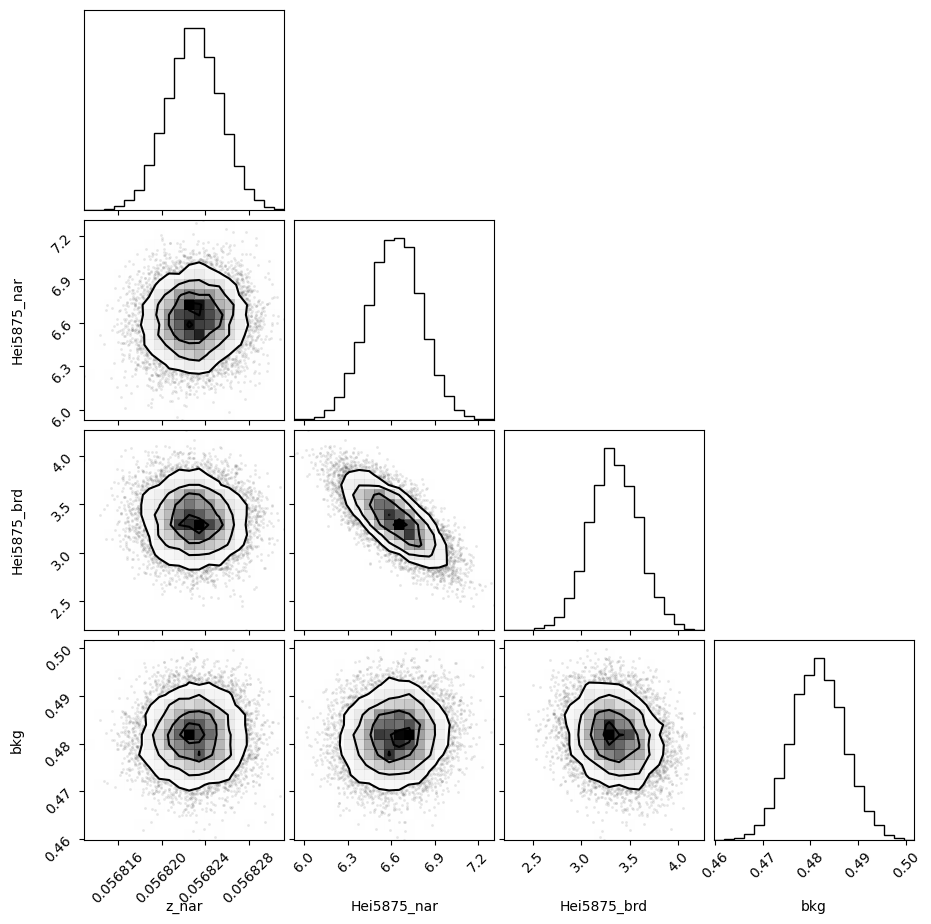

In [66]:
corner.corner(out_hei5875.flatchain, labels=out_hei5875.var_names);

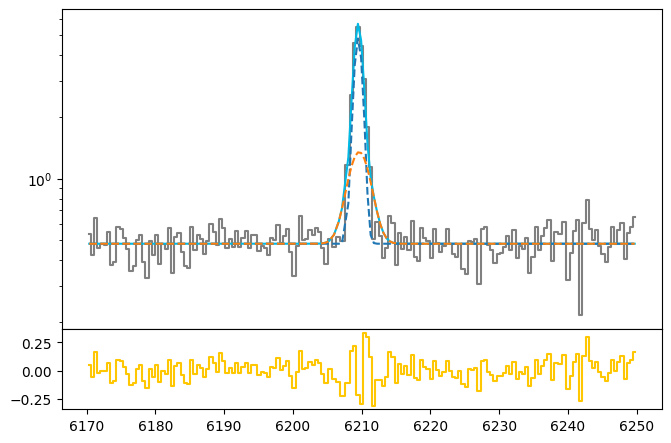

In [67]:
heic_nar_flux = out2_hei5875.params['Hei5875_nar'].value
heic_nar_std = out2_hei5875.params['Hei5875_nar'].stderr

heic_brd_flux = out2_hei5875.params['Hei5875_brd'].value
heic_brd_std = out2_hei5875.params['Hei5875_brd'].stderr

z_heic = out2_hei5875.params['z_nar'].value
z_heic_std = out2_hei5875.params['z_nar'].stderr

bkg_heic = out2_hei5875.params['bkg'].value
bkg_heic_std = out2_hei5875.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_5875.wavelength, hei_5875.flux, color='gray', label='Data', where='mid')

heic_nar = gaussian(hei_5875.wavelength, heic_nar_flux, wave_cat['HeI5875'], z_heic, upy.nominal_values(sigma_nar_5875))
heic_brd = gaussian(hei_5875.wavelength, heic_brd_flux, wave_cat['HeI5875'], z_heic * z_ratio, upy.nominal_values(sigma_brd_5875))

heic = heic_nar + heic_brd

ax.plot(hei_5875.wavelength, bkg_heic + heic, color=c[0])
ax.plot(hei_5875.wavelength, bkg_heic + heic_nar, ls='--')
ax.plot(hei_5875.wavelength, bkg_heic + heic_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_5875.wavelength, hei_5875.flux - bkg_heic - heic, color=c[3], where='mid')

In [68]:
# EW
EW_HeI_5875_nar = ufloat(heic_nar_flux, heic_nar_std) / ufloat(bkg_heic, bkg_heic_std)
EW_HeI_5875_brd = ufloat(heic_brd_flux, heic_brd_std) / ufloat(bkg_heic, bkg_heic_std)
EW_HeI_5875 = (ufloat(heic_nar_flux, heic_nar_std) + ufloat(heic_brd_flux, heic_brd_std)) / ufloat(bkg_heic, bkg_heic_std)

# HeI 4471

In [69]:
sigma_arc_4471 = (m * wave_cat['HeI4471']*(1 + z_BN[igal])) + n

sigma_nar_4471 = sigma_arc_4471
sigma_brd_4471 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4471**2))

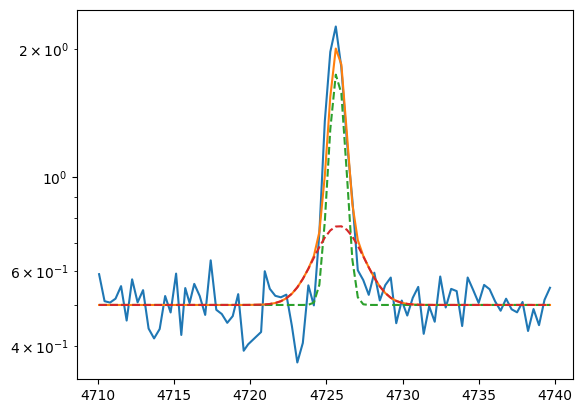

In [70]:
plt.plot(hei_4471.wavelength, hei_4471.flux)
bkg = 5.0e-1

hei4471_nar = gaussian(hei_4471.wavelength, 1.5, wave_cat['HeI4471'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4471))
hei4471_brd = gaussian(hei_4471.wavelength, 1, wave_cat['HeI4471'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4471))

hei4471 = hei4471_nar + hei4471_brd

plt.plot(hei_4471.wavelength, hei4471 + bkg)
plt.plot(hei_4471.wavelength, hei4471_nar + bkg, ls='--')
plt.plot(hei_4471.wavelength, hei4471_brd + bkg, ls='--')
plt.yscale('log')

In [71]:
params_4471 = Parameters()
params_4471.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_4471.add('z_ratio', value=z_ratio, vary=False)
params_4471.add('sigma_hei4471_nar', value=upy.nominal_values(sigma_nar_4471), vary=False)
params_4471.add('sigma_hei4471_brd', value=upy.nominal_values(sigma_brd_4471), vary=False)
params_4471.add('Hei4471_nar', value=1.5, min=0.)
params_4471.add('Hei4471_brd', value=1.0, min=0.)
params_4471.add('bkg', value=5.0e-1, min=0.)

def residual_hei4471(params_4471, x, data, uncertainty):
    
    z_nar = params_4471['z_nar']
    z_brd = params_4471['z_nar'] * params_4471['z_ratio']
    sigma_hei4471_nar = params_4471['sigma_hei4471_nar']
    sigma_hei4471_brd = params_4471['sigma_hei4471_brd']
    hei4471_nar_flux = params_4471['Hei4471_nar']
    hei4471_brd_flux = params_4471['Hei4471_brd']
    bkg = params_4471['bkg']
    
    x = hei_4471.wavelength
    model = gaussian(x, hei4471_nar_flux, wave_cat['HeI4471'], z_nar, sigma_hei4471_nar) + \
            gaussian(x, hei4471_brd_flux, wave_cat['HeI4471'], z_brd, sigma_hei4471_brd)
    return (model + bkg - hei_4471.flux) / hei_4471.noise

In [72]:
np.random.seed(1146)
out_hei4471 = minimize(residual_hei4471, params_4471, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 129.92it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [36.18485538 63.90488475 57.86286678 41.59633665]


In [73]:
out_hei4471.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05682900,4.1498e-06,(0.01%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_hei4471_nar,0.47232298,,,0.47232298266101996,-inf,inf,False
sigma_hei4471_brd,1.49208017,,,1.4920801659456258,-inf,inf,False
Hei4471_nar,1.99493606,0.08160222,(4.09%),1.5,0.00000000,inf,True
Hei4471_brd,0.59371398,0.13614648,(22.93%),1.0,0.00000000,inf,True
bkg,0.50125081,0.00713260,(1.42%),0.5,0.00000000,inf,True


In [74]:
np.random.seed(1146)
out2_hei4471 = minimize(residual_hei4471, out_hei4471.params, args=(1, 1, 1),
                   method='leastsq')

In [75]:
out2_hei4471.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05682892,4.1737e-06,(0.01%),0.056829002215038824,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_hei4471_nar,0.47232298,0.00000000,(0.00%),0.47232298266101996,-inf,inf,False
sigma_hei4471_brd,1.49208017,0.00000000,(0.00%),1.4920801659456258,-inf,inf,False
Hei4471_nar,1.99650980,0.08581834,(4.30%),1.9949360606653233,0.00000000,inf,True
Hei4471_brd,0.59059483,0.14515170,(24.58%),0.5937139751215423,0.00000000,inf,True
bkg,0.50124704,0.00737437,(1.47%),0.5012508116030889,0.00000000,inf,True


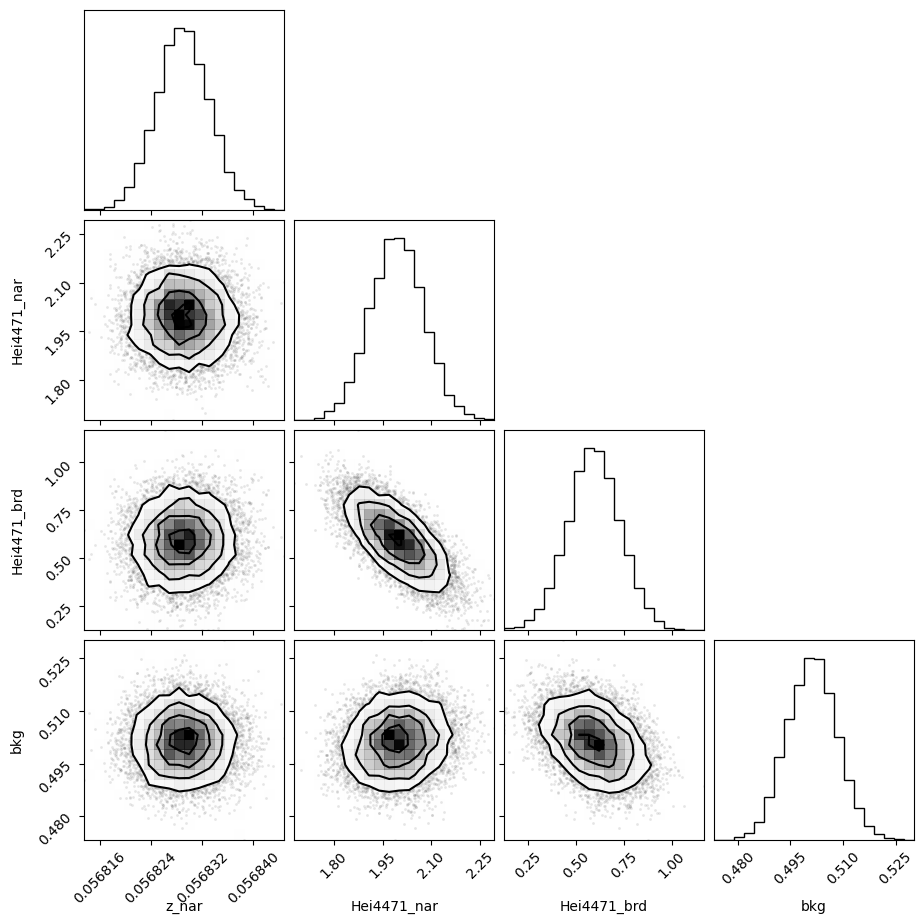

In [76]:
corner.corner(out_hei4471.flatchain, labels=out_hei4471.var_names);

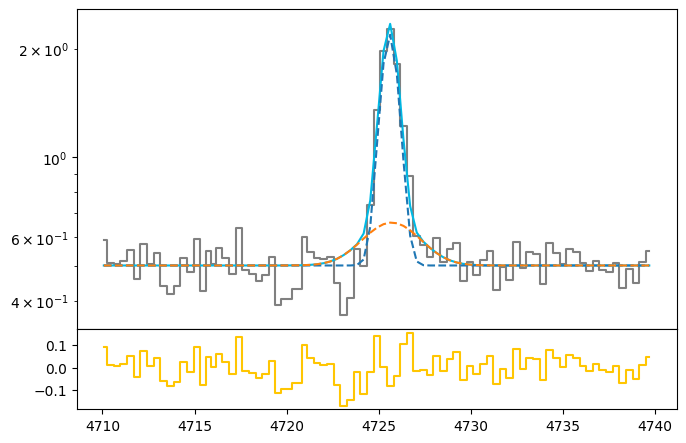

In [77]:
heid_nar_flux = out2_hei4471.params['Hei4471_nar'].value
heid_nar_std = out2_hei4471.params['Hei4471_nar'].stderr

heid_brd_flux = out2_hei4471.params['Hei4471_brd'].value
heid_brd_std = out2_hei4471.params['Hei4471_brd'].stderr

z_heid = out2_hei4471.params['z_nar'].value
z_heid_std = out2_hei4471.params['z_nar'].stderr

bkg_heid = out2_hei4471.params['bkg'].value
bkg_heid_std = out2_hei4471.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_4471.wavelength, hei_4471.flux, color='gray', label='Data', where='mid')

heid_nar = gaussian(hei_4471.wavelength, heid_nar_flux, wave_cat['HeI4471'], z_heid, upy.nominal_values(sigma_nar_4471))
heid_brd = gaussian(hei_4471.wavelength, heid_brd_flux, wave_cat['HeI4471'], z_heid * z_ratio, upy.nominal_values(sigma_brd_4471))

heid = heid_nar + heid_brd

ax.plot(hei_4471.wavelength, bkg_heid + heid, color=c[0])
ax.plot(hei_4471.wavelength, bkg_heid + heid_nar, ls='--')
ax.plot(hei_4471.wavelength, bkg_heid + heid_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_4471.wavelength, hei_4471.flux - bkg_heid - heid, color=c[3], where='mid')

In [78]:
# EW
EW_HeI_4471_nar = ufloat(heid_nar_flux, heid_nar_std) / ufloat(bkg_heid, bkg_heid_std)
EW_HeI_4471_brd = ufloat(heid_brd_flux, heid_brd_std) / ufloat(bkg_heid, bkg_heid_std)
EW_HeI_4471 = (ufloat(heid_nar_flux, heid_nar_std) + ufloat(heid_brd_flux, heid_brd_std)) / ufloat(bkg_heid, bkg_heid_std)

# [SII]6716 + [SII]6730

In [79]:
sigma_arc_6730 = (m * wave_cat['[SII]6730']*(1 + z_BN[igal])) + n

sigma_nar_6730 = sigma_arc_6730
sigma_brd_6730 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6730**2))

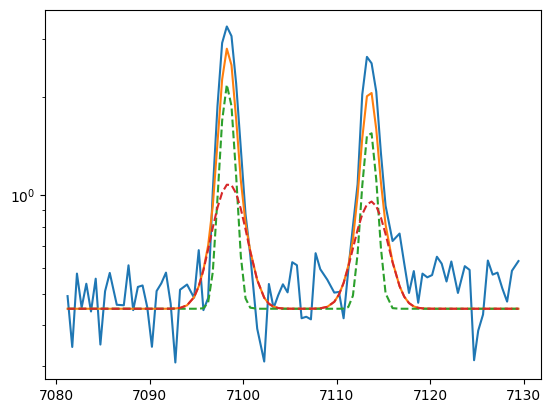

In [80]:
plt.plot(sii.wavelength, sii.flux)
bkg = 4.5e-1

siia_nar = gaussian(sii.wavelength, 2.0, wave_cat['[SII]6730'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siia_brd = gaussian(sii.wavelength, 2.0, wave_cat['[SII]6730'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siib_nar = gaussian(sii.wavelength, 3.0, wave_cat['[SII]6716'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siib_brd = gaussian(sii.wavelength, 2.5, wave_cat['[SII]6716'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

plt.plot(sii.wavelength, siia + siib + bkg)
plt.plot(sii.wavelength, siia_nar + siib_nar + bkg, ls='--')
plt.plot(sii.wavelength, siia_brd + siib_brd + bkg, ls='--')
plt.yscale('log')

In [81]:
params_sii = Parameters()
params_sii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii.add('z_ratio', value=z_ratio, vary=False)
params_sii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6730), vary=False)
params_sii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6730), vary=False)
params_sii.add('Siia_nar', value=0., vary=False)
params_sii.add('Siia_brd', value=2.0, min=0.)
params_sii.add('Siib_nar', value=0., vary=False)
params_sii.add('Siib_brd', value=2.5, min=0.)
params_sii.add('bkg', value=4.5e-1, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    
    z_nar = params_sii['z_nar']
    z_brd = params_sii['z_nar'] * params_sii['z_ratio']
    sigma_nar = params_sii['sigma_nar']
    sigma_brd = params_sii['sigma_brd']
    siia_nar_flux = params_sii['Siia_nar']
    siia_brd_flux = params_sii['Siia_brd']
    siib_nar_flux = params_sii['Siib_nar']
    siib_brd_flux = params_sii['Siib_brd']
    bkg = params_sii['bkg']
    
    x = sii.wavelength
    model_siia = gaussian(x, siia_nar_flux, wave_cat['[SII]6730'], z_nar, sigma_nar) + \
                 gaussian(x, siia_brd_flux, wave_cat['[SII]6730'], z_brd, sigma_brd)
    model_siib = gaussian(x, siib_nar_flux, wave_cat['[SII]6716'], z_nar, sigma_nar) + \
                 gaussian(x, siib_brd_flux, wave_cat['[SII]6716'], z_brd, sigma_brd)
    model = model_siia + model_siib
    return (model + bkg - sii.flux) / sii.noise

In [82]:
np.random.seed(1146)
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                    method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:25<00:00, 98.40it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [38.81295934 96.66899546 87.76685864 38.59024075]


In [83]:
out_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05684718,4.8454e-06,(0.01%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.69049587,,,0.6904958735564999,-inf,inf,False
sigma_brd,1.57480119,,,1.5748011852475465,-inf,inf,False
Siia_nar,0.00000000,,,0.0,-inf,inf,False
Siia_brd,5.72049281,0.19058486,(3.33%),2.0,0.00000000,inf,True
Siib_nar,0.00000000,,,0.0,-inf,inf,False
Siib_brd,7.04309375,0.19722138,(2.80%),2.5,0.00000000,inf,True
bkg,0.45974201,0.00971599,(2.11%),0.45,0.00000000,inf,True


In [84]:
np.random.seed(1146)
out2_sii = minimize(residual_sii, out_sii.params, args=(1, 1, 1),
                    method='leastsq')

In [85]:
out2_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05684728,1.5571e-05,(0.03%),0.05684718200848162,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.69049587,0.00000000,(0.00%),0.6904958735564999,-inf,inf,False
sigma_brd,1.57480119,0.00000000,(0.00%),1.5748011852475465,-inf,inf,False
Siia_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Siia_brd,5.72236495,0.51804920,(9.05%),5.720492808853809,0.00000000,inf,True
Siib_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Siib_brd,7.05193042,0.53646094,(7.61%),7.043093754512111,0.00000000,inf,True
bkg,0.45991473,0.02627837,(5.71%),0.45974200957353933,0.00000000,inf,True


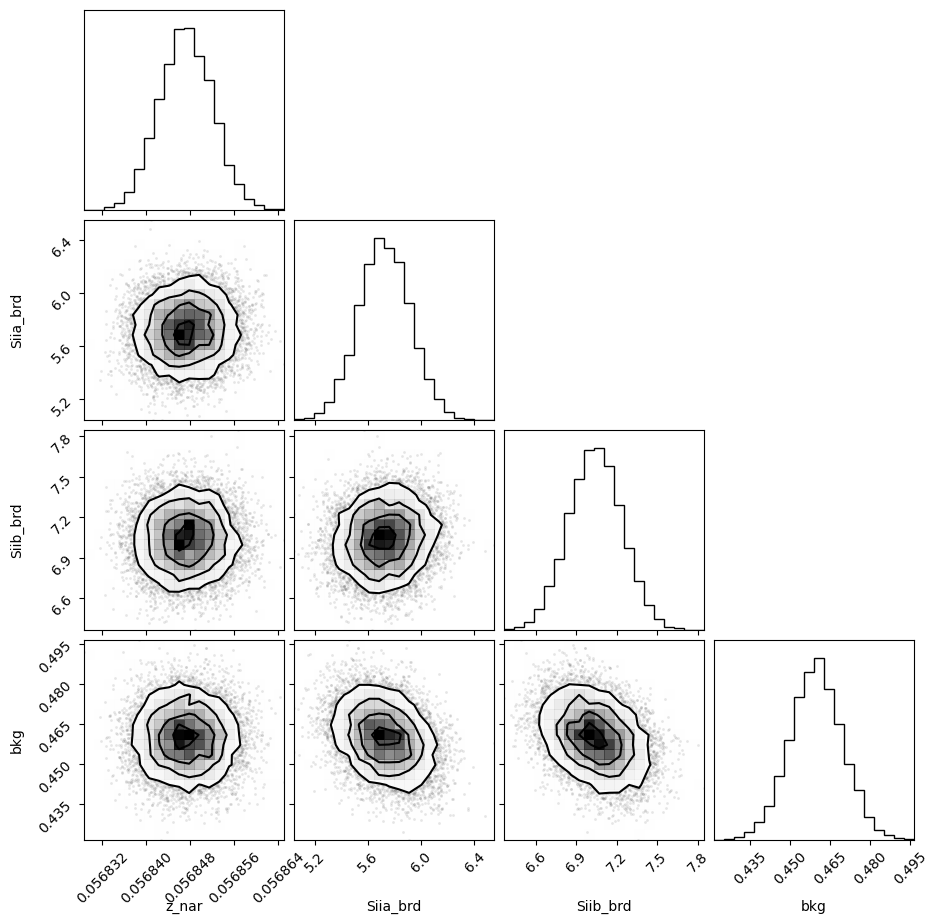

In [86]:
corner.corner(out_sii.flatchain, labels=out_sii.var_names);

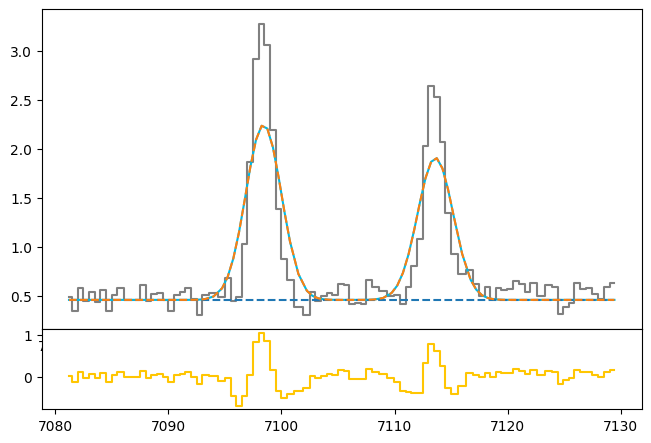

In [87]:
siia_nar_flux = out2_sii.params['Siia_nar'].value
siia_nar_std = out2_sii.params['Siia_nar'].stderr

siia_brd_flux = out2_sii.params['Siia_brd'].value
siia_brd_std = out2_sii.params['Siia_brd'].stderr

siib_nar_flux = out2_sii.params['Siib_nar'].value
siib_nar_std = out2_sii.params['Siib_nar'].stderr

siib_brd_flux = out2_sii.params['Siib_brd'].value
siib_brd_std = out2_sii.params['Siib_brd'].stderr

z_sii = out2_sii.params['z_nar'].value
z_sii_std = out2_sii.params['z_nar'].stderr

bkg_sii = out2_sii.params['bkg'].value
bkg_sii_std = out2_sii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii.wavelength, sii.flux, color='gray', label='Data', where='mid')

siia_nar = gaussian(sii.wavelength, siia_nar_flux, wave_cat['[SII]6730'], z_sii, upy.nominal_values(sigma_nar_6730))
siib_nar = gaussian(sii.wavelength, siib_nar_flux, wave_cat['[SII]6716'], z_sii, upy.nominal_values(sigma_nar_6730))

siia_brd = gaussian(sii.wavelength, siia_brd_flux, wave_cat['[SII]6730'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))
siib_brd = gaussian(sii.wavelength, siib_brd_flux, wave_cat['[SII]6716'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

ax.plot(sii.wavelength, bkg_sii + siia + siib, color=c[0])
ax.plot(sii.wavelength, bkg_sii + siia_nar + siib_nar, ls='--')
ax.plot(sii.wavelength, bkg_sii + siia_brd + siib_brd, ls='--')
#plt.yscale('log')
ax1.step(sii.wavelength, sii.flux - bkg_sii - siia - siib, color=c[3], where='mid')

In [88]:
# EW
EW_SII_6730_nar = ufloat(siia_nar_flux, siia_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730_brd = ufloat(siia_brd_flux, siia_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730 = (ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

EW_SII_6716_nar = ufloat(siib_nar_flux, siib_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716_brd = ufloat(siib_brd_flux, siib_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716 = (ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

# H$\beta$

In [89]:
sigma_arc_hb = (m * wave_cat['Hb']*(1 + z_BN[igal])) + n

sigma_nar_hb = sigma_arc_hb
sigma_brd_hb = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hb**2))

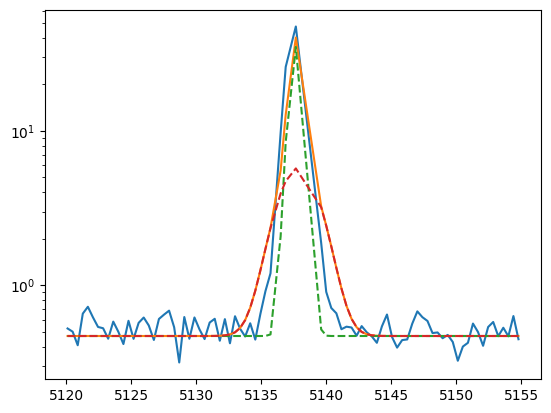

In [90]:
plt.plot(hbeta.wavelength, hbeta.flux)
bkg = 4.7e-1

hb_nar = gaussian(hbeta.wavelength, 4.5e1, wave_cat['Hb'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, 2.0e1, wave_cat['Hb'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

plt.plot(hbeta.wavelength, hb + bkg)
plt.plot(hbeta.wavelength, hb_nar + bkg, ls='--')
plt.plot(hbeta.wavelength, hb_brd + bkg, ls='--')
plt.yscale('log')

In [91]:
params_hb = Parameters()
params_hb.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hb.add('z_ratio', value=z_ratio, vary=False)
params_hb.add('sigma_nar', value=upy.nominal_values(sigma_nar_hb), vary=False)
params_hb.add('sigma_brd', value=upy.nominal_values(sigma_brd_hb), vary=False)
params_hb.add('Hb_nar', value=4.5e1, min=0.)
params_hb.add('Hb_brd', value=2.0e1, min=0.)
params_hb.add('bkg', value=4.7e-1, min=0.)

def residual_hb(params_hb, x, data, uncertainty):
    
    z_nar = params_hb['z_nar']
    z_brd = params_hb['z_nar'] * params_hb['z_ratio']
    sigma_nar = params_hb['sigma_nar']
    sigma_brd = params_hb['sigma_brd']
    hb_nar_flux = params_hb['Hb_nar']
    hb_brd_flux = params_hb['Hb_brd']
    bkg = params_hb['bkg']
    
    x = hbeta.wavelength
    model = gaussian(x, hb_nar_flux, wave_cat['Hb'], z_nar, sigma_nar) + \
            gaussian(x, hb_brd_flux, wave_cat['Hb'], z_brd, sigma_brd)
    return (model + bkg - hbeta.flux) / hbeta.noise

In [92]:
np.random.seed(1146)
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 129.42it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 41.70125662 120.08614206 123.3802318   54.63783913]


In [93]:
out_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05679813,9.6591e-07,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.50997080,,,0.5099707988850001,-inf,inf,False
sigma_brd,1.50442163,,,1.5044216288573922,-inf,inf,False
Hb_nar,61.8330959,0.55269722,(0.89%),45.0,0.00000000,inf,True
Hb_brd,6.04485951,0.45582884,(7.54%),20.0,0.00000000,inf,True
bkg,0.50689887,0.00950332,(1.87%),0.47,0.00000000,inf,True


In [94]:
np.random.seed(1146)
out2_hb = minimize(residual_hb, out_hb.params, args=(1, 1, 1),
                   method='leastsq')

In [95]:
out2_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05679814,1.3495e-06,(0.00%),0.05679812792351013,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.50997080,0.00000000,(0.00%),0.5099707988850001,-inf,inf,False
sigma_brd,1.50442163,0.00000000,(0.00%),1.5044216288573922,-inf,inf,False
Hb_nar,61.8485213,0.75469118,(1.22%),61.83309586048729,0.00000000,inf,True
Hb_brd,6.05033656,0.62964641,(10.41%),6.044859505622443,0.00000000,inf,True
bkg,0.50718047,0.01324358,(2.61%),0.5068988653250485,0.00000000,inf,True


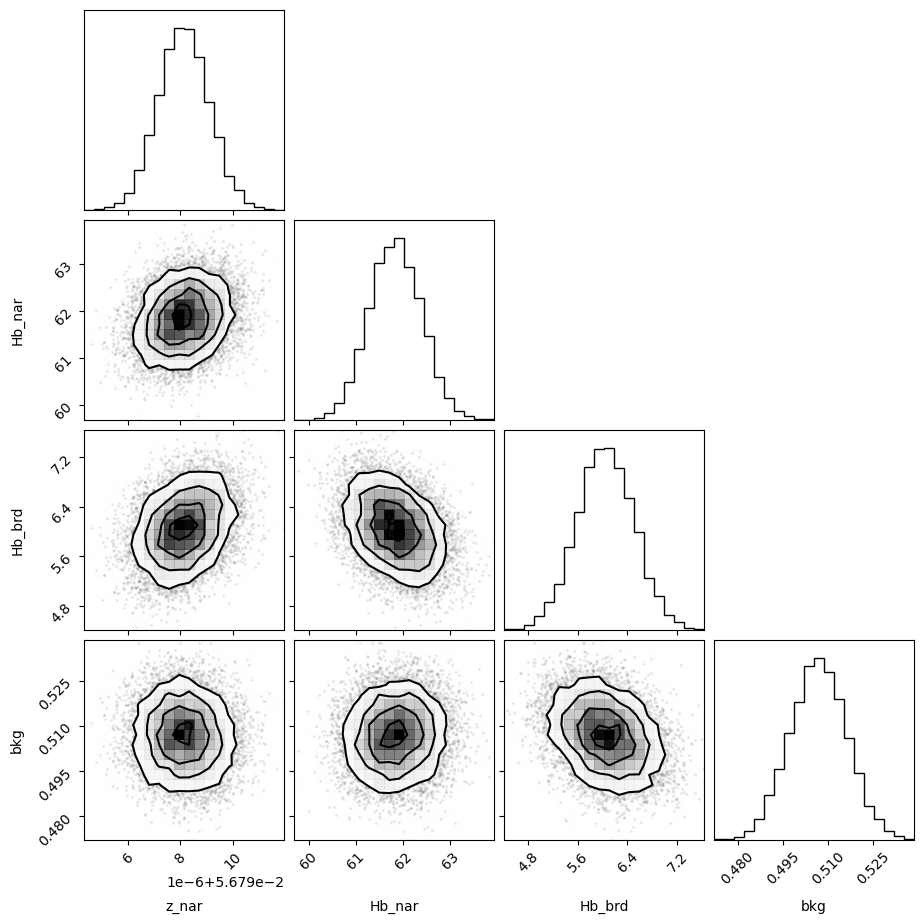

In [96]:
corner.corner(out_hb.flatchain, labels=out_hb.var_names);

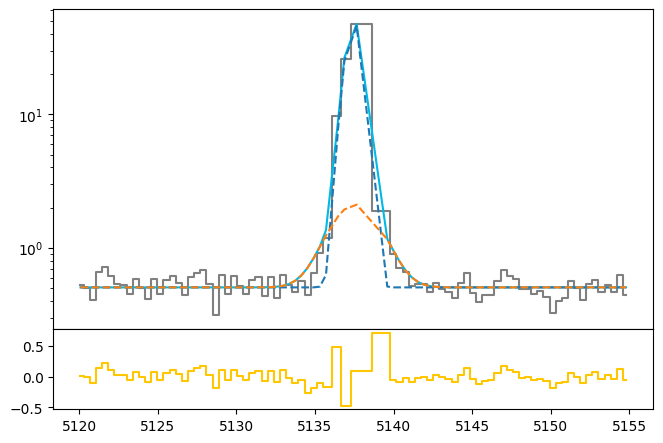

In [97]:
hb_nar_flux = out2_hb.params['Hb_nar'].value
hb_nar_std = out2_hb.params['Hb_nar'].stderr

hb_brd_flux = out2_hb.params['Hb_brd'].value
hb_brd_std = out2_hb.params['Hb_brd'].stderr

z_hb = out2_hb.params['z_nar'].value
z_hb_std = out2_hb.params['z_nar'].stderr

bkg_hb = out2_hb.params['bkg'].value
bkg_hb_std = out2_hb.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hbeta.wavelength, hbeta.flux, color='gray', label='Data', where='mid')

hb_nar = gaussian(hbeta.wavelength, hb_nar_flux, wave_cat['Hb'], z_hb, upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, hb_brd_flux, wave_cat['Hb'], z_hb * z_ratio, upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

ax.plot(hbeta.wavelength, bkg_hb + hb, color=c[0])
ax.plot(hbeta.wavelength, bkg_hb + hb_nar, ls='--')
ax.plot(hbeta.wavelength, bkg_hb + hb_brd, ls='--')
ax.set_yscale('log')
ax1.step(hbeta.wavelength, hbeta.flux - bkg_hb - hb, color=c[3], where='mid')

In [98]:
# EW
EW_Hb_nar = ufloat(hb_nar_flux, hb_nar_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb_brd = ufloat(hb_brd_flux, hb_brd_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb = (ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / ufloat(bkg_hb, bkg_hb_std)

# H$\gamma$

In [99]:
sigma_arc_hg = (m * wave_cat['Hg']*(1 + z_BN[igal])) + n

sigma_nar_hg = sigma_arc_hg
sigma_brd_hg = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hg**2))

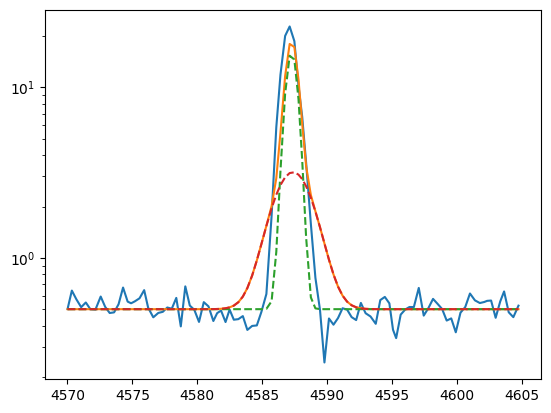

In [100]:
plt.plot(hgamma.wavelength, hgamma.flux)
bkg = 5e-1

hg_nar = gaussian(hgamma.wavelength, 1.8e1, wave_cat['Hg'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, 1e1, wave_cat['Hg'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

plt.plot(hgamma.wavelength, hg + bkg)
plt.plot(hgamma.wavelength, hg_nar + bkg, ls='--')
plt.plot(hgamma.wavelength, hg_brd + bkg, ls='--')
plt.yscale('log')

In [101]:
params_hg = Parameters()
params_hg.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hg.add('z_ratio', value=z_ratio, vary=False)
params_hg.add('sigma_nar', value=upy.nominal_values(sigma_nar_hg), vary=False)
params_hg.add('sigma_brd', value=upy.nominal_values(sigma_brd_hg), vary=False)
params_hg.add('Hg_nar', value=1.8e1, min=0.)
params_hg.add('Hg_brd', value=1.0e1, min=0.)
params_hg.add('bkg', value=5e-1, min=0.)

def residual_hg(params_hg, x, data, uncertainty):
    
    z_nar = params_hg['z_nar']
    z_brd = params_hg['z_nar'] * params_hg['z_ratio']
    sigma_nar = params_hg['sigma_nar']
    sigma_brd = params_hg['sigma_brd']
    hg_nar_flux = params_hg['Hg_nar']
    hg_brd_flux = params_hg['Hg_brd']
    bkg = params_hg['bkg']
    
    x = hgamma.wavelength
    model = gaussian(x, hg_nar_flux, wave_cat['Hg'], z_nar, sigma_nar) + \
            gaussian(x, hg_brd_flux, wave_cat['Hg'], z_brd, sigma_brd)
    return (model + bkg - hgamma.flux) / hgamma.noise

In [102]:
np.random.seed(1146)
out_hg = minimize(residual_hg, params_hg, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 127.21it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [27.65911397 81.12421304 90.48228517 72.55402241]


In [103]:
out_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681733,9.1881e-07,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.45967216,,,0.45967216272719996,-inf,inf,False
sigma_brd,1.48812389,,,1.4881238923036029,-inf,inf,False
Hg_nar,26.5515838,0.17982074,(0.68%),18.0,0.00000000,inf,True
Hg_brd,5.54749523,0.20789055,(3.75%),10.0,0.00000000,inf,True
bkg,0.47319870,0.00723176,(1.53%),0.5,0.00000000,inf,True


In [104]:
np.random.seed(1146)
out2_hg = minimize(residual_hg, out_hg.params, args=(1, 1, 1),
                   method='leastsq')

In [105]:
out2_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681740,3.0640e-06,(0.01%),0.056817326047406524,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.45967216,0.00000000,(0.00%),0.45967216272719996,-inf,inf,False
sigma_brd,1.48812389,0.00000000,(0.00%),1.4881238923036029,-inf,inf,False
Hg_nar,26.5573309,0.65449635,(2.46%),26.551583797682078,0.00000000,inf,True
Hg_brd,5.53294974,0.77850397,(14.07%),5.5474952275484615,0.00000000,inf,True
bkg,0.47361044,0.02647326,(5.59%),0.4731986950884163,0.00000000,inf,True


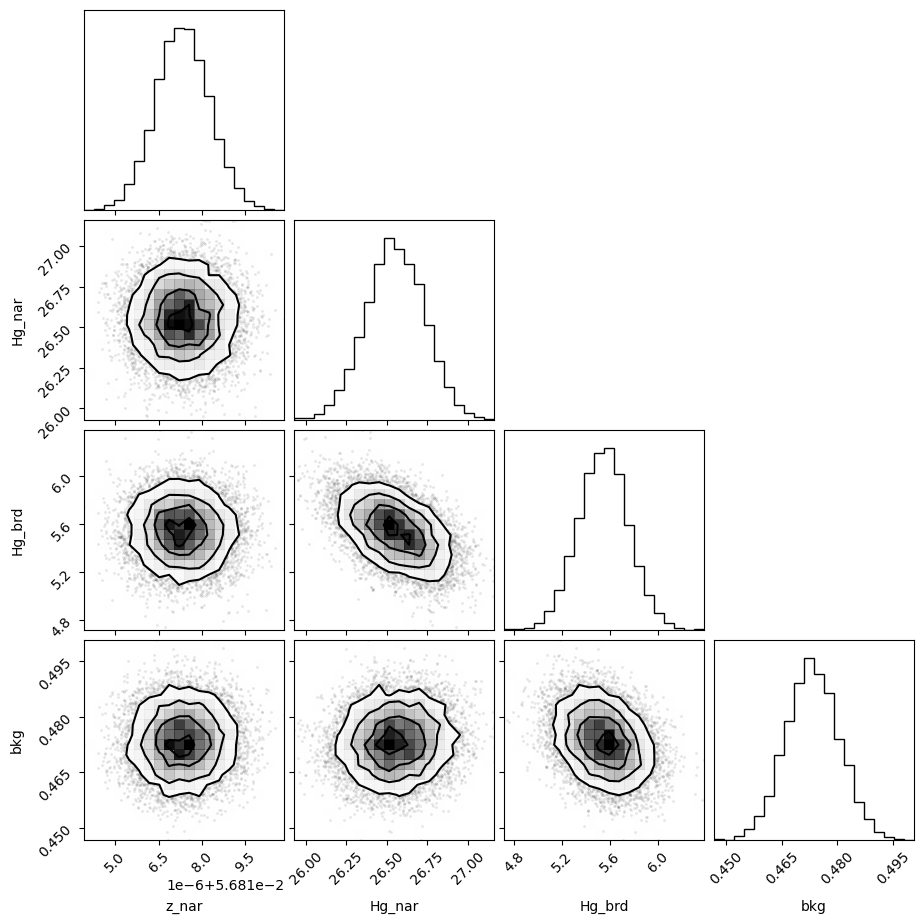

In [106]:
corner.corner(out_hg.flatchain, labels=out_hg.var_names);

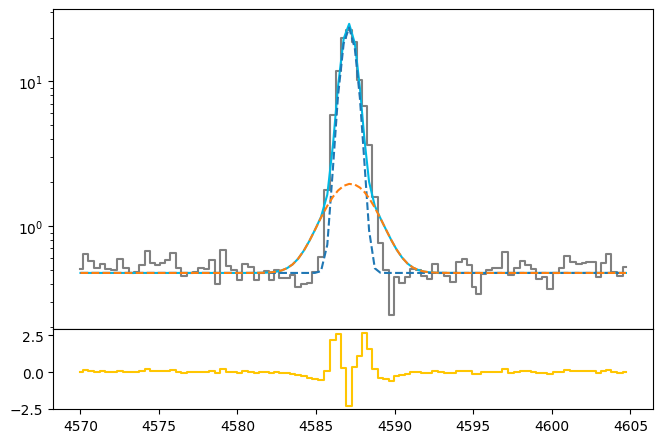

In [107]:
hg_nar_flux = out2_hg.params['Hg_nar'].value
hg_nar_std = out2_hg.params['Hg_nar'].stderr

hg_brd_flux = out2_hg.params['Hg_brd'].value
hg_brd_std = out2_hg.params['Hg_brd'].stderr

z_hg = out2_hg.params['z_nar'].value
z_hg_std = out2_hg.params['z_nar'].stderr

bkg_hg = out2_hg.params['bkg'].value
bkg_hg_std = out2_hg.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hgamma.wavelength, hgamma.flux, color='gray', label='Data', where='mid')

hg_nar = gaussian(hgamma.wavelength, hg_nar_flux, wave_cat['Hg'],           z_hg, upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, hg_brd_flux, wave_cat['Hg'], z_hg * z_ratio, upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

ax.plot(hgamma.wavelength, bkg_hg + hg, color=c[0])
ax.plot(hgamma.wavelength, bkg_hg + hg_nar, ls='--')
ax.plot(hgamma.wavelength, bkg_hg + hg_brd, ls='--')
ax.set_yscale('log')
ax1.step(hgamma.wavelength, hgamma.flux - bkg_hg - hg, color=c[3], where='mid')

In [108]:
# EW
EW_Hg_nar = ufloat(hg_nar_flux, hg_nar_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg_brd = ufloat(hg_brd_flux, hg_brd_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg = (ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / ufloat(bkg_hg, bkg_hg_std)

# H$\delta$

In [109]:
sigma_arc_hd = (m * wave_cat['Hd']*(1 + z_BN[igal])) + n

sigma_nar_hd = sigma_arc_hd
sigma_brd_hd = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hd**2))

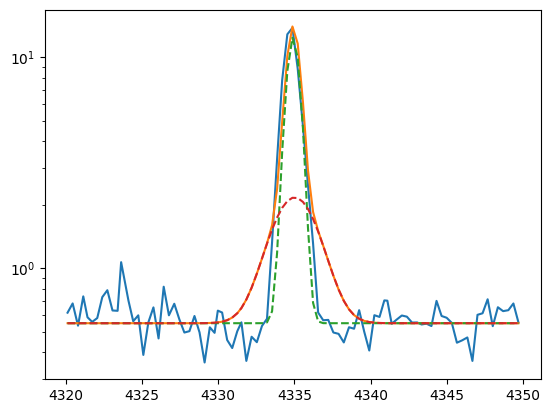

In [110]:
plt.plot(hdelta.wavelength, hdelta.flux)
bkg = 5.5e-1

hd_nar = gaussian(hdelta.wavelength, 1.3e1, wave_cat['Hd'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hd))
hd_brd = gaussian(hdelta.wavelength, 0.6e1, wave_cat['Hd'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hd))

hd = hd_nar + hd_brd

plt.plot(hdelta.wavelength, hd + bkg)
plt.plot(hdelta.wavelength, hd_nar + bkg, ls='--')
plt.plot(hdelta.wavelength, hd_brd + bkg, ls='--')
plt.yscale('log')

In [111]:
params_hd = Parameters()
params_hd.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hd.add('z_ratio', value=z_ratio, vary=False)
params_hd.add('sigma_nar', value=upy.nominal_values(sigma_nar_hd), vary=False)
params_hd.add('sigma_brd', value=upy.nominal_values(sigma_brd_hd), vary=False)
params_hd.add('Hd_nar', value=1.3e1, min=0.)
params_hd.add('Hd_brd', value=0.6e1, min=0.)
params_hd.add('bkg', value=5.5e-1, min=0.)

def residual_hd(params_hd, x, data, uncertainty):
    
    z_nar = params_hd['z_nar']
    z_brd = params_hd['z_nar'] * params_hd['z_ratio']
    sigma_nar = params_hd['sigma_nar']
    sigma_brd = params_hd['sigma_brd']
    hd_nar_flux = params_hd['Hd_nar']
    hd_brd_flux = params_hd['Hd_brd']
    bkg = params_hd['bkg']
    
    x = hdelta.wavelength
    model = gaussian(x, hd_nar_flux, wave_cat['Hd'], z_nar, sigma_nar) + \
            gaussian(x, hd_brd_flux, wave_cat['Hd'], z_brd, sigma_brd)
    return (model + bkg - hdelta.flux) / hdelta.noise

In [112]:
np.random.seed(1146)
out_hd = minimize(residual_hd, params_hd, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 129.49it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [20.48124677 80.78753394 92.66083384 40.3837567 ]


In [113]:
out_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681697,1.1226e-06,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.43661611,,,0.43661611306953263,-inf,inf,False
sigma_brd,1.48116436,,,1.4811643567985529,-inf,inf,False
Hd_nar,14.6822630,0.15142671,(1.03%),13.0,0.00000000,inf,True
Hd_brd,3.08742793,0.20617291,(6.68%),6.0,0.00000000,inf,True
bkg,0.54173827,0.00931331,(1.72%),0.55,0.00000000,inf,True


In [114]:
np.random.seed(1146)
out2_hd = minimize(residual_hd, out_hd.params, args=(1, 1, 1),
                   method='leastsq')

In [115]:
out2_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05681703,2.3610e-06,(0.00%),0.05681696771150524,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.43661611,0.00000000,(0.00%),0.43661611306953263,-inf,inf,False
sigma_brd,1.48116436,0.00000000,(0.00%),1.4811643567985529,-inf,inf,False
Hd_nar,14.6863752,0.33979255,(2.31%),14.682262980825204,0.00000000,inf,True
Hd_brd,3.08676005,0.44937160,(14.56%),3.0874279317351023,0.00000000,inf,True
bkg,0.54193102,0.02089840,(3.86%),0.5417382711900496,0.00000000,inf,True


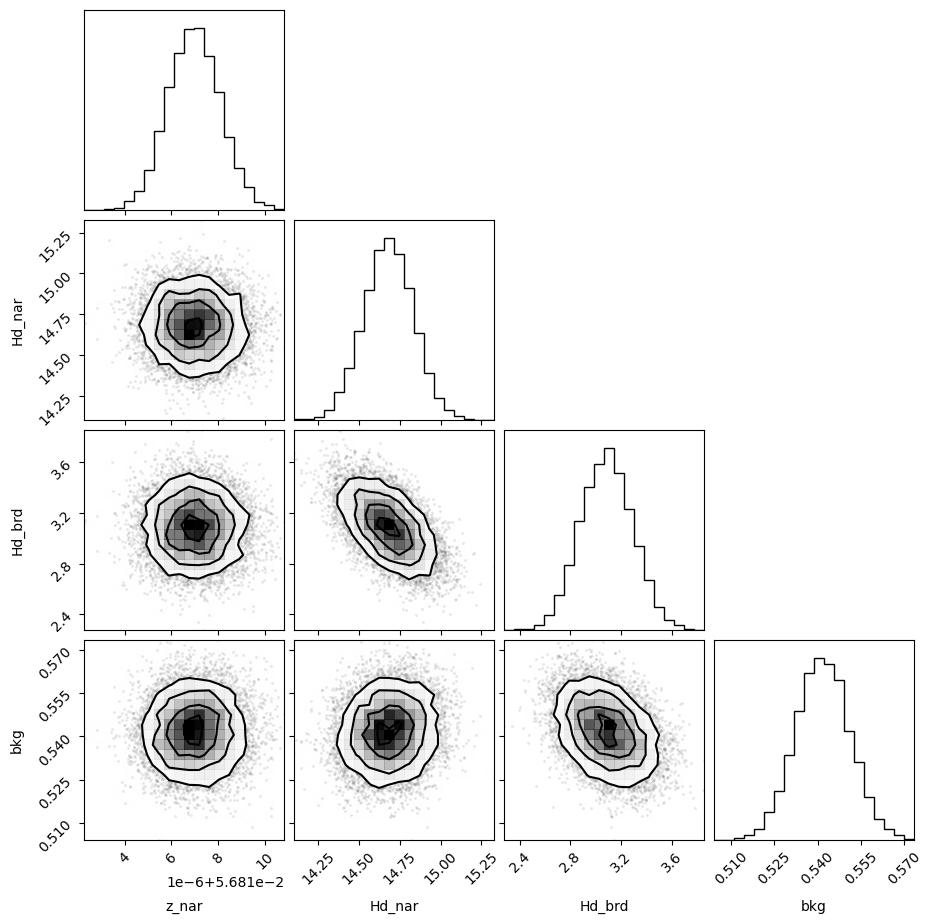

In [116]:
corner.corner(out_hd.flatchain, labels=out_hd.var_names);

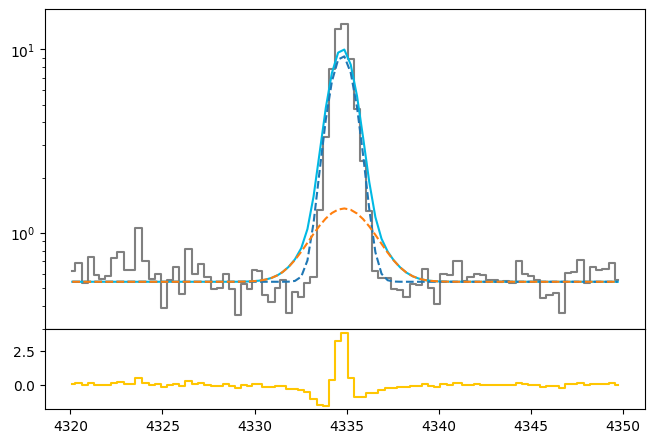

In [117]:
hd_nar_flux = out2_hd.params['Hd_nar'].value
hd_nar_std = out2_hd.params['Hd_nar'].stderr

hd_brd_flux = out2_hd.params['Hd_brd'].value
hd_brd_std = out2_hd.params['Hd_brd'].stderr

z_hd = out2_hd.params['z_nar'].value
z_hd_std = out2_hd.params['z_nar'].stderr

bkg_hd = out2_hd.params['bkg'].value
bkg_hd_std = out2_hd.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hdelta.wavelength, hdelta.flux, color='gray', label='Data', where='mid')

hd_nar = gaussian(hdelta.wavelength, hd_nar_flux, wave_cat['Hd'], z_hd, sigma_nar_oiii_4959)
hd_brd = gaussian(hdelta.wavelength, hd_brd_flux, wave_cat['Hd'], z_hd * z_ratio, sigma_brd_oiii_4959)

hd = hd_nar + hd_brd

ax.plot(hdelta.wavelength, bkg_hd + hd, color=c[0])
ax.plot(hdelta.wavelength, bkg_hd + hd_nar, ls='--')
ax.plot(hdelta.wavelength, bkg_hd + hd_brd, ls='--')
ax.set_yscale('log')
ax1.step(hdelta.wavelength, hdelta.flux - bkg_hd - hd, color=c[3], where='mid')

In [118]:
# EW
EW_Hd_nar = ufloat(hd_nar_flux, hd_nar_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd_brd = ufloat(hd_brd_flux, hd_brd_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd = (ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / ufloat(bkg_hd, bkg_hd_std)

# HeII 4686

In [119]:
sigma_arc_4685 = (m * wave_cat['HeII4685']*(1 + z_BN[igal])) + n

sigma_nar_4685 = sigma_arc_4685
sigma_brd_4685 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4685**2))

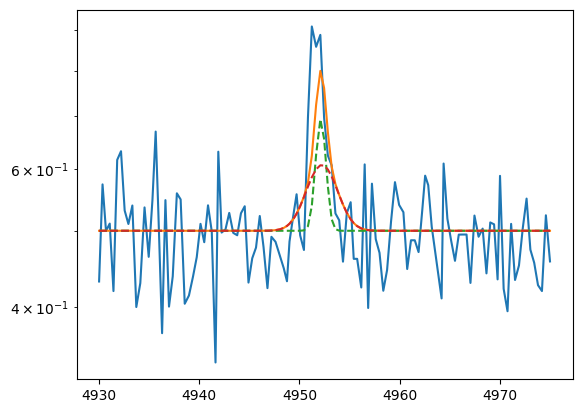

In [120]:
plt.plot(heii_4686.wavelength, heii_4686.flux)
bkg = 5e-1

heii4685_nar = gaussian(heii_4686.wavelength, 2.4e-1, wave_cat['HeII4685'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4685))
heii4685_brd = gaussian(heii_4686.wavelength, 4e-1, wave_cat['HeII4685'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4685))

heii4685 = heii4685_nar + heii4685_brd

plt.plot(heii_4686.wavelength, heii4685 + bkg)
plt.plot(heii_4686.wavelength, heii4685_nar + bkg, ls='--')
plt.plot(heii_4686.wavelength, heii4685_brd + bkg, ls='--')
plt.yscale('log')

In [121]:
params_4685 = Parameters()
params_4685.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_4685.add('z_ratio', value=z_ratio, vary=False)
params_4685.add('sigma_heii4685_nar', value=upy.nominal_values(sigma_nar_4685), vary=False)
params_4685.add('sigma_heii4685_brd', value=upy.nominal_values(sigma_brd_4685), vary=False)
params_4685.add('Heii4685_nar', value=0., vary=False)
params_4685.add('Heii4685_brd', value=4.0e-1, min=0.)
params_4685.add('bkg', value=5e-1, min=0.)

def residual_heii4685(params_4685, x, data, uncertainty):
    
    z_nar = params_4685['z_nar']
    z_brd = params_4685['z_nar'] * params_4685['z_ratio']
    sigma_heii4685_nar = params_4685['sigma_heii4685_nar']
    sigma_heii4685_brd = params_4685['sigma_heii4685_brd']
    heii4685_nar_flux = params_4685['Heii4685_nar']
    heii4685_brd_flux = params_4685['Heii4685_brd']
    bkg = params_4685['bkg']
    
    x = heii_4686.wavelength
    model = gaussian(x, heii4685_nar_flux, wave_cat['HeII4685'], z_nar, sigma_heii4685_nar) + \
            gaussian(x, heii4685_brd_flux, wave_cat['HeII4685'], z_brd, sigma_heii4685_brd)
    return (model + bkg - heii_4686.flux) / heii_4686.noise

In [122]:
np.random.seed(1146)
out_heii4685 = minimize(residual_heii4685, params_4685, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 128.70it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [30.98159863 70.23923152 43.59637796]


In [123]:
out_heii4685.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05676711,2.9769e-05,(0.05%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_heii4685_nar,0.49301010,,,0.493010104721,-inf,inf,False
sigma_heii4685_brd,1.49875721,,,1.4987572134990828,-inf,inf,False
Heii4685_nar,0.00000000,,,0.0,-inf,inf,False
Heii4685_brd,0.98176343,0.08558589,(8.72%),0.4,0.00000000,inf,True
bkg,0.48290183,0.00529462,(1.10%),0.5,0.00000000,inf,True


In [124]:
np.random.seed(1146)
out2_heii4685 = minimize(residual_heii4685, out_heii4685.params, args=(1, 1, 1),
                   method='leastsq')

In [125]:
out2_heii4685.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05676785,4.3236e-05,(0.08%),0.05676710956932385,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_heii4685_nar,0.49301010,0.00000000,(0.00%),0.493010104721,-inf,inf,False
sigma_heii4685_brd,1.49875721,0.00000000,(0.00%),1.4987572134990828,-inf,inf,False
Heii4685_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Heii4685_brd,0.98311711,0.10208602,(10.38%),0.9817634302884815,0.00000000,inf,True
bkg,0.48287069,0.00631427,(1.31%),0.4829018264038495,0.00000000,inf,True


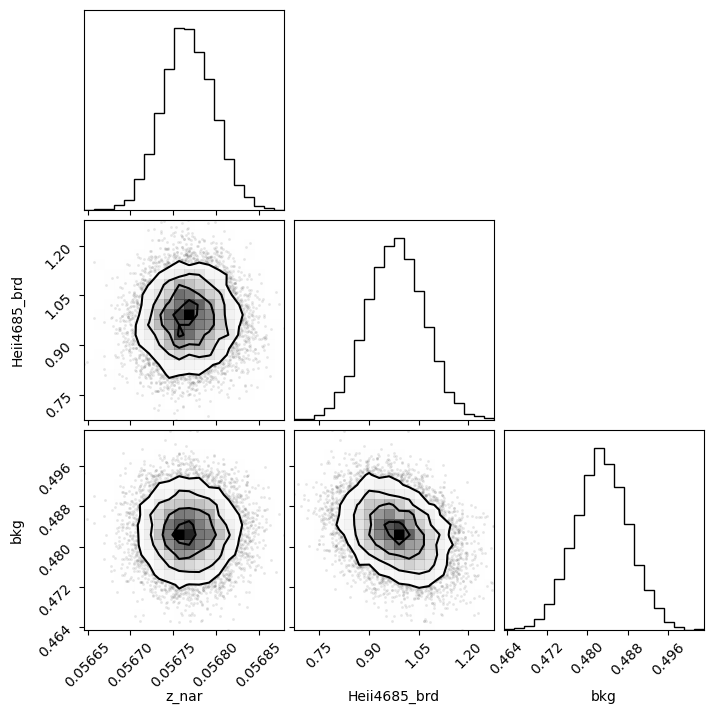

In [126]:
corner.corner(out_heii4685.flatchain, labels=out_heii4685.var_names);

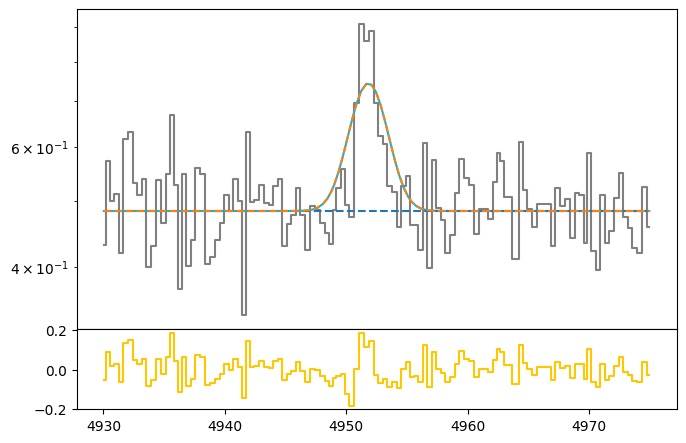

In [127]:
heiia_nar_flux = out2_heii4685.params['Heii4685_nar'].value
heiia_nar_std = out2_heii4685.params['Heii4685_nar'].stderr

heiia_brd_flux = out2_heii4685.params['Heii4685_brd'].value
heiia_brd_std = out2_heii4685.params['Heii4685_brd'].stderr

z_heiia = out2_heii4685.params['z_nar'].value
z_heiia_std = out2_heii4685.params['z_nar'].stderr

bkg_heiia = out2_heii4685.params['bkg'].value
bkg_heiia_std = out2_heii4685.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(heii_4686.wavelength, heii_4686.flux, color='gray', label='Data', where='mid')

heiia_nar = gaussian(heii_4686.wavelength, heiia_nar_flux, wave_cat['HeII4685'], z_heiia, upy.nominal_values(sigma_nar_4685))
heiia_brd = gaussian(heii_4686.wavelength, heiia_brd_flux, wave_cat['HeII4685'], z_heiia * z_ratio, upy.nominal_values(sigma_brd_4685))

heiia = heiia_nar + heiia_brd

ax.plot(heii_4686.wavelength, bkg_heiia + heiia, color=c[0])
ax.plot(heii_4686.wavelength, bkg_heiia + heiia_nar, ls='--')
ax.plot(heii_4686.wavelength, bkg_heiia + heiia_brd, ls='--')
ax.set_yscale('log')
ax1.step(heii_4686.wavelength, heii_4686.flux - bkg_heiia - heiia, color=c[3], where='mid')

In [128]:
# EW
EW_HeII_4686_nar = ufloat(heiia_nar_flux, heiia_nar_std) / ufloat(bkg_heiia, bkg_heiia_std)
EW_HeII_4686_brd = ufloat(heiia_brd_flux, heiia_brd_std) / ufloat(bkg_heiia, bkg_heiia_std)
EW_HeII_4686 = (ufloat(heiia_nar_flux, heiia_nar_std) + ufloat(heiia_brd_flux, heiia_brd_std)) / ufloat(bkg_heiia, bkg_heiia_std)

# [OII]3726 + [OII]3729

In [129]:
sigma_arc_3729 = (m * wave_cat['[OII]3729']*(1 + z_BN[igal])) + n

sigma_nar_3729 = sigma_arc_3729
sigma_brd_3729 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3729**2))

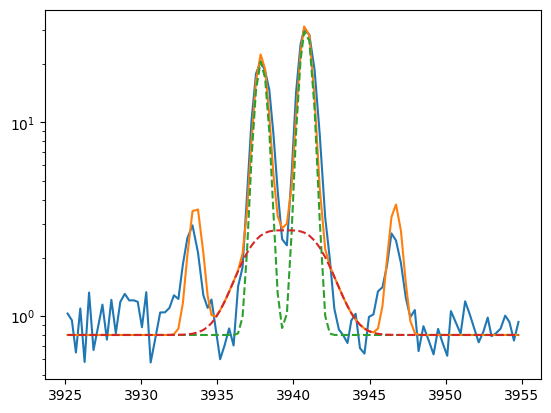

In [130]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 0.3e1, wave_cat['H13'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, 0.3e2, wave_cat['[OII]3729'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, 0.6e1, wave_cat['[OII]3729'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, 0.2e2, wave_cat['[OII]3726'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, 0.6e1, wave_cat['[OII]3726'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, 0.3e1, wave_cat['H14'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

bkg = 0.8

plt.plot(oii_3727.wavelength, bkg + oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, bkg + oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, bkg + oiid_brd + oiic_brd, ls='--')

plt.yscale('log')

In [131]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_3727.add('z_ratio', value=z_ratio, vary=False)
params_oii_3727.add('sigma_nar', value=upy.nominal_values(sigma_nar_3729), vary=False)
params_oii_3727.add('sigma_brd', value=upy.nominal_values(sigma_brd_3729), vary=False)
params_oii_3727.add('H13', value=0.3e1, min=0.)
params_oii_3727.add('Oiic_nar', value=0.3e2, min=0.)
params_oii_3727.add('Oiic_brd', value=0.5e1, min=0.)
params_oii_3727.add('Oiid_nar', value=0.2e2, min=0.)
params_oii_3727.add('Oiid_brd', value=0.5e1, min=0.)
params_oii_3727.add('H14', value=0.3e1, min=0.)
params_oii_3727.add('bkg', value=0.8, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_nar'] * params_oii_3727['z_ratio']
    sigma_nar = params_oii_3727['sigma_nar']
    sigma_brd = params_oii_3727['sigma_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    bkg = params_oii_3727['bkg']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_brd)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_nar)
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model + bkg - oii_3727.flux) / oii_3727.noise

In [132]:
np.random.seed(1146)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:31<00:00, 78.65it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 64.08197157 147.39022545  42.61680617 148.7304901   73.85219418
  60.97578601  76.48472318  67.35667109]


In [133]:
out_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05686052,1.0936e-06,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.40060744,,,0.40060744335649995,-inf,inf,False
sigma_brd,1.47095226,,,1.47095225800539,-inf,inf,False
H13,1.82861167,0.12986441,(7.10%),3.0,0.00000000,inf,True
Oiic_nar,32.0913442,0.37458833,(1.17%),30.0,0.00000000,inf,True
Oiic_brd,8.90502246,0.51343410,(5.77%),5.0,0.00000000,inf,True
Oiid_nar,21.2699226,0.32653827,(1.54%),20.0,0.00000000,inf,True
Oiid_brd,5.94238692,0.45215658,(7.61%),5.0,0.00000000,inf,True
H14,1.87989548,0.12071952,(6.42%),3.0,0.00000000,inf,True


In [134]:
np.random.seed(1146)
out2_oii_3727 = minimize(residual_oii_3727, out_oii_3727.params, args=(1, 1, 1),
                         method='leastsq')

In [135]:
out2_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05686056,3.1729e-06,(0.01%),0.056860519697677095,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.40060744,0.00000000,(0.00%),0.40060744335649995,-inf,inf,False
sigma_brd,1.47095226,0.00000000,(0.00%),1.47095225800539,-inf,inf,False
H13,1.82248118,0.43922438,(24.10%),1.8286116690590126,0.00000000,inf,True
Oiic_nar,32.0904351,1.21499028,(3.79%),32.09134421401859,0.00000000,inf,True
Oiic_brd,8.90054141,1.58926024,(17.86%),8.90502245988787,0.00000000,inf,True
Oiid_nar,21.2750230,1.05216205,(4.95%),21.26992258307027,0.00000000,inf,True
Oiid_brd,5.93855142,1.47455447,(24.83%),5.942386917183782,0.00000000,inf,True
H14,1.87740510,0.40601397,(21.63%),1.8798954815833167,0.00000000,inf,True


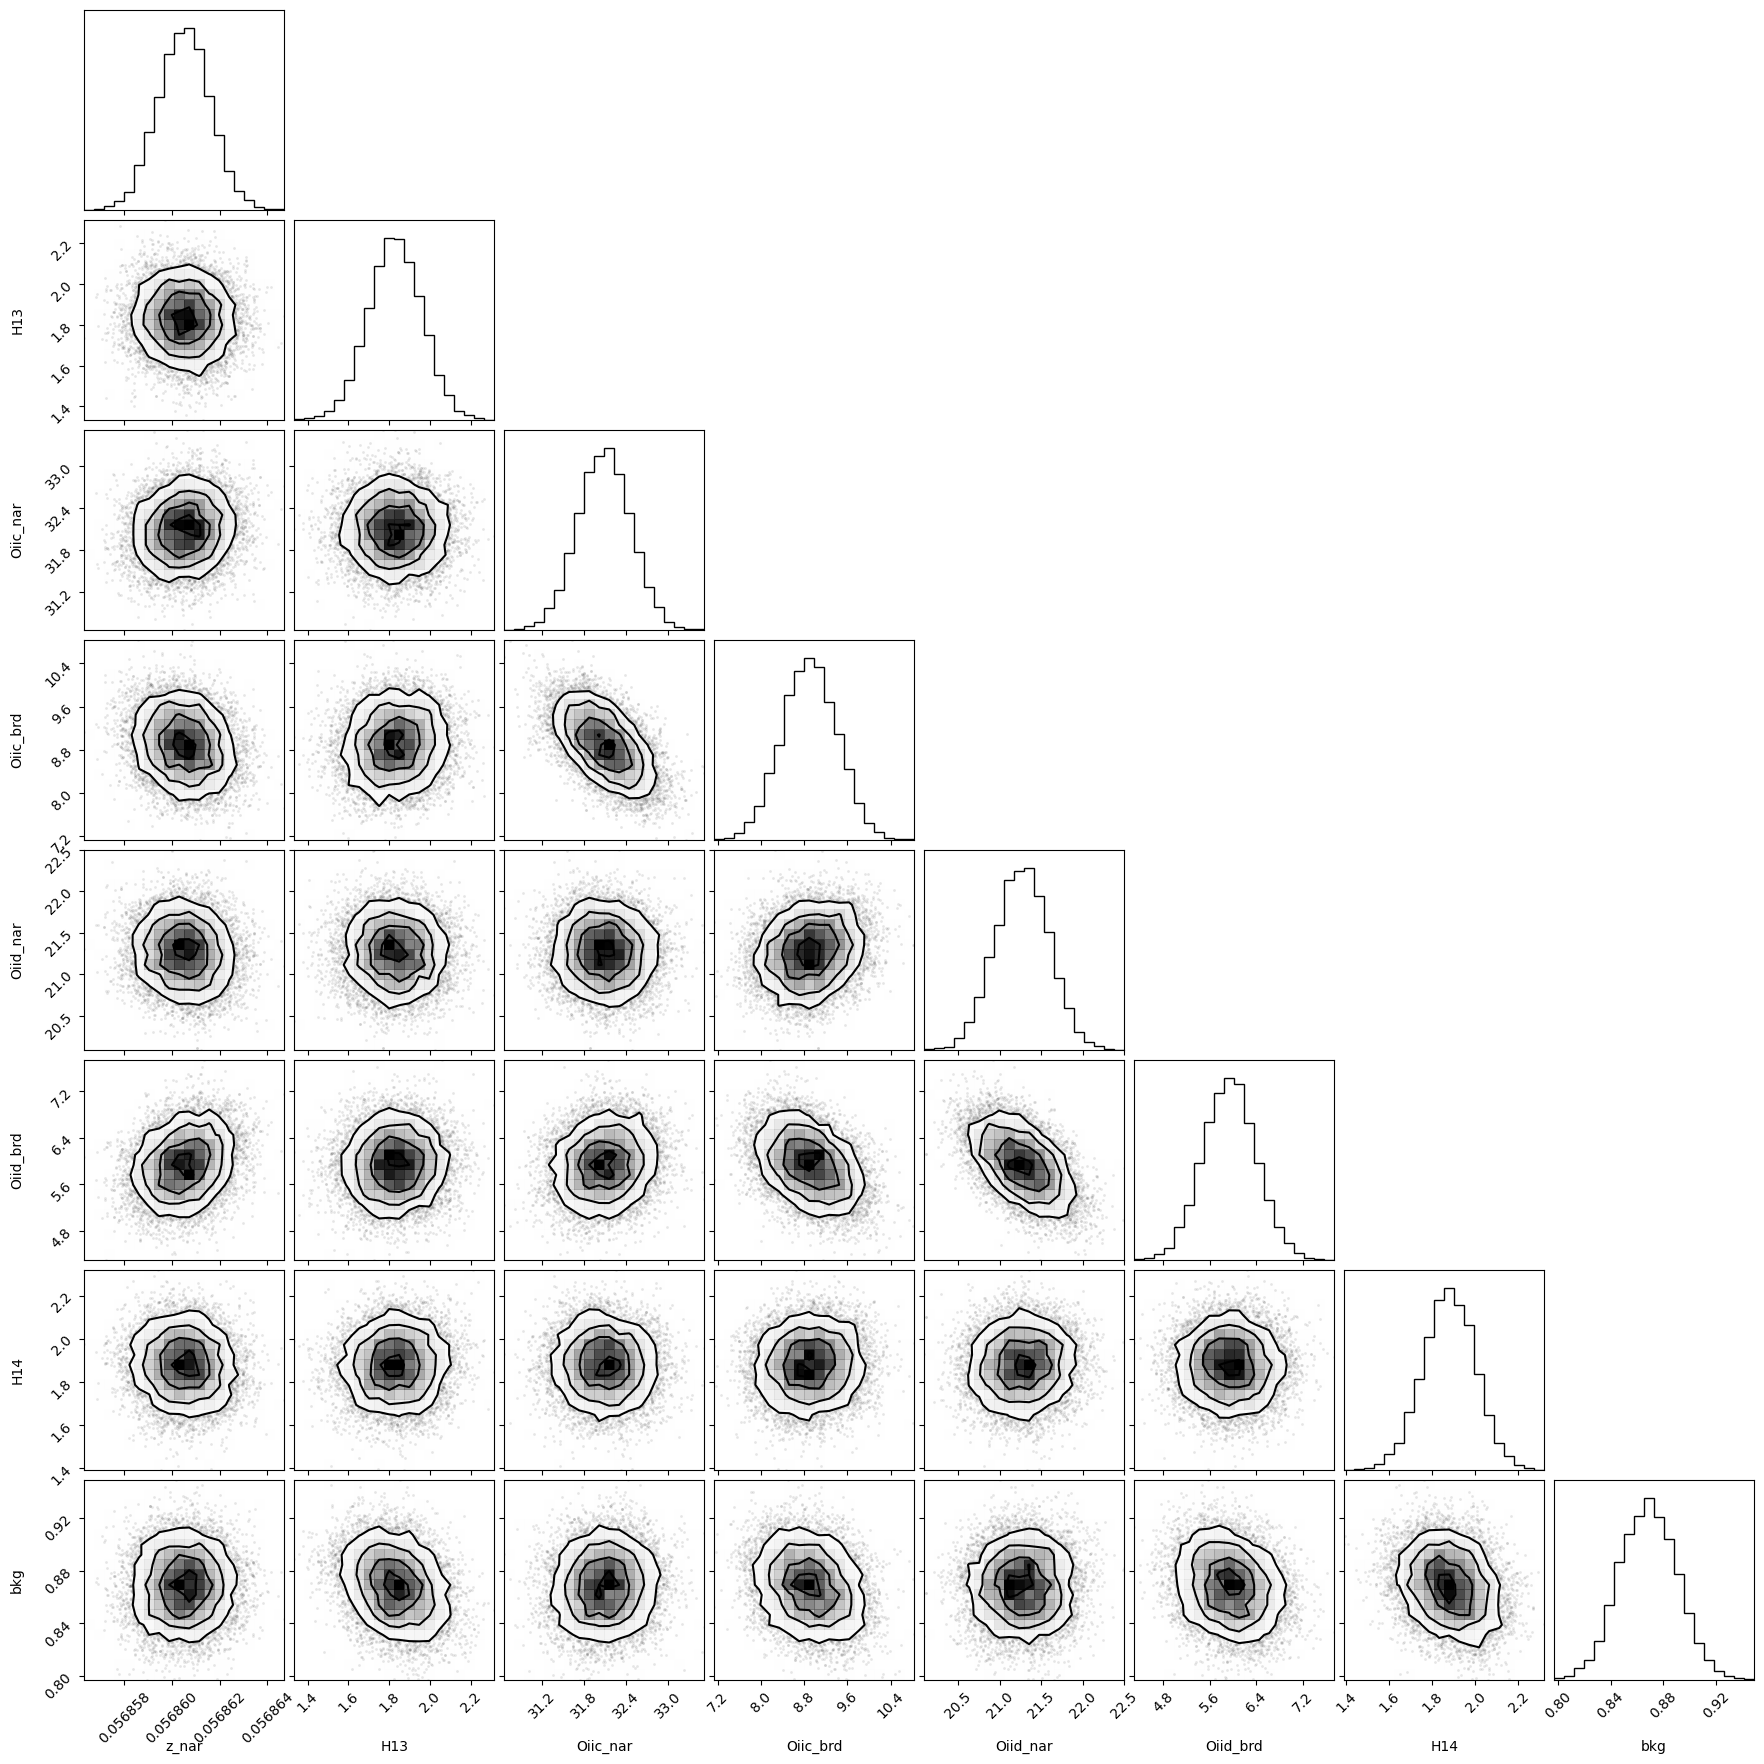

In [136]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);

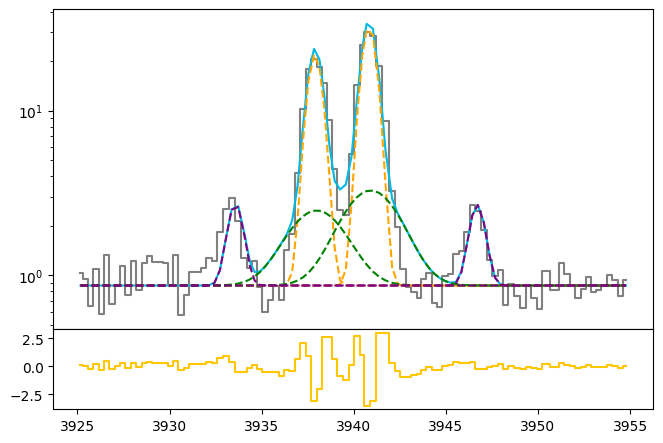

In [137]:
h13_flux = out2_oii_3727.params['H13'].value
h13_std = out2_oii_3727.params['H13'].stderr

oiic_nar_flux = out2_oii_3727.params['Oiic_nar'].value
oiic_nar_std = out2_oii_3727.params['Oiic_nar'].stderr

oiic_brd_flux = out2_oii_3727.params['Oiic_brd'].value
oiic_brd_std = out2_oii_3727.params['Oiic_brd'].stderr

oiid_nar_flux = out2_oii_3727.params['Oiid_nar'].value
oiid_nar_std = out2_oii_3727.params['Oiid_nar'].stderr

oiid_brd_flux = out2_oii_3727.params['Oiid_brd'].value
oiid_brd_std = out2_oii_3727.params['Oiid_brd'].stderr

h14_flux = out2_oii_3727.params['H14'].value
h14_std = out2_oii_3727.params['H14'].stderr

z_oii_3727 = out2_oii_3727.params['z_nar'].value
z_oii_3727_std = out2_oii_3727.params['z_nar'].stderr

bkg_oii_3727 = out2_oii_3727.params['bkg'].value
bkg_oii_3727_std = out2_oii_3727.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h14, ls='--', color='purple')

ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - bkg_oii_3727 - oiic - oiid - h13 - h14,
         color=c[3], where='mid')

In [138]:
# EW
EW_OII_3729_nar = ufloat(oiic_nar_flux, oiic_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729_brd = ufloat(oiic_brd_flux, oiic_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729 = (ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

EW_OII_3726_nar = ufloat(oiid_nar_flux, oiid_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726_brd = ufloat(oiid_brd_flux, oiid_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726 = (ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

# [OI]6300 + [SIII]6312

In [139]:
sigma_arc_6312 = (m * wave_cat['[SIII]6312']*(1 + z_BN[igal])) + n

sigma_nar_6312 = sigma_arc_6312
sigma_brd_6312 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6312**2))

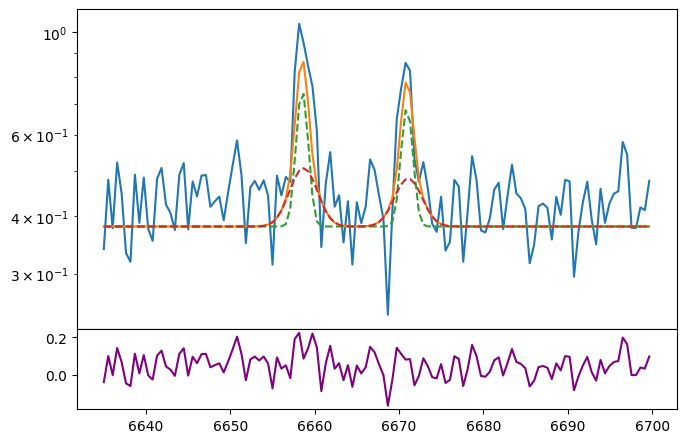

In [140]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oi_siii.wavelength, oi_siii.flux)
bkg = 3.8e-1

oi_nar = gaussian(oi_siii.wavelength, 0.6, wave_cat['[OI]6300'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, 0.5, wave_cat['[OI]6300'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, 0.5, wave_cat['[SIII]6312'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, 0.4, wave_cat['[SIII]6312'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

ax.plot(oi_siii.wavelength, bkg + siiic_nar + siiic_brd + oi_nar + oi_brd)
ax.plot(oi_siii.wavelength, bkg + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg + siiic_brd + oi_brd, ls='--')
ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg - siiic_nar - siiic_brd - oi_nar - oi_brd, color='purple')
ax.set_yscale('log')

In [141]:
params_oi_siii = Parameters()
params_oi_siii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oi_siii.add('z_ratio', value=z_ratio, vary=False)
params_oi_siii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oi_siii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oi_siii.add('Oi_nar', value=0.6, min=0.)
params_oi_siii.add('Oi_brd', value=0.5, min=0.)
params_oi_siii.add('Siiic_nar', value=0.5, min=0.)
params_oi_siii.add('Siiic_brd', value=0.4, min=0.)
params_oi_siii.add('bkg', value=3.8e-1, min=0.)


def residual_oi_siii(params_oi_siii, x, data, uncertainty):
    
    z_nar = params_oi_siii['z_nar']
    z_brd = params_oi_siii['z_nar'] * params_oi_siii['z_ratio']
    sigma_nar = params_oi_siii['sigma_nar']
    sigma_brd = params_oi_siii['sigma_brd']
    oi_nar = params_oi_siii['Oi_nar']
    oi_brd = params_oi_siii['Oi_brd']
    siiic_nar = params_oi_siii['Siiic_nar']
    siiic_brd = params_oi_siii['Siiic_brd']
    bkg = params_oi_siii['bkg']
    
    x = oi_siii.wavelength
    model_oi = gaussian(x, oi_nar, wave_cat['[OI]6300'], z_nar, sigma_nar) \
             + gaussian(x, oi_brd, wave_cat['[OI]6300'], z_brd, sigma_brd)
    model_siii = gaussian(x, siiic_nar, wave_cat['[SIII]6312'], z_nar, sigma_nar) \
               + gaussian(x, siiic_brd, wave_cat['[SIII]6312'], z_brd, sigma_brd)
    
    return (model_siii + model_oi + bkg - oi_siii.flux) / oi_siii.noise

In [142]:
np.random.seed(1146)
out_oi_siii = minimize(residual_oi_siii, params_oi_siii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 106.23it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [56.18678358 55.47905282 60.59373162 62.69834245 70.18969835 62.58576484]


In [143]:
out_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05684557,9.9750e-06,(0.02%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.65005876,,,0.650058755106,-inf,inf,False
sigma_brd,1.55749498,,,1.5574949780813054,-inf,inf,False
Oi_nar,0.72370082,0.13796080,(19.06%),0.6,0.00000000,inf,True
Oi_brd,0.71407966,0.21143620,(29.61%),0.5,0.00000000,inf,True
Siiic_nar,0.68724981,0.10096147,(14.69%),0.5,0.00000000,inf,True
Siiic_brd,0.15233816,0.13274347,(87.14%),0.4,0.00000000,inf,True
bkg,0.42400537,0.00587851,(1.39%),0.38,0.00000000,inf,True


In [144]:
np.random.seed(1146)
out2_oi_siii = minimize(residual_oi_siii, out_oi_siii.params, args=(1, 1, 1),
                      method='leastsq')

In [145]:
out2_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05684535,1.0387e-05,(0.02%),0.05684556904589405,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.65005876,0.00000000,(0.00%),0.650058755106,-inf,inf,False
sigma_brd,1.55749498,0.00000000,(0.00%),1.5574949780813054,-inf,inf,False
Oi_nar,0.73153523,0.15140364,(20.70%),0.7237008205389905,0.00000000,inf,True
Oi_brd,0.70865757,0.23023950,(32.49%),0.7140796581396033,0.00000000,inf,True
Siiic_nar,0.75907660,0.14644260,(19.29%),0.6872498109340353,0.00000000,inf,True
Siiic_brd,0.03542629,0.22572721,(637.17%),0.15233816220634927,0.00000000,inf,True
bkg,0.42496806,0.00663883,(1.56%),0.4240053731958573,0.00000000,inf,True


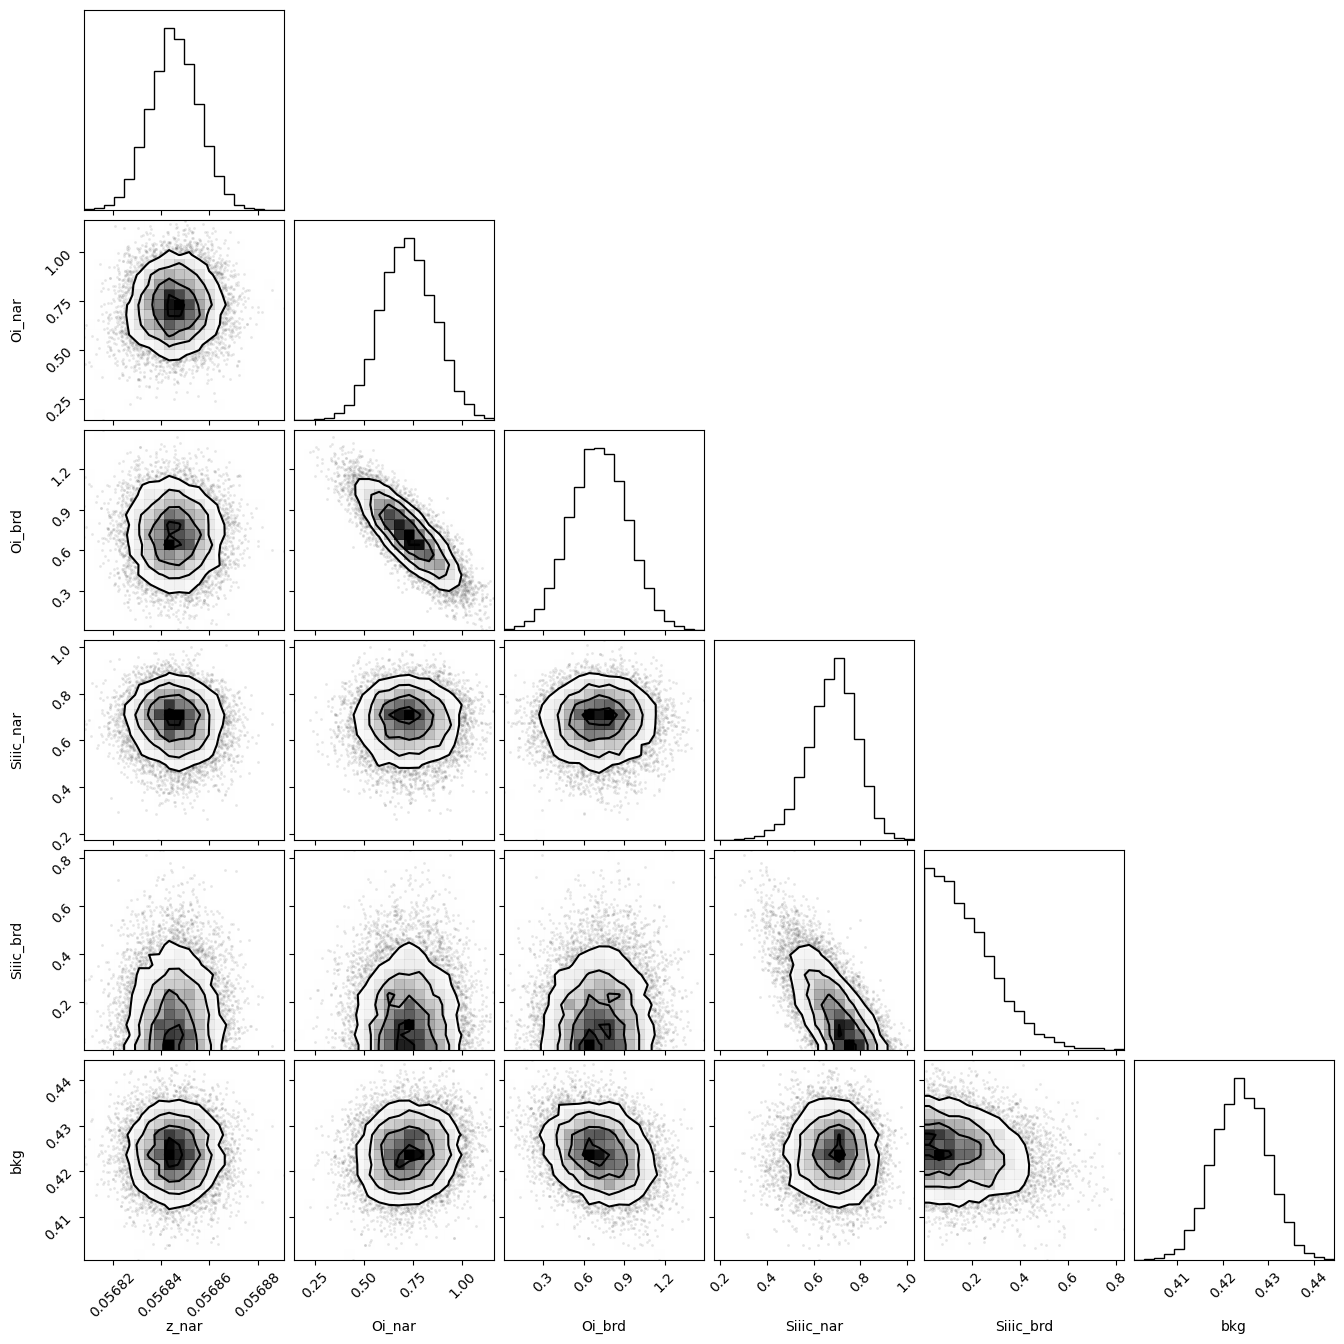

In [146]:
corner.corner(out_oi_siii.flatchain, labels=out_oi_siii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

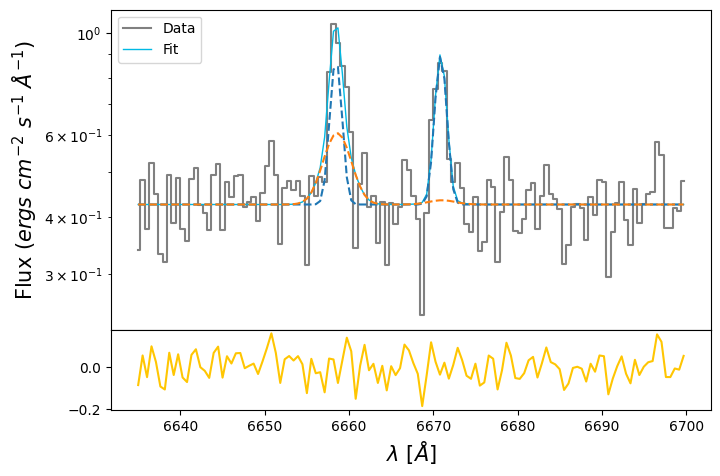

In [147]:
oia_nar_flux = out2_oi_siii.params['Oi_nar'].value
oia_nar_std = out2_oi_siii.params['Oi_nar'].stderr

oia_brd_flux = out2_oi_siii.params['Oi_brd'].value
oia_brd_std = out2_oi_siii.params['Oi_brd'].stderr

siiic_nar_flux = out2_oi_siii.params['Siiic_nar'].value
siiic_nar_std = out2_oi_siii.params['Siiic_nar'].stderr

siiic_brd_flux = out2_oi_siii.params['Siiic_brd'].value
siiic_brd_std = out2_oi_siii.params['Siiic_brd'].stderr

z_oi_siii = out2_oi_siii.params['z_nar'].value
z_oi_siii_std = out2_oi_siii.params['z_nar'].stderr

bkg_oi_siii = out2_oi_siii.params['bkg'].value
bkg_oi_siii_std = out2_oi_siii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oi_siii.wavelength, oi_siii.flux,
            color='gray', label='Data', where='mid')

oia_nar = gaussian(oi_siii.wavelength, oia_nar_flux, wave_cat['[OI]6300'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
oia_brd = gaussian(oi_siii.wavelength, oia_brd_flux, wave_cat['[OI]6300'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, siiic_nar_flux, wave_cat['[SIII]6312'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, siiic_brd_flux, wave_cat['[SIII]6312'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

oia = oia_nar + oia_brd
siiic = siiic_nar + siiic_brd

ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic + oia,
        lw=1, color=c[0], label='Fit')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_nar + oia_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_brd + oia_brd, ls='--')

ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg_oi_siii - siiic - oia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [148]:
# EW
EW_OI_6300_nar = ufloat(oia_nar_flux, oia_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300_brd = ufloat(oia_brd_flux, oia_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300 = (ufloat(oia_nar_flux, oia_nar_std) + ufloat(oia_brd_flux, oia_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

EW_SIII_6312_nar = ufloat(siiic_nar_flux, siiic_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312_brd = ufloat(siiic_brd_flux, siiic_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312 = (ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

# [OIII]5007 + HeI 5015

In [149]:
sigma_arc_5007 = (m * wave_cat['[OIII]5007']*(1 + z_BN[igal])) + n

sigma_nar_5007 = sigma_arc_5007
sigma_brd_5007 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5007**2))

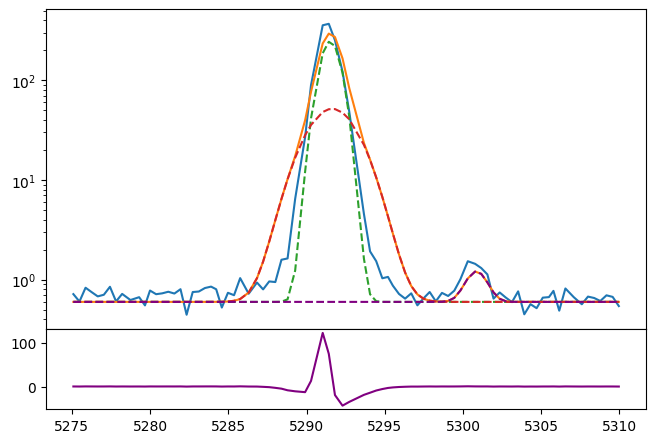

In [150]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)
bkg = 6e-1

oiiia_nar = gaussian(oiii_hei.wavelength, 4e2, wave_cat['[OIII]5007'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
oiiia_brd = gaussian(oiii_hei.wavelength, 2e2, wave_cat['[OIII]5007'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

hei_5015 = gaussian(oiii_hei.wavelength, 1, wave_cat['HeI5015'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))

ax.plot(oiii_hei.wavelength, bkg + oiiia_nar + oiiia_brd + hei_5015)
ax.plot(oiii_hei.wavelength, bkg + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg + hei_5015, ls='--', color='purple')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg - oiiia_nar - oiiia_brd - hei_5015, color='purple')
ax.set_yscale('log')

In [151]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiii_hei.add('z_ratio', value=z_ratio, vary=False)
params_oiii_hei.add('sigma_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oiii_hei.add('sigma_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oiii_hei.add('Hei', value=1, min=0.)
params_oiii_hei.add('Oiiia_nar', value=4.0e2, min=0.)
params_oiii_hei.add('Oiiia_brd', value=2.0e2, min=0.)
params_oiii_hei.add('bkg', value=6e-1, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z_nar = params_oiii_hei['z_nar']
    z_brd = params_oiii_hei['z_nar'] * params_oiii_hei['z_ratio']
    sigma_nar = params_oiii_hei['sigma_nar']
    sigma_brd = params_oiii_hei['sigma_brd']
    oiiia_nar = params_oiii_hei['Oiiia_nar']
    oiiia_brd = params_oiii_hei['Oiiia_brd']
    hei = params_oiii_hei['Hei']
    bkg = params_oiii_hei['bkg']
    
    x = oiii_hei.wavelength
    model_oiii = gaussian(x, oiiia_nar, wave_cat['[OIII]5007'], z_nar, sigma_nar) \
               + gaussian(x, oiiia_brd, wave_cat['[OIII]5007'], z_brd, sigma_brd)
    model_hei = gaussian(x, hei, wave_cat['HeI5015'], z_nar, sigma_nar)
    
    return (model_oiii + model_hei + bkg - oiii_hei.flux) / oiii_hei.noise

In [152]:
np.random.seed(1146)
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 109.42it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 27.9184948   30.1853684  103.49297167 104.05413224 118.26305158]


In [153]:
out_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05682345,3.6232e-07,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.65005876,,,0.650058755106,-inf,inf,False
sigma_brd,1.55749498,,,1.5574949780813054,-inf,inf,False
Hei,1.41648241,0.10633352,(7.51%),1,0.00000000,inf,True
Oiiia_nar,570.558468,1.61158349,(0.28%),400.0,0.00000000,inf,True
Oiiia_brd,17.9928127,0.86663964,(4.82%),200.0,0.00000000,inf,True
bkg,0.68514079,0.01187135,(1.73%),0.6,0.00000000,inf,True


In [154]:
np.random.seed(1146)
out2_oiii_hei = minimize(residual_oiii_hei, out_oiii_hei.params, args=(1, 1, 1),
                      method='leastsq')

In [155]:
out2_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05682343,1.6834e-06,(0.00%),0.0568234488051052,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.65005876,0.00000000,(0.00%),0.650058755106,-inf,inf,False
sigma_brd,1.55749498,0.00000000,(0.00%),1.5574949780813054,-inf,inf,False
Hei,1.41985485,0.48781497,(34.36%),1.4164824092556987,0.00000000,inf,True
Oiiia_nar,570.622455,7.43832133,(1.30%),570.5584681031243,0.00000000,inf,True
Oiiia_brd,17.9270059,4.06642796,(22.68%),17.992812686650048,0.00000000,inf,True
bkg,0.68528957,0.05501455,(8.03%),0.6851407908685423,0.00000000,inf,True


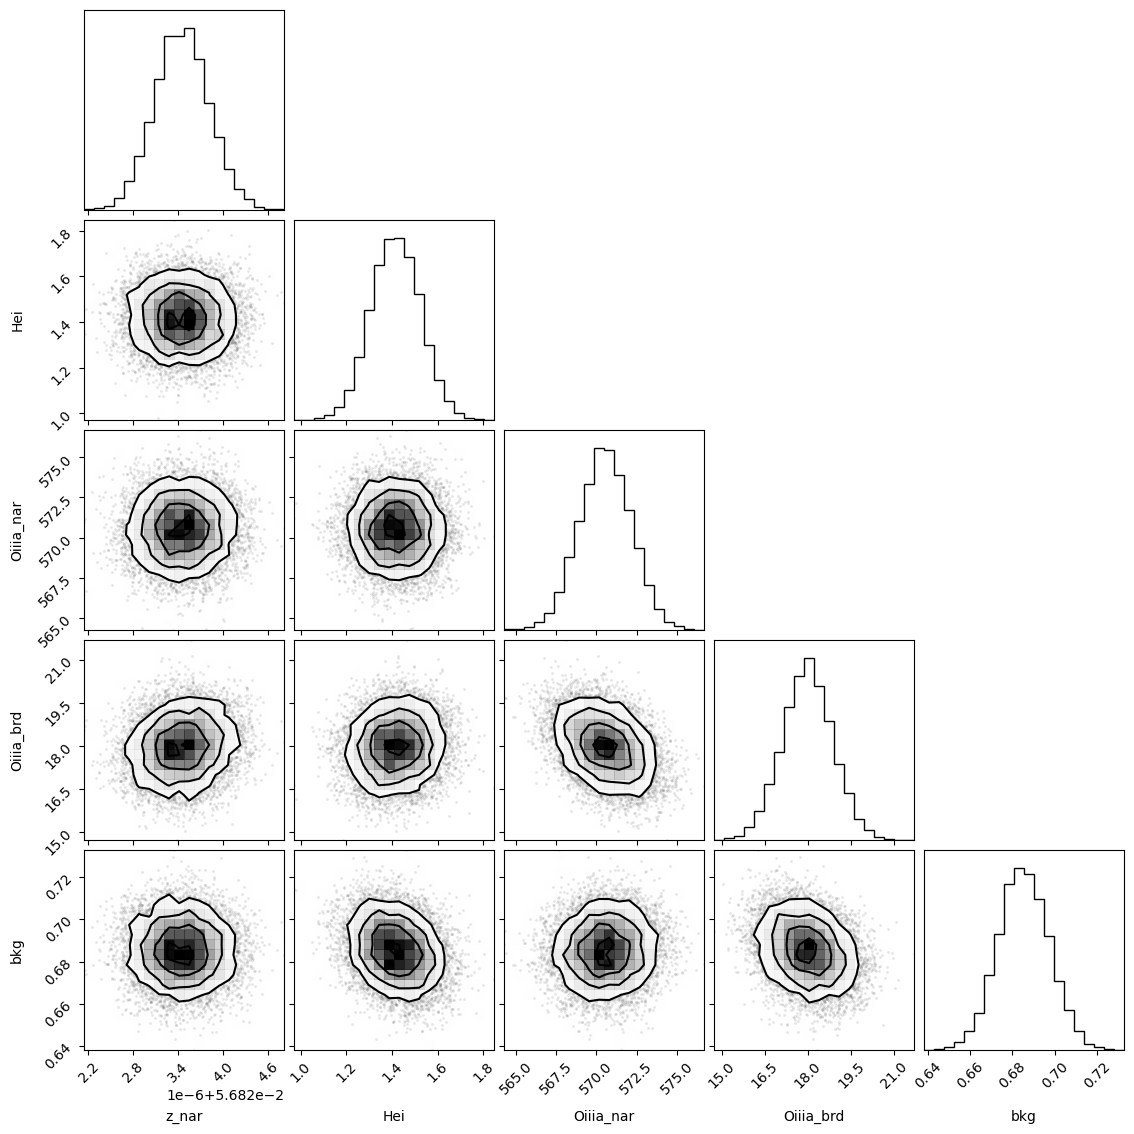

In [156]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

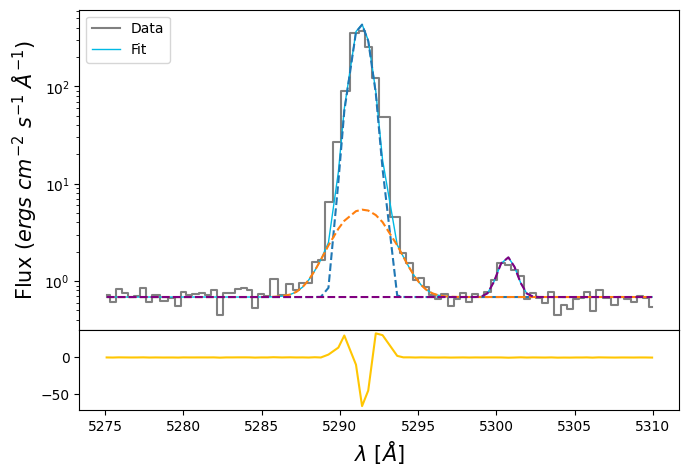

In [157]:
hei_flux = out2_oiii_hei.params['Hei'].value
hei_std = out2_oiii_hei.params['Hei'].stderr

oiiia_nar_flux = out2_oiii_hei.params['Oiiia_nar'].value
oiiia_nar_std = out2_oiii_hei.params['Oiiia_nar'].stderr

oiiia_brd_flux = out2_oiii_hei.params['Oiiia_brd'].value
oiiia_brd_std = out2_oiii_hei.params['Oiiia_brd'].stderr

z_oiii_hei = out2_oiii_hei.params['z_nar'].value
z_oiii_hei_std = out2_oiii_hei.params['z_nar'].stderr

bkg_oiii_hei = out2_oiii_hei.params['bkg'].value
bkg_oiii_hei_std = out2_oiii_hei.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data', where='mid')

hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))

oiiia_nar = gaussian(oiii_hei.wavelength, oiiia_nar_flux, wave_cat['[OIII]5007'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, oiiia_brd_flux, wave_cat['[OIII]5007'], z_oiii_hei * z_ratio, upy.nominal_values(sigma_brd_5007))

oiiia = oiiia_nar + oiiia_brd

ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia + hei,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + hei, ls='--', color='purple')

ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg_oiii_hei - oiiia - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [158]:
# EW
EW_OIII_5007_nar = ufloat(oiiia_nar_flux, oiiia_nar_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007_brd = ufloat(oiiia_brd_flux, oiiia_brd_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007 = (ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)

# [OIII]4363

In [159]:
sigma_arc_4363 = (m * wave_cat['[OIII]4363']*(1 + z_BN[igal])) + n

sigma_nar_4363 = sigma_arc_4363
sigma_brd_4363 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4363**2))

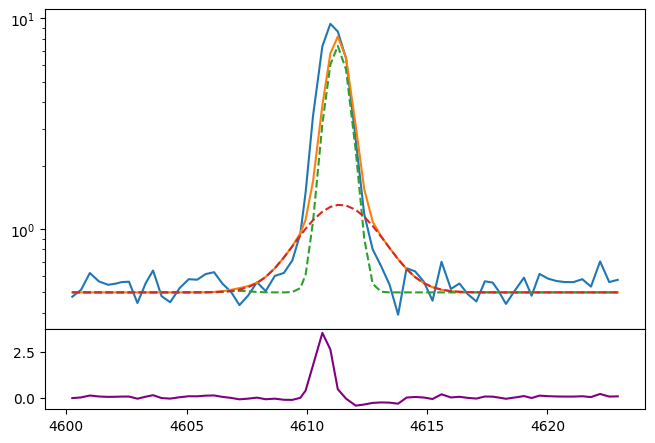

In [160]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4363.wavelength, oiii_4363.flux)
bkg = 5e-1

feii_4360 = gaussian(oiii_4363.wavelength, 0.1e-1, wave_cat['[FeII]4360'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, 8, wave_cat['[OIII]4363'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, 3.0, wave_cat['[OIII]4363'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4363))

ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + oiiic_brd + feii_4360)
ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg + oiiic_brd, ls='--')
ax1.plot(oiii_4363.wavelength, oiii_4363.flux - bkg - oiiic_nar - oiiic_brd - feii_4360, color='purple')
ax.set_yscale('log')

In [161]:
params_oiiic = Parameters()

params_oiiic.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiiic.add('z_ratio', value=z_ratio, vary=False)
params_oiiic.add('sigma_nar', value=upy.nominal_values(sigma_nar_4363), vary=False)
params_oiiic.add('sigma_brd', value=upy.nominal_values(sigma_brd_4363), vary=False)
params_oiiic.add('Feii_4360_nar', value=0.1e-1, min=0.)
params_oiiic.add('Oiiic_nar', value=8.0, min=0.)
params_oiiic.add('Oiiic_brd', value=3.0, min=0.)
params_oiiic.add('bkg', value=5e-1, min=0.)


def residual_oiiic(params_oiiic, x, data, uncertainty):
    
    z_nar = params_oiiic['z_nar']
    z_brd = params_oiiic['z_nar'] * params_oiiic['z_ratio']
    sigma_nar = params_oiiic['sigma_nar']
    sigma_brd = params_oiiic['sigma_brd']
    feii_4360_flux = params_oiiic['Feii_4360_nar']
    oiiic_nar_flux = params_oiiic['Oiiic_nar']
    oiiic_brd_flux = params_oiiic['Oiiic_brd']
    bkg = params_oiiic['bkg']
    
    x = oiii_4363.wavelength
    model = gaussian(x, feii_4360_flux, wave_cat['[FeII]4360'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_nar_flux, wave_cat['[OIII]4363'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_brd_flux, wave_cat['[OIII]4363'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4363.flux) / oiii_4363.noise

In [162]:
np.random.seed(1146)
out_oiiic = minimize(residual_oiiic, params_oiiic, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 123.77it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [26.24531733 59.18469396 82.04640874 87.11318767 58.6194163 ]


In [163]:
out_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05680939,1.6583e-06,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.46186776,,,0.4618677634058999,-inf,inf,False
sigma_brd,1.48880356,,,1.4888035641185482,-inf,inf,False
Feii_4360_nar,0.01605271,0.01743125,(108.59%),0.01,0.00000000,inf,True
Oiiic_nar,10.3890544,0.13170806,(1.27%),8.0,0.00000000,inf,True
Oiiic_brd,2.41772344,0.17435409,(7.21%),3.0,0.00000000,inf,True
bkg,0.52548193,0.00924533,(1.76%),0.5,0.00000000,inf,True


In [164]:
np.random.seed(1146)
out2_oiiic = minimize(residual_oiiic, out_oiiic.params, args=(1, 1, 1),
                      method='leastsq')

In [165]:
out2_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05680944,2.9495e-06,(0.01%),0.056809385279805946,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.46186776,0.00000000,(0.00%),0.4618677634058999,-inf,inf,False
sigma_brd,1.48880356,0.00000000,(0.00%),1.4888035641185482,-inf,inf,False
Feii_4360_nar,8.6695e-10,0.09818140,(11324890852.87%),0.01605271228957201,0.00000000,inf,True
Oiiic_nar,10.3881576,0.25792173,(2.48%),10.389054362551374,0.00000000,inf,True
Oiiic_brd,2.42029186,0.33986683,(14.04%),2.4177234439283035,0.00000000,inf,True
bkg,0.52624209,0.01869157,(3.55%),0.5254819337016805,0.00000000,inf,True


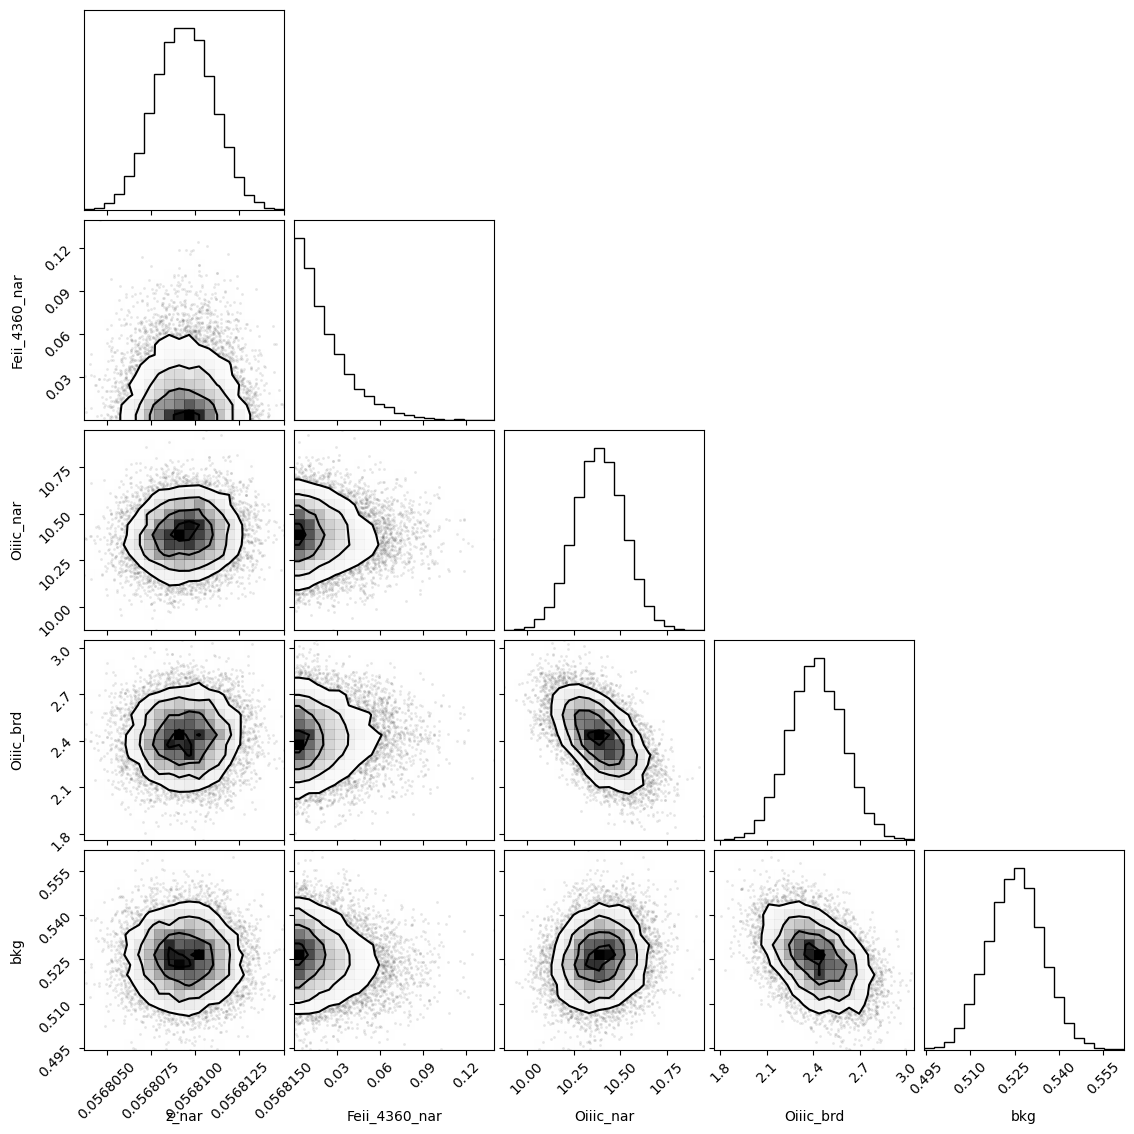

In [166]:
corner.corner(out_oiiic.flatchain, labels=out_oiiic.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

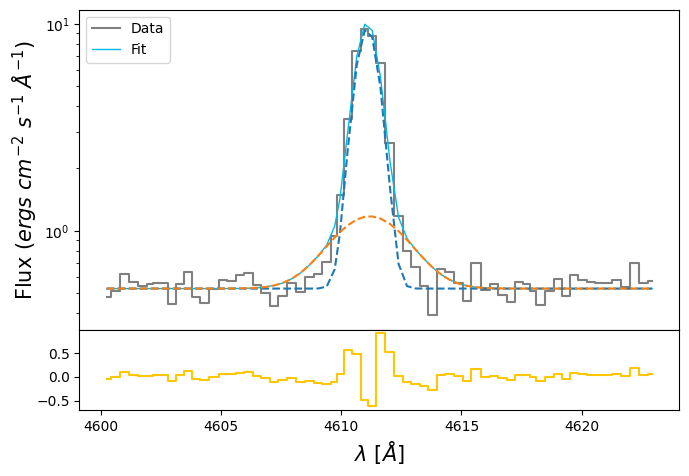

In [167]:
oiiic_nar_flux = out2_oiiic.params['Oiiic_nar'].value
oiiic_nar_std = out2_oiiic.params['Oiiic_nar'].stderr

oiiic_brd_flux = out2_oiiic.params['Oiiic_brd'].value
oiiic_brd_std = out2_oiiic.params['Oiiic_brd'].stderr

feii_4360_flux = out2_oiiic.params['Feii_4360_nar'].value
feii_4360_std = out2_oiiic.params['Feii_4360_nar'].stderr

z_oiii = out2_oiiic.params['z_nar'].value
z_oiii_std = out2_oiiic.params['z_nar'].stderr

bkg_oiiic = out2_oiiic.params['bkg'].value
bkg_oiiic_std = out2_oiiic.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4363.wavelength, oiii_4363.flux,
            color='gray', label='Data', where='mid')

feii_4360 = gaussian(oiii_4363.wavelength, feii_4360_flux, wave_cat['[FeII]4360'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, oiiic_nar_flux, wave_cat['[OIII]4363'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, oiiic_brd_flux, wave_cat['[OIII]4363'], z_oiii * z_ratio, upy.nominal_values(sigma_brd_4363))
oiiic = oiiic_nar + oiiic_brd

ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic + feii_4360, lw=1, color=c[0], label='Fit')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_brd, ls='--')
ax1.step(oiii_4363.wavelength, oiii_4363.flux - bkg_oiiic - oiiic - feii_4360, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [168]:
# EW
EW_OIII_4363_nar = ufloat(oiiic_nar_flux, oiiic_nar_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363_brd = ufloat(oiiic_brd_flux, oiiic_brd_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363 = (ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / ufloat(bkg_oiiic, bkg_oiiic_std)

# [ArIII]7135

In [169]:
sigma_arc_7135 = (m * wave_cat['[ArIII]7135']*(1 + z_BN[igal])) + n

sigma_nar_7135 = sigma_arc_7135
sigma_brd_7135 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7135**2))

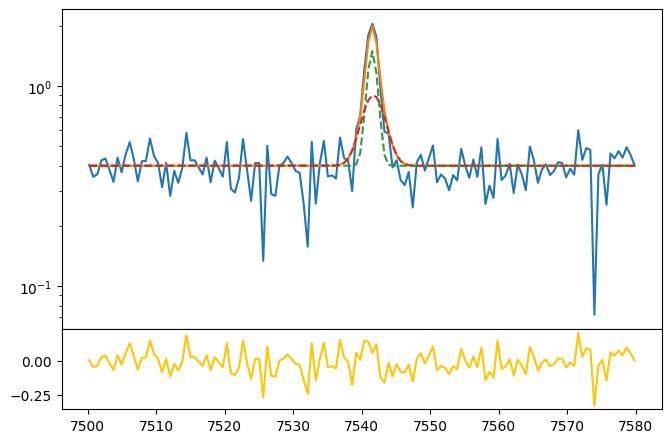

In [170]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ariii_7135.wavelength, ariii_7135.flux)
bkg = 4e-1

ariiia_nar = gaussian(ariii_7135.wavelength, 2, wave_cat['[ArIII]7135'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, 2, wave_cat['[ArIII]7135'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7135))

ax.plot(ariii_7135.wavelength, bkg + ariiia_nar + ariiia_brd)
ax.plot(ariii_7135.wavelength, bkg + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg + ariiia_brd, ls='--')
ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg - ariiia_nar - ariiia_brd, color=c[3])
ax.set_yscale('log')

In [171]:
params_ariii = Parameters()
params_ariii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ariii.add('z_ratio', value=z_ratio, vary=False)
params_ariii.add('sigma_nar', value=upy.nominal_values(sigma_nar_7135), vary=False)
params_ariii.add('sigma_brd', value=upy.nominal_values(sigma_brd_7135), vary=False)
params_ariii.add('Ariiia_nar', value=2, min=0.)
params_ariii.add('Ariiia_brd', value=2, min=0.)
params_ariii.add('bkg', value=0.4, min=0.)


def residual_ariii(params_ariii, x, data, uncertainty):
    
    z_nar = params_ariii['z_nar']
    z_brd = params_ariii['z_nar'] * params_ariii['z_ratio']
    sigma_nar = params_ariii['sigma_nar']
    sigma_brd = params_ariii['sigma_brd']
    ariiia_nar = params_ariii['Ariiia_nar']
    ariiia_brd = params_ariii['Ariiia_brd']
    bkg = params_ariii['bkg']
    
    x = ariii_7135.wavelength
    model_ariii = gaussian(x, ariiia_nar, wave_cat['[ArIII]7135'], z_nar, sigma_nar) \
                + gaussian(x, ariiia_brd, wave_cat['[ArIII]7135'], z_brd, sigma_brd)
    
    return (model_ariii + bkg - ariii_7135.flux) / ariii_7135.noise

In [172]:
np.random.seed(1146)
out_ariii = minimize(residual_ariii, params_ariii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 124.55it/s]


In [173]:
out_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05684448,5.5010e-06,(0.01%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.72960329,,,0.72960329058,-inf,inf,False
sigma_brd,1.59233639,,,1.5923363913707704,-inf,inf,False
Ariiia_nar,2.50071829,0.19638996,(7.85%),2,0.00000000,inf,True
Ariiia_brd,1.53225325,0.26392626,(17.22%),2,0.00000000,inf,True
bkg,0.39116225,0.00587649,(1.50%),0.4,0.00000000,inf,True


In [174]:
np.random.seed(1146)
out2_ariii = minimize(residual_ariii, out_ariii.params, args=(1, 1, 1), method='leastsq')

In [175]:
out2_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05684454,6.1578e-06,(0.01%),0.05684447629640452,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.72960329,0.00000000,(0.00%),0.72960329058,-inf,inf,False
sigma_brd,1.59233639,0.00000000,(0.00%),1.5923363913707704,-inf,inf,False
Ariiia_nar,2.50083665,0.23160845,(9.26%),2.500718291129872,0.00000000,inf,True
Ariiia_brd,1.53976626,0.30969593,(20.11%),1.532253252561464,0.00000000,inf,True
bkg,0.39133890,0.00667298,(1.71%),0.3911622544350132,0.00000000,inf,True


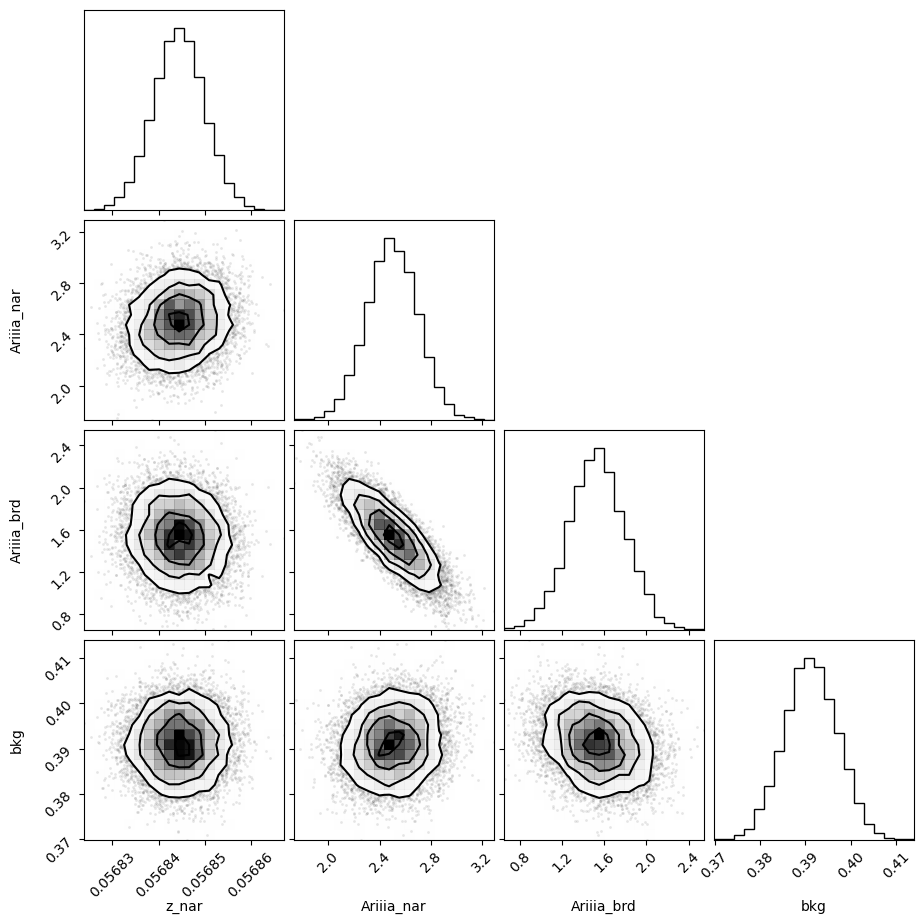

In [176]:
corner.corner(out_ariii.flatchain, labels=out_ariii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

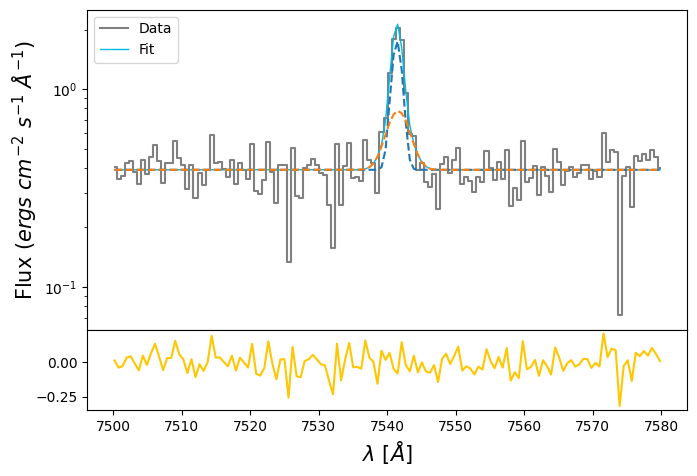

In [177]:
ariiia_nar_flux = out2_ariii.params['Ariiia_nar'].value
ariiia_nar_std = out2_ariii.params['Ariiia_nar'].stderr

ariiia_brd_flux = out2_ariii.params['Ariiia_brd'].value
ariiia_brd_std = out2_ariii.params['Ariiia_brd'].stderr

z_ariii = out2_ariii.params['z_nar'].value
z_ariii_std = out2_ariii.params['z_nar'].stderr

bkg_ariii = out2_ariii.params['bkg'].value
bkg_ariii_std = out2_ariii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ariii_7135.wavelength, ariii_7135.flux,
            color='gray', label='Data', where='mid')

ariiia_nar = gaussian(ariii_7135.wavelength, ariiia_nar_flux, wave_cat['[ArIII]7135'], z_ariii, upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, ariiia_brd_flux, wave_cat['[ArIII]7135'], z_ariii * z_ratio, upy.nominal_values(sigma_brd_7135))

ariiia = ariiia_nar + ariiia_brd

ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia,
        lw=1, color=c[0], label='Fit')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_brd, ls='--')

ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg_ariii - ariiia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [178]:
# EW
EW_ArIII_7135_nar = ufloat(ariiia_nar_flux, ariiia_nar_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135_brd = ufloat(ariiia_brd_flux, ariiia_brd_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135 = (ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / ufloat(bkg_ariii, bkg_ariii_std)

# [ArIV]4740

In [179]:
sigma_arc_4740 = (m * wave_cat['[ArIV]4740']*(1 + z_BN[igal])) + n

sigma_nar_4740 = sigma_arc_4740
sigma_brd_4740 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4740**2))

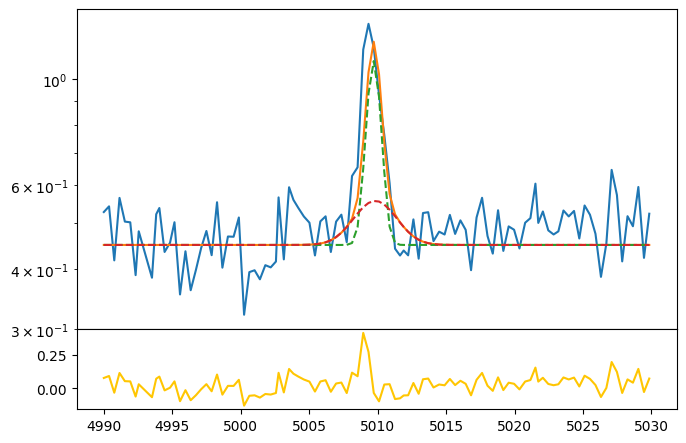

In [180]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ariv_4740.wavelength, ariv_4740.flux)
bkg = 0.45

ariva_nar = gaussian(ariv_4740.wavelength, 0.8, wave_cat['[ArIV]4740'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4740))
ariva_brd = gaussian(ariv_4740.wavelength, 0.4, wave_cat['[ArIV]4740'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4740))

ax.plot(ariv_4740.wavelength, bkg + ariva_nar + ariva_brd)
ax.plot(ariv_4740.wavelength, bkg + ariva_nar, ls='--')
ax.plot(ariv_4740.wavelength, bkg + ariva_brd, ls='--')
ax1.plot(ariv_4740.wavelength, ariv_4740.flux - bkg - ariva_nar - ariva_brd, color=c[3])
ax.set_yscale('log')

In [181]:
params_ariv = Parameters()
params_ariv.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ariv.add('z_ratio', value=z_ratio, vary=False)
params_ariv.add('sigma_nar', value=upy.nominal_values(sigma_nar_4740), vary=False)
params_ariv.add('sigma_brd', value=upy.nominal_values(sigma_brd_4740), vary=False)
params_ariv.add('Ariva_nar', value=0.8, min=0.)
params_ariv.add('Ariva_brd', value=0.4, min=0.)
params_ariv.add('bkg', value=0.45, min=0.)


def residual_ariv(params_ariv, x, data, uncertainty):
    
    z_nar = params_ariv['z_nar']
    z_brd = params_ariv['z_nar'] * params_ariv['z_ratio']
    sigma_nar = params_ariv['sigma_nar']
    sigma_brd = params_ariv['sigma_brd']
    ariva_nar = params_ariv['Ariva_nar']
    ariva_brd = params_ariv['Ariva_brd']
    bkg = params_ariv['bkg']
    
    x = ariv_4740.wavelength
    model_ariv = gaussian(x, ariva_nar, wave_cat['[ArIV]4740'], z_nar, sigma_nar) \
                + gaussian(x, ariva_brd, wave_cat['[ArIV]4740'], z_brd, sigma_brd)
    
    return (model_ariv + bkg - ariv_4740.flux) / ariv_4740.noise

In [182]:
np.random.seed(1146)
out_ariv = minimize(residual_ariv, params_ariv, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 128.90it/s]


In [183]:
out_ariv.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05679744,7.4709e-06,(0.01%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.49827194,,,0.49827193702,-inf,inf,False
sigma_brd,1.50049630,,,1.5004962995223237,-inf,inf,False
Ariva_nar,0.95672314,0.07235917,(7.56%),0.8,0.00000000,inf,True
Ariva_brd,0.39806663,0.12341208,(31.00%),0.4,0.00000000,inf,True
bkg,0.47546495,0.00540606,(1.14%),0.45,0.00000000,inf,True


In [184]:
np.random.seed(1146)
out2_ariv = minimize(residual_ariv, out_ariv.params, args=(1, 1, 1), method='leastsq')

In [185]:
out2_ariv.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05679720,8.7305e-06,(0.02%),0.05679743626954741,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.49827194,0.00000000,(0.00%),0.49827193702,-inf,inf,False
sigma_brd,1.50049630,0.00000000,(0.00%),1.5004962995223237,-inf,inf,False
Ariva_nar,0.95937957,0.09079292,(9.46%),0.956723135513069,0.00000000,inf,True
Ariva_brd,0.39580837,0.15459065,(39.06%),0.3980666301327275,0.00000000,inf,True
bkg,0.47537696,0.00669934,(1.41%),0.47546495293489655,0.00000000,inf,True


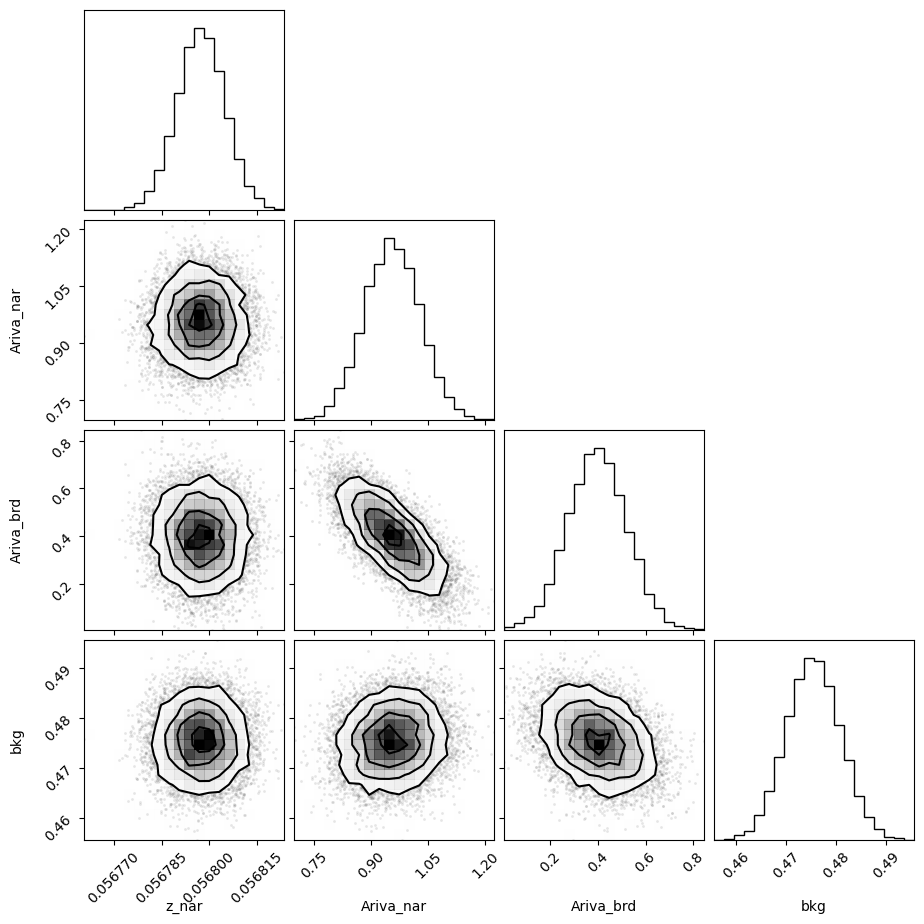

In [186]:
corner.corner(out_ariv.flatchain, labels=out_ariv.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

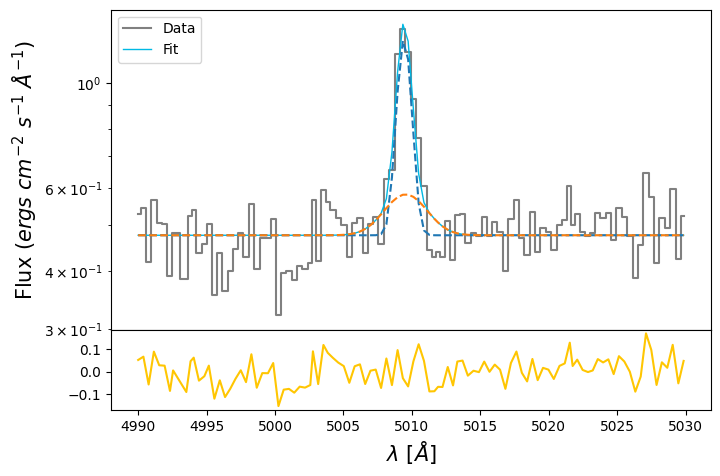

In [187]:
ariva_nar_flux = out2_ariv.params['Ariva_nar'].value
ariva_nar_std = out2_ariv.params['Ariva_nar'].stderr

ariva_brd_flux = out2_ariv.params['Ariva_brd'].value
ariva_brd_std = out2_ariv.params['Ariva_brd'].stderr

z_ariv = out2_ariv.params['z_nar'].value
z_ariv_std = out2_ariv.params['z_nar'].stderr

bkg_ariv = out2_ariv.params['bkg'].value
bkg_ariv_std = out2_ariv.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ariv_4740.wavelength, ariv_4740.flux,
            color='gray', label='Data', where='mid')

ariva_nar = gaussian(ariv_4740.wavelength, ariva_nar_flux, wave_cat['[ArIV]4740'], z_ariv, upy.nominal_values(sigma_nar_4740))
ariva_brd = gaussian(ariv_4740.wavelength, ariva_brd_flux, wave_cat['[ArIV]4740'], z_ariv * z_ratio, upy.nominal_values(sigma_brd_4740))

ariva = ariva_nar + ariva_brd

ax.plot(ariv_4740.wavelength, bkg_ariv + ariva,
        lw=1, color=c[0], label='Fit')
ax.plot(ariv_4740.wavelength, bkg_ariv + ariva_nar, ls='--')
ax.plot(ariv_4740.wavelength, bkg_ariv + ariva_brd, ls='--')

ax1.plot(ariv_4740.wavelength, ariv_4740.flux - bkg_ariv - ariva,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [188]:
fl_ariv = ufloat(ariva_nar_flux, ariva_nar_std) + ufloat(ariva_brd_flux, ariva_brd_std)
sn_ariv = fl_ariv.nominal_value / fl_ariv.std_dev
print(sn_ariv)

7.559022340456054


In [189]:
# EW
EW_ArIV_4740_nar = ufloat(ariva_nar_flux, ariva_nar_std) / ufloat(bkg_ariv, bkg_ariv_std)
EW_ArIV_4740_brd = ufloat(ariva_brd_flux, ariva_brd_std) / ufloat(bkg_ariv, bkg_ariv_std)
EW_ArIV_4740 = (ufloat(ariva_nar_flux, ariva_nar_std) + ufloat(ariva_brd_flux, ariva_brd_std)) / ufloat(bkg_ariv, bkg_ariv_std)

# [NeIII]3868

In [190]:
sigma_arc_3868 = (m * wave_cat['[NeIII]3868']*(1 + z_BN[igal])) + n

sigma_nar_3868 = sigma_arc_3868
sigma_brd_3868 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3868**2))

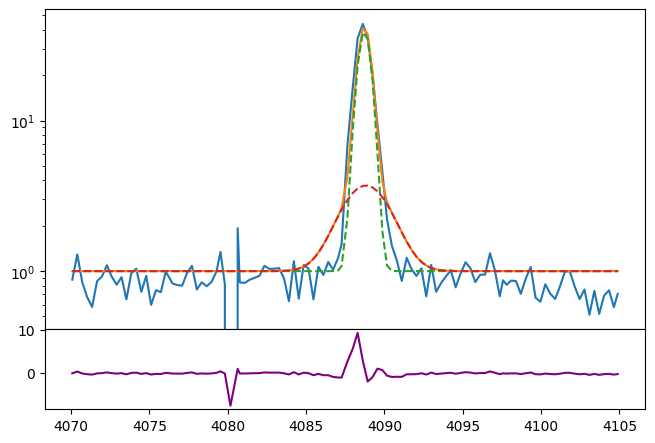

In [191]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(neiii_3868.wavelength, neiii_3868.flux)
bkg = 1

neiiia_nar = gaussian(neiii_3868.wavelength, 40, wave_cat['[NeIII]3868'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, 10, wave_cat['[NeIII]3868'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3868))

ax.plot(neiii_3868.wavelength, bkg + neiiia_nar + neiiia_brd)
ax.plot(neiii_3868.wavelength, bkg + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg + neiiia_brd, ls='--')
ax1.plot(neiii_3868.wavelength, neiii_3868.flux - bkg - neiiia_nar - neiiia_brd, color='purple')
ax.set_yscale('log')

In [192]:
params_neiii_3868 = Parameters()
params_neiii_3868.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_neiii_3868.add('z_ratio', value=z_ratio, vary=False)
params_neiii_3868.add('sigma_nar', value=upy.nominal_values(sigma_nar_3868), vary=False)
params_neiii_3868.add('sigma_brd', value=upy.nominal_values(sigma_brd_3868), vary=False)
params_neiii_3868.add('Neiiia_nar', value=4e1, min=0.)
params_neiii_3868.add('Neiiia_brd', value=1e1, min=0.)
params_neiii_3868.add('bkg', value=1, min=0.)


def residual_neiii_3868(params_neiii_3868, x, data, uncertainty):
    
    z_nar = params_neiii_3868['z_nar']
    z_brd = params_neiii_3868['z_nar'] * params_neiii_3868['z_ratio']
    sigma_nar = params_neiii_3868['sigma_nar']
    sigma_brd = params_neiii_3868['sigma_brd']
    neiiia_nar_flux = params_neiii_3868['Neiiia_nar']
    neiiia_brd_flux = params_neiii_3868['Neiiia_brd']
    bkg = params_neiii_3868['bkg']
    
    x = neiii_3868.wavelength
    model = gaussian(x, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_nar, sigma_nar) + \
            gaussian(x, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_brd, sigma_brd)
    
    return (model + bkg - neiii_3868.flux) / neiii_3868.noise

In [193]:
np.random.seed(1146)
out_neiii_3868 = minimize(residual_neiii_3868, params_neiii_3868, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 128.19it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [23.25333544 71.72083817 62.89543019 73.67001963]


In [194]:
out_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05683445,8.5791e-07,(0.00%),0.056856295683692534,-inf,inf,True
z_ratio,1.00043437,,,1.000434366353069,-inf,inf,False
sigma_nar,0.41412125,,,0.41412124627599994,-inf,inf,False
sigma_brd,1.47469001,,,1.4746900109093135,-inf,inf,False
Neiiia_nar,45.7173553,0.34359279,(0.75%),40.0,0.00000000,inf,True
Neiiia_brd,8.55534730,0.40801724,(4.77%),10.0,0.00000000,inf,True
bkg,0.82403663,0.01486584,(1.80%),1,0.00000000,inf,True


In [195]:
np.random.seed(1146)
out2_neiii_3868 = minimize(residual_neiii_3868, out_neiii_3868.params, args=(1, 1, 1), method='leastsq')

In [196]:
out2_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05683450,1.7763e-06,(0.00%),0.056834445170742334,-inf,inf,True
z_ratio,1.00043437,0.00000000,(0.00%),1.000434366353069,-inf,inf,False
sigma_nar,0.41412125,0.00000000,(0.00%),0.41412124627599994,-inf,inf,False
sigma_brd,1.47469001,0.00000000,(0.00%),1.4746900109093135,-inf,inf,False
Neiiia_nar,45.7252503,0.75777584,(1.66%),45.71735531616025,0.00000000,inf,True
Neiiia_brd,8.53840776,0.90442777,(10.59%),8.555347298164882,0.00000000,inf,True
bkg,0.82424957,0.03291813,(3.99%),0.8240366339872229,0.00000000,inf,True


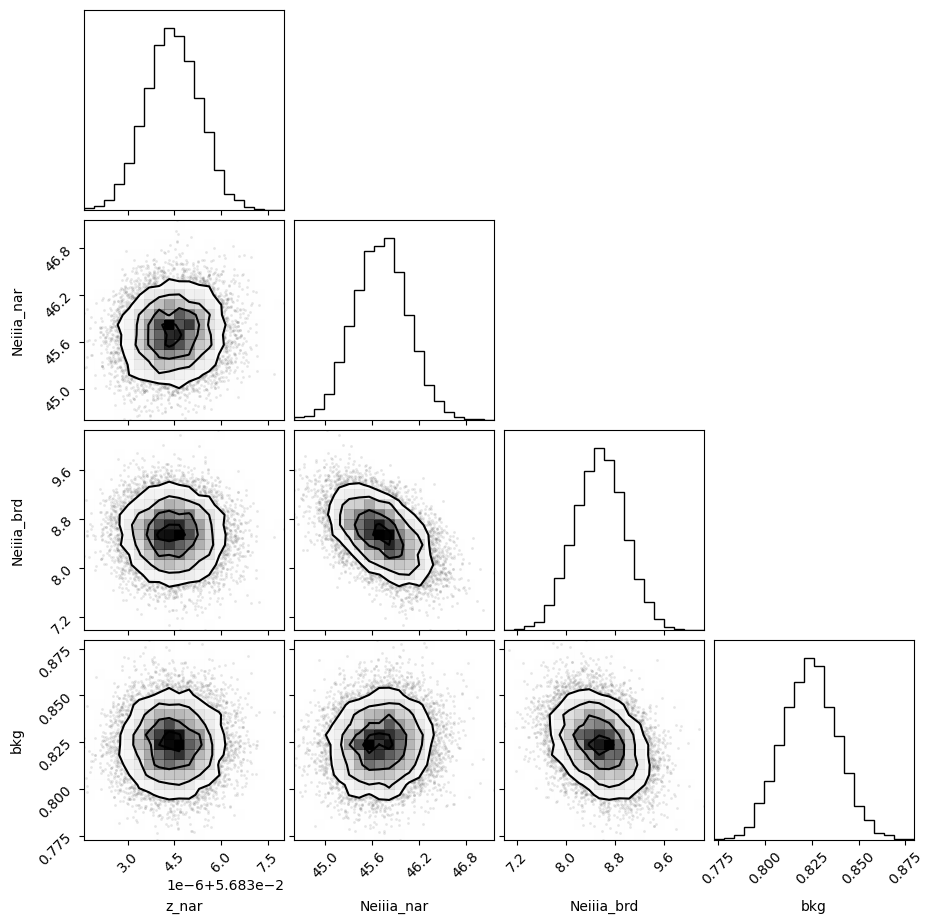

In [197]:
corner.corner(out_neiii_3868.flatchain, labels=out_neiii_3868.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

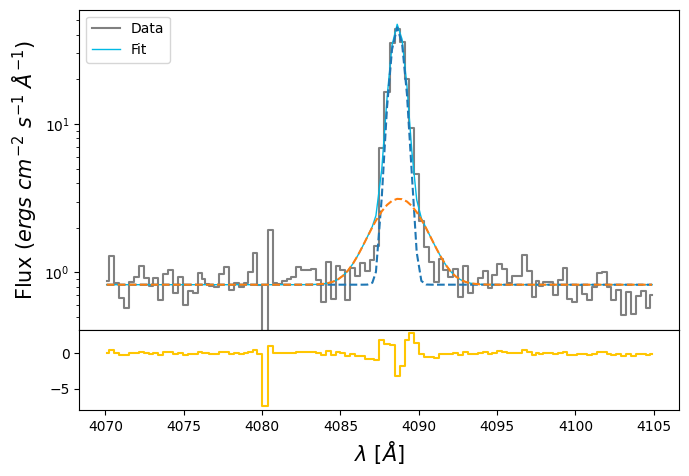

In [198]:
neiiia_nar_flux = out2_neiii_3868.params['Neiiia_nar'].value
neiiia_nar_std = out2_neiii_3868.params['Neiiia_nar'].stderr

neiiia_brd_flux = out2_neiii_3868.params['Neiiia_brd'].value
neiiia_brd_std = out2_neiii_3868.params['Neiiia_brd'].stderr

z_neiii = out2_neiii_3868.params['z_nar'].value
z_neiii_std = out2_neiii_3868.params['z_nar'].stderr

bkg_neiiia = out2_neiii_3868.params['bkg'].value
bkg_neiiia_std = out2_neiii_3868.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(neiii_3868.wavelength, neiii_3868.flux,
            color='gray', label='Data', where='mid')

neiiia_nar = gaussian(neiii_3868.wavelength, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_neiii, upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_neiii * z_ratio, upy.nominal_values(sigma_brd_3868))
neiiia = neiiia_nar + neiiia_brd

ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia, lw=1, color=c[0], label='Fit')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_brd, ls='--')
ax1.step(neiii_3868.wavelength, neiii_3868.flux - bkg_neiiia - neiiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [199]:
# EW
EW_NeIII_3868_nar = ufloat(neiiia_nar_flux, neiiia_nar_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868_brd = ufloat(neiiia_brd_flux, neiiia_brd_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868 = (ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / ufloat(bkg_neiiia, bkg_neiiia_std)

# Balmer decrements

In [200]:
from magE.functions import *
from magE.functions import calzetti2000 as k_cal

flux_ha_bal = ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)
flux_hb_bal = ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)
flux_hg_bal = ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)
flux_hd_bal = ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)

y_balmer = upy.log10([(flux_ha_bal / flux_hb_bal) / 2.86, 
                    (flux_hb_bal / flux_hb_bal) / 1.0,
                    (flux_hg_bal / flux_hb_bal) / 0.464,
                    (flux_hd_bal / flux_hb_bal) / 0.256])

x_balmer = np.array([k_cal(wave_cat['Ha']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hb']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hg']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hd']) - k_cal(wave_cat['Hb'])])

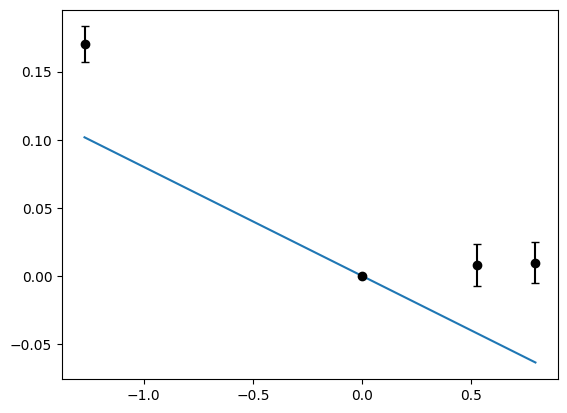

In [201]:
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, x_balmer * (-0.4 * 0.2))

In [202]:
params_balmer = Parameters()
params_balmer.add('slope', value=0.4 * 0.2, min=0.)

def residuals_balmer(params_balmer, x, data, uncertainty):
    
    slope = params_balmer['slope']
    x = x_balmer
    
    model = x * (-slope)
    return (model - upy.nominal_values(y_balmer)) / np.max(upy.std_devs(y_balmer))

np.random.seed(1146)
out_balmer = minimize(residuals_balmer, params_balmer, args=(1, 1, 1),
                      method='leastsq')

In [203]:
out_balmer.params

name,value,standard error,relative error,initial value,min,max,vary
slope,0.08081561,0.04068984,(50.35%),0.08000000000000002,0.00000000,inf,True


Text(0.5, 1.0, 'J1146+0053; $E(B-V) = $ 0.202 $\\pm$ 0.102')

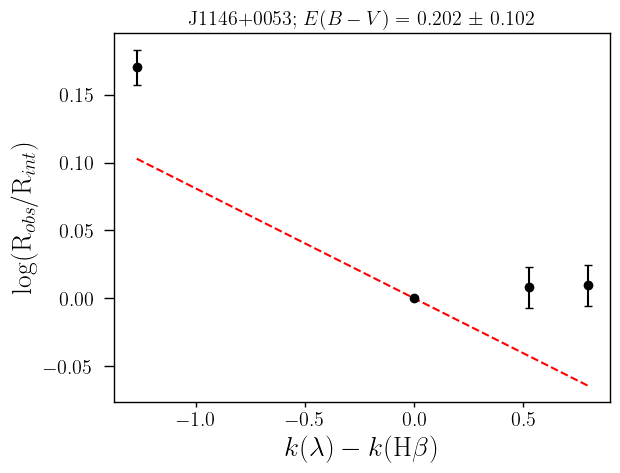

In [204]:
color_excess = ufloat(out_balmer.params['slope'].value, out_balmer.params['slope'].stderr) / 0.4
E_BV = out_balmer.params['slope'].value / 0.4

texPlot('on')
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, - E_BV * 0.4 * x_balmer, ls='--', color='red')
plt.ylabel(r'log(R$_{obs}$/R$_{int}$)')
plt.xlabel(r'$k(\lambda) - k($H$\beta)$')
plt.title(r'J1146+0053; $E(B-V) = $ '+str(round(color_excess.nominal_value, 3))+' $\pm$ '+str(round(color_excess.std_dev, 3)))
#plt.savefig('/home/benjamin/Documents/analogs/results/balmer_decrements/bal_dec_lstsq_J1146.pdf', bbox_inches='tight')

In [205]:
decrement_dict = {'galname': galname,
                 'Ha/Hb': (flux_ha_bal / flux_hb_bal).nominal_value,
                 'Ha/Hb_err': (flux_ha_bal / flux_hb_bal).std_dev,
                 'Hg/Hb': (flux_hg_bal / flux_hb_bal).nominal_value,
                 'Hg/Hb_err': (flux_hg_bal / flux_hb_bal).std_dev,
                 'Hd/Hb': (flux_hd_bal / flux_hb_bal).nominal_value,
                 'Hd/Hb_err': (flux_hd_bal / flux_hb_bal).std_dev,
                 'E_BV': out_balmer.params['slope'].value / 0.4,
                 'E_BV_err': out_balmer.params['slope'].stderr / 0.4
                 }
decrement_dict_pd = pd.DataFrame(data=decrement_dict, index=[0])
#save_catalog(galname, decrement_dict_pd, magePath + '/results/bal_decrements_lstsq.csv')

# Dust correction

In [206]:
oiid_tot_flux = ((ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]3726']))
oiic_tot_flux = ((ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]3729']))

neiiia_tot_flux = ((ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NeIII]3868']))

hd_tot_flux = ((ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hd']))

hg_tot_flux = ((ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hg']))

oiiic_tot_flux = ((ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]4363']))

heid_tot_flux = ((ufloat(heid_nar_flux, heid_nar_std) + ufloat(heid_brd_flux, heid_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['HeI4471']))

feiiia_tot_flux = None

heiia_tot_flux = ((ufloat(heiia_nar_flux, heiia_nar_std) + ufloat(heiia_brd_flux, heiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['HeII4685']))

ariva_tot_flux = ((ufloat(ariva_nar_flux, ariva_nar_std) + ufloat(ariva_brd_flux, ariva_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[ArIV]4740']))

hb_tot_flux = ((ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hb']))

oiiib_tot_flux = ((ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]4959']))

oiiia_tot_flux = ((ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]5007']))

niic_tot_flux = None

heic_tot_flux = ((ufloat(heic_nar_flux, heic_nar_std) + ufloat(heic_brd_flux, heic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['HeI5875']))

oia_tot_flux = ((ufloat(oia_nar_flux, oia_nar_std) + ufloat(oia_brd_flux, oia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OI]6300']))

siiic_tot_flux = ((ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SIII]6312']))

niib_tot_flux = ((ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NII]6548']))

ha_tot_flux = ((ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Ha']))

niia_tot_flux = ((ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NII]6584']))

heib_tot_flux = ((ufloat(heib_nar_flux, heib_nar_std) + ufloat(heib_brd_flux, heib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['HeI6678']))

siib_tot_flux = ((ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SII]6716']))
siia_tot_flux = ((ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SII]6730']))

heia_tot_flux = ((ufloat(heia_nar_flux, heia_nar_std) + ufloat(heia_brd_flux, heia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['HeI7065']))

ariiia_tot_flux = ((ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[ArIII]7135']))

oiib_tot_flux = ((ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]7319']))
oiia_tot_flux = ((ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]7330']))

siiib_tot_flux = None

siiia_tot_flux = None

# Save data

In [206]:
lines_dict = {'galname': galname,
              '[OII]3726': oiid_tot_flux.nominal_value,
              '[OII]3726_err': oiid_tot_flux.std_dev,
              
              '[OII]3729': oiic_tot_flux.nominal_value,
              '[OII]3729_err': oiic_tot_flux.std_dev,
              
              '[NeIII]3868': neiiia_tot_flux.nominal_value,
              '[NeIII]3868_err': neiiia_tot_flux.std_dev,
              
              'Hd': hd_tot_flux.nominal_value,
              'Hd_err': hd_tot_flux.std_dev,
              
              'Hg': hg_tot_flux.nominal_value,
              'Hg_err': hg_tot_flux.std_dev,
              
              '[OIII]4363': oiiic_tot_flux.nominal_value,
              '[OIII]4363_err': oiiic_tot_flux.std_dev,
              
              'HeI4471': heid_tot_flux.nominal_value,
              'HeI4471_err': heid_tot_flux.std_dev,
              
              '[FeIII]4658': None,
              '[FeIII]4658_err': None,
              
              'HeII4686': heiia_tot_flux.nominal_value,
              'HeII4686_err': heiia_tot_flux.std_dev,
              
              '[ArIV]4740': ariva_tot_flux.nominal_value,
              '[ArIV]4740_err': ariva_tot_flux.std_dev,
              
              'Hb': hb_tot_flux.nominal_value,
              'Hb_err': hb_tot_flux.std_dev,
              
              '[OIII]4959': oiiib_tot_flux.nominal_value,
              '[OIII]4959_err': oiiib_tot_flux.std_dev,
              
              '[OIII]5007': oiiia_tot_flux.nominal_value,
              '[OIII]5007_err': oiiia_tot_flux.std_dev,
              
              '[NII]5755': None,
              '[NII]5755_err': None,
              
              'HeI5875': heic_tot_flux.nominal_value,
              'HeI5875_err': heic_tot_flux.std_dev,
              
              '[OI]6300': oia_tot_flux.nominal_value,
              '[OI]6300_err': oia_tot_flux.std_dev,
              
              '[SIII]6312': siiic_tot_flux.nominal_value,
              '[SIII]6312_err': siiic_tot_flux.std_dev,
              
              '[NII]6548': niib_tot_flux.nominal_value,
              '[NII]6548_err': niib_tot_flux.std_dev,
              
              'Ha': ha_tot_flux.nominal_value,
              'Ha_err': ha_tot_flux.std_dev,
              
              '[NII]6584': niia_tot_flux.nominal_value,
              '[NII]6584_err': niia_tot_flux.std_dev,
              
              'HeI6678': heib_tot_flux.nominal_value,
              'HeI6678_err': heib_tot_flux.std_dev,
              
              '[SII]6716': siib_tot_flux.nominal_value,
              '[SII]6716_err': siib_tot_flux.std_dev,
              
              '[SII]6730': siia_tot_flux.nominal_value,
              '[SII]6730_err': siia_tot_flux.std_dev,
              
              'HeI7065': heia_tot_flux.nominal_value,
              'HeI7065_err': heia_tot_flux.std_dev,
              
              '[ArIII]7135': ariiia_tot_flux.nominal_value,
              '[ArIII]7135_err': ariiia_tot_flux.std_dev,
              
              '[OII]7319': oiib_tot_flux.nominal_value,
              '[OII]7319_err': oiib_tot_flux.std_dev,
              
              '[OII]7330': oiia_tot_flux.nominal_value,
              '[OII]7330_err': oiia_tot_flux.std_dev,
              
              '[SIII]9069': None,
              '[SIII]9069_err': None,
              
              '[SIII]9532': None,
              '[SIII]9532_err': None
}
lines_dict_pd = pd.DataFrame(data=lines_dict, index=[0])
save_catalog(galname, lines_dict_pd, magePath + '/results/em_lines_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1146, overwriting...
Done.


In [207]:
ew_dict = {'galname': galname,
              '[OII]3726': EW_OII_3726.nominal_value,
              '[OII]3726_err': EW_OII_3726.std_dev,
              
              '[OII]3729': EW_OII_3729.nominal_value,
              '[OII]3729_err': EW_OII_3729.std_dev,
              
              '[NeIII]3868': EW_NeIII_3868.nominal_value,
              '[NeIII]3868_err': EW_NeIII_3868.std_dev,
              
              'Hd': EW_Hd.nominal_value,
              'Hd_err': EW_Hd.std_dev,
              
              'Hg': EW_Hg.nominal_value,
              'Hg_err': EW_Hg.std_dev,
              
              '[OIII]4363': EW_OIII_4363.nominal_value,
              '[OIII]4363_err': EW_OIII_4363.std_dev,
              
              'HeI4471': EW_HeI_4471.nominal_value,
              'HeI4471_err': EW_HeI_4471.std_dev,
              
              '[FeIII]4658': None,
              '[FeIII]4658_err': None,
              
              'HeII4686': EW_HeII_4686.nominal_value,
              'HeII4686_err': EW_HeII_4686.std_dev,
           
              '[ArIV]4740': EW_ArIV_4740.nominal_value,
              '[ArIV]4740_err': EW_ArIV_4740.std_dev,
              
              'Hb': EW_Hb.nominal_value,
              'Hb_err': EW_Hb.std_dev,
              
              '[OIII]4959': EW_OIII_4959.nominal_value,
              '[OIII]4959_err': EW_OIII_4959.std_dev,
              
              '[OIII]5007': EW_OIII_5007.nominal_value,
              '[OIII]5007_err': EW_OIII_5007.std_dev,
              
              '[NII]5755': None,
              '[NII]5755_err': None,
              
              'HeI5875': EW_HeI_5875.nominal_value,
              'HeI5875_err': EW_HeI_5875.std_dev,
              
              '[OI]6300': EW_OI_6300.nominal_value,
              '[OI]6300_err': EW_OI_6300.std_dev,
              
              '[SIII]6312': EW_SIII_6312.nominal_value,
              '[SIII]6312_err': EW_SIII_6312.std_dev,
              
              '[NII]6548': EW_NII_6548.nominal_value,
              '[NII]6548_err': EW_NII_6548.std_dev,
              
              'Ha': EW_Ha.nominal_value,
              'Ha_err': EW_Ha.std_dev,
              
              '[NII]6584': EW_NII_6584.nominal_value,
              '[NII]6584_err': EW_NII_6584.std_dev,
              
              'HeI6678': EW_HeI_6678.nominal_value,
              'HeI6678_err': EW_HeI_6678.std_dev,
              
              '[SII]6716': EW_SII_6716.nominal_value,
              '[SII]6716_err': EW_SII_6716.std_dev,
              
              '[SII]6730': EW_SII_6730.nominal_value,
              '[SII]6730_err': EW_SII_6730.std_dev,
              
              'HeI7065': EW_HeI_7065.nominal_value,
              'HeI7065_err': EW_HeI_7065.std_dev,
              
              '[ArIII]7135': EW_ArIII_7135.nominal_value,
              '[ArIII]7135_err': EW_ArIII_7135.std_dev,
              
              '[OII]7319': EW_OII_7319.nominal_value,
              '[OII]7319_err': EW_OII_7319.std_dev,
              
              '[OII]7330': EW_OII_7330.nominal_value,
              '[OII]7330_err': EW_OII_7330.std_dev,
              
              '[SIII]9069': None,
              '[SIII]9069_err': None,
              
              '[SIII]9532': None,
              '[SIII]9532_err': None
}
ew_dict_pd = pd.DataFrame(data=ew_dict, index=[0])
save_catalog(galname, ew_dict_pd, magePath + '/results/ew_lines_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1146, overwriting...
Done.


# Temperatures and Densities

In [207]:
# High ionization temperature T[OIII]
T_OIII = TO3(oiiia_tot_flux, oiiib_tot_flux, oiiic_tot_flux)
O2plus_H = 10**(double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII) - 12)

In [208]:
T_OIII

1.651272010448639+/-0.06061820778365817

In [209]:
# Density n([SII])
el_density = ne(siia_tot_flux, siib_tot_flux, T_OIII)

In [210]:
el_density

181.6853065358662+/-169.826746993946

In [211]:
# Low ionization temperature T[OII]
IO2_R = 9.36 * (T_OIII**0.44) * O2plus_H * hb_tot_flux
T_OII = TO2(oiia_tot_flux, oiib_tot_flux, oiic_tot_flux, oiid_tot_flux, el_density, IO2_R)

# Garnett
T_OII_G92 = ((0.7 * (T_OIII * 10)) + 0.3) / 10

# This work
T_OII_tw = (slope_o3o2 * T_OIII) + intercept_o3o2

In [212]:
T_OII

0.8645881790360423+/-0.13380272912273844

In [214]:
# Intermediate ionization temperature
#T_SIII = TS3(siiia_tot_flux, siiib_tot_flux, siiic_tot_flux)

In [215]:
# PyNeb T[NII]
#import pyneb as pn
#N2 = pn.Atom('N', 2)
#R_N2 = (niia_tot_flux + niib_tot_flux) / niic_tot_flux
#t_NII = N2.getTemDen(np.random.normal(loc=R_N2.nominal_value, scale=R_N2.std_dev, size=(1000)),
#                         den=el_density.nominal_value, to_eval = "(L(6584) + L(6548)) / L(5755)") / 10000
#T_NII = ufloat(np.mean(t_NII), np.std(t_NII))

In [216]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.nominal_value,
               'tOIII_err': T_OIII.std_dev,
               'tOII': T_OII.nominal_value,
               'tOII_err': T_OII.std_dev,
               'ne': el_density.nominal_value,
               'ne_err': el_density.std_dev,
               'tNII': None,
               'tNII_err': None,
               'tSIII': None,
               'tSIII_err': None,
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_measured_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1146, overwriting...
Done.


In [217]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.nominal_value,
               'tOIII_err': T_OIII.std_dev,
               'tOII': T_OII.nominal_value,
               'tOII_err': T_OII.std_dev,
               'tOII_G92': T_OII_G92.nominal_value,
               'tOII_G92_err': T_OII_G92.std_dev,
               'tOII_tw': T_OII_tw.nominal_value,
               'tOII_tw_err': T_OII_tw.std_dev
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_estimated_lstsq_v2.csv')

Existent catalog (.csv) file.
Existent data for J1146, overwriting...
Done.


# Abundances

In [213]:
# HELIUM

tau_4471 = 0.921 * color_excess * k_cal(wave_cat['HeI4471'])
tau_5875 = 0.921 * color_excess * k_cal(wave_cat['HeI5875'])
tau_6678 = 0.921 * color_excess * k_cal(wave_cat['HeI6678'])
tau_7065 = 0.921 * color_excess * k_cal(wave_cat['HeI7065'])

f_4471 = optical_depth_function(T_OIII, el_density, tau_4471, line='4471')
f_5875 = optical_depth_function(T_OIII, el_density, tau_5875, line='5875')
f_6678 = optical_depth_function(T_OIII, el_density, tau_6678, line='6678')
f_7065 = optical_depth_function(T_OIII, el_density, tau_7065, line='7065')

F4471, F5875, F6678, F7065 = emissivities(T_OIII, el_density)

y_plus_F4471 = yplus(heid_tot_flux, hb_tot_flux, F4471, f_4471)
y_plus_F5875 = yplus(heic_tot_flux, hb_tot_flux, F5875, f_5875)
y_plus_F6678 = yplus(heib_tot_flux, hb_tot_flux, F6678, f_6678)
y_plus_F7065 = yplus(heia_tot_flux, hb_tot_flux, F7065, f_7065)

y_plus = np.mean(np.array([y_plus_F4471, y_plus_F5875,
                           y_plus_F6678, y_plus_F7065]))

In [214]:
y2_plus = y2plus(heiia_tot_flux, hb_tot_flux, T_OIII)
y = y_plus + y2_plus

In [215]:
# OXYGEN MEASURED

log_Oplus_H_tot = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII, el_density)

log_O2plus_H_tot = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)

O2plus_H_tot = 10**(log_O2plus_H_tot - 12)
Oplus_H_tot = 10**(log_Oplus_H_tot - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tot = (O2plus_H_tot + Oplus_H_tot) * ICF_Oxygen
log_OH_tot = upy.log10(O_H_tot) + 12

In [216]:
print('ICF Oxygen = 1 + y++/y+ =', np.mean(ICF_Oxygen))

ICF Oxygen = 1 + y++/y+ = 1.0064+/-0.0013


In [221]:
# OXYGEN GARNETT

log_O2plus_H_G92 = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)
log_Oplus_H_G92 = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII_G92, el_density)

O2plus_H_G92 = 10**(log_O2plus_H_G92 - 12)
Oplus_H_G92 = 10**(log_Oplus_H_G92 - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_G92 = (O2plus_H_G92 + Oplus_H_G92) * ICF_Oxygen
log_OH_G92 = upy.log10(O_H_G92) + 12

In [222]:
# OXYGEN THIS WORK

log_O2plus_H_tw = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)
log_Oplus_H_tw = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII_tw, el_density)

O2plus_H_tw = 10**(log_O2plus_H_tw - 12)
Oplus_H_tw = 10**(log_Oplus_H_tw - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tw = (O2plus_H_tw + Oplus_H_tw) * ICF_Oxygen
log_OH_tw = upy.log10(O_H_tw) + 12

In [223]:
# SULFUR

#log_Splus_H_tot = single_log_S(siia_tot_flux, siib_tot_flux, hb_tot_flux, T_OII)
#log_S2plus_H_tot = double_log_S(siiia_tot_flux, siiib_tot_flux, hb_tot_flux, T_SIII)
#
#S2plus_H_tot = 10**(log_S2plus_H_tot - 12)
#Splus_H_tot = 10**(log_Splus_H_tot - 12)
#
#ICF_Sulfur = ICF_S(O2plus_H_tot, Oplus_H_tot, alpha=3.27)
#
#S_H_tot = (S2plus_H_tot + Splus_H_tot) * ICF_Sulfur
#log_SH_tot = upy.log10(S_H_tot) + 12

In [224]:
# NITROGEN

log_Nplus_H_tot = log_NH_12(niia_tot_flux, niib_tot_flux, hb_tot_flux, T_OII)

Nplus_H_tot = 10**(log_Nplus_H_tot - 12)

ICF_Nitrogen = O_H_tot / Oplus_H_tot 

N_H_tot = Nplus_H_tot * ICF_Nitrogen
log_NH_tot = upy.log10(N_H_tot) + 12

In [225]:
# Nitrogen-to-Oxygen ratio

log_NO_tot = log_NO(niia_tot_flux, oiic_tot_flux, oiid_tot_flux, T_OII)

In [226]:
# NEON

log_Ne2plus_H_tot = log_Ne_12(neiiia_tot_flux, hb_tot_flux, T_OIII)

Ne2plus_H_tot = 10**(log_Ne2plus_H_tot - 12)

ICF_Neon = ICF_Ne(O2plus_H_tot, Oplus_H_tot)

Ne_H_tot = Ne2plus_H_tot * ICF_Neon
log_NeH_tot = upy.log10(Ne_H_tot) + 12

In [227]:
# ARGON

#log_Ar2plus_H_tot = double_log_Ar(ariiia_tot_flux, hb_tot_flux, T_SIII)
#
#Ar2plus_H_tot = 10**(log_Ar2plus_H_tot - 12)
#
#ICF_Argon = ICF_double_Ar(O2plus_H_tot, Oplus_H_tot)
#
#Ar_H_tot = Ar2plus_H_tot * ICF_Argon
#log_ArH_tot = upy.log10(Ar_H_tot) + 12

In [228]:
# IRON

#log_Fe2plus_H_tot = log_Fe_12(feiiia_tot_flux, hb_tot_flux, T_OIII)
#
#Fe2plus_H_tot = 10**(log_Fe2plus_H_tot - 12)
#
#ICF_Iron = ICF_Fe(O2plus_H_tot, Oplus_H_tot)
#
#Fe_H_tot = Fe2plus_H_tot * ICF_Iron
#log_FeH_tot = upy.log10(Fe_H_tot) + 12

In [229]:
# ionization parameter

q = log_q(oiiia_tot_flux, oiid_tot_flux, log_OH_tot)
U = log_q(oiiia_tot_flux, oiid_tot_flux, log_OH_tot, U=True)

In [230]:
abundance_dict = {'galname': galname,
                  'He/H': y.nominal_value,
                  'He/H_err': y.std_dev,
                  'log_OH': log_OH_tot.nominal_value,
                  'log_OH_err': log_OH_tot.std_dev,
                  'log_SH': None,
                  'log_SH_err': None,
                  'log_NH': log_NH_tot.nominal_value,
                  'log_NH_err': log_NH_tot.std_dev,
                  'log_NO': log_NO_tot.nominal_value,
                  'log_NO_err': log_NO_tot.std_dev,
                  'log_NeH': log_NeH_tot.nominal_value,
                  'log_NeH_err': log_NeH_tot.std_dev,
                  'log_ArH': None,
                  'log_ArH_err': None,
                  'log_FeH': None,
                  'log_FeH_err': None,
                  'log_q': q.nominal_value,
                  'log_q_err': q.std_dev,
                  'log_U': float(upy.nominal_values(U)),
                  'log_U_err': float(upy.std_devs(U))
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_measured_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1146, overwriting...
Done.


In [231]:
abundance_dict = {'galname': galname,
                  'log_OH_G92': log_OH_G92.nominal_value,
                  'log_OH_G92_err': log_OH_G92.std_dev,
                  'log_OH_tw': log_OH_tw.nominal_value,
                  'log_OH_tw_err': log_OH_tw.std_dev
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_estimated_lstsq_v2.csv')

Existent catalog (.csv) file.
Existent data for J1146, overwriting...
Done.
